# SUMMARIZING IMMUNE CELLS
## Sid Gurajala
## Last Updated: 03/21/2024

In [1]:
library(patchwork)
library(purrr)
library(dplyr) 
library(tidyr)
library(cowplot)
library(singlecellmethods)
library(ggplot2)
library(ggbeeswarm)
library(stringr)

source("/data/srlab/anathan/scripts/scseq_utils.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘singlecellmethods’


The following object is masked from ‘package:base’:

    rowMeans




In [2]:
labelfontsize = 20
tickfontsize = 16

figdir = '../../figures/components/'

In [3]:
source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils_updated.r")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: viridisLite

Loading required package: Rcpp



In [4]:
# source("/data/srlab/ssg34/SLE_kidney_v2/scripts/libs/kidney_utils.r")
clinical <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/clinical_data_05042023.rds') %>% 
                        rename(Final_Site = Site) %>% select(-sample)

# Myeloid

In [5]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_norm_10042022.rds')

In [5]:
wilcox <- wilcoxauc(qcd_norm, qcd_meta$new_cluster_number)

In [524]:
write.csv(wilcox, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_DEgenes_all_genes_05232023.csv')

In [6]:
wilcox <- rbind(wilcox %>% group_by(group) %>% slice_min(logFC, n = 20),
                wilcox %>% group_by(group) %>% slice_max(logFC, n = 20))

In [7]:
sn_control <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_control)
sn_LN <- qcd_meta %>% filter(dataset == "snRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sn_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sn_LN)
sc_control <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "Control") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_control = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_control)
sc_LN <- qcd_meta %>% filter(dataset == "scRNAseq", Type == "LN") %>% 
                group_by(new_cluster_number) %>% 
                summarize(samples = length(unique(sample)),
                          ncells = length(unique(cell))) %>% 
                mutate(sc_LN = paste0(samples, " (", ncells, ")")) %>% select(new_cluster_number, sc_LN)
merged <- sc_LN %>% left_join(sc_control) %>% left_join(sn_LN) %>% left_join(sn_control)
merged[is.na(merged)] <- "0 (0)"

Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`
Joining with `by = join_by(new_cluster_number)`


In [36]:
write.csv(merged, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/myeloid_summary_04152024.csv', quote = FALSE, row.names = FALSE)

In [6]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

In [5]:
percent_mito <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/percent_mito_from_rawcounts_12072023.rds')

In [10]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))
qcd_meta <- qcd_meta %>%  left_join(percent_mito)
saveRDS(qcd_meta, '/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

Joining, by = "new_cluster_number"
Joining, by = c("cell", "percent.mt")


In [7]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

## Fine Grain Cell Types Figure

### Single Cell UMAP, Single Nuclear UMAP

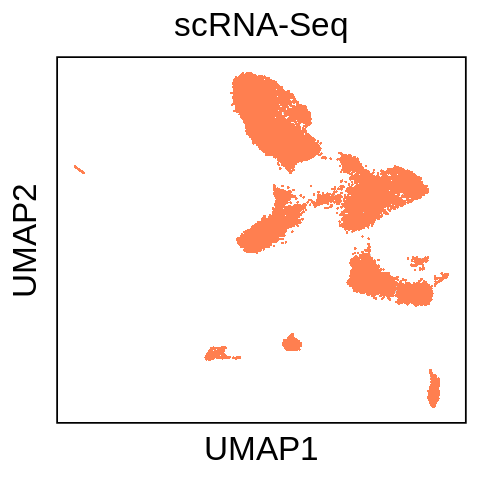

In [12]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "scRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "coral"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'scRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'myeloid_umap_sc.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_sc.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)


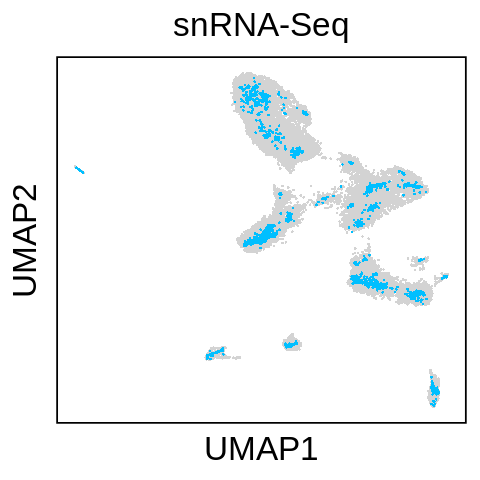

In [11]:
umap_plot = ggplot() +
  geom_point(
    data=select(qcd_meta, c(hUMAP1, hUMAP2, dataset)),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "lightgrey"
  ) + 
  geom_point(
    data=qcd_meta %>% filter(dataset == "snRNAseq") %>% select(hUMAP1, hUMAP2),
    aes(x = hUMAP1, y = hUMAP2),
    size = 0.75, stroke = 0.0001, color = "deepskyblue"
  ) +
theme_classic(base_size = tickfontsize) +
  theme(
    legend.position = "none",
         plot.title = element_text(size = labelfontsize, hjust = 0.5),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          text=element_text(family="Arial")
  ) + labs(x = "UMAP1", y = "UMAP2", title = 'snRNA-Seq') 


outplot = umap_plot

height = 4
width = 4
fig.size(height, width)
outplot

ggsave(paste0(figdir, 'myeloid_umap_sn.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_sn.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster UMAPs

In [4]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))

Joining, by = "new_cluster_number"


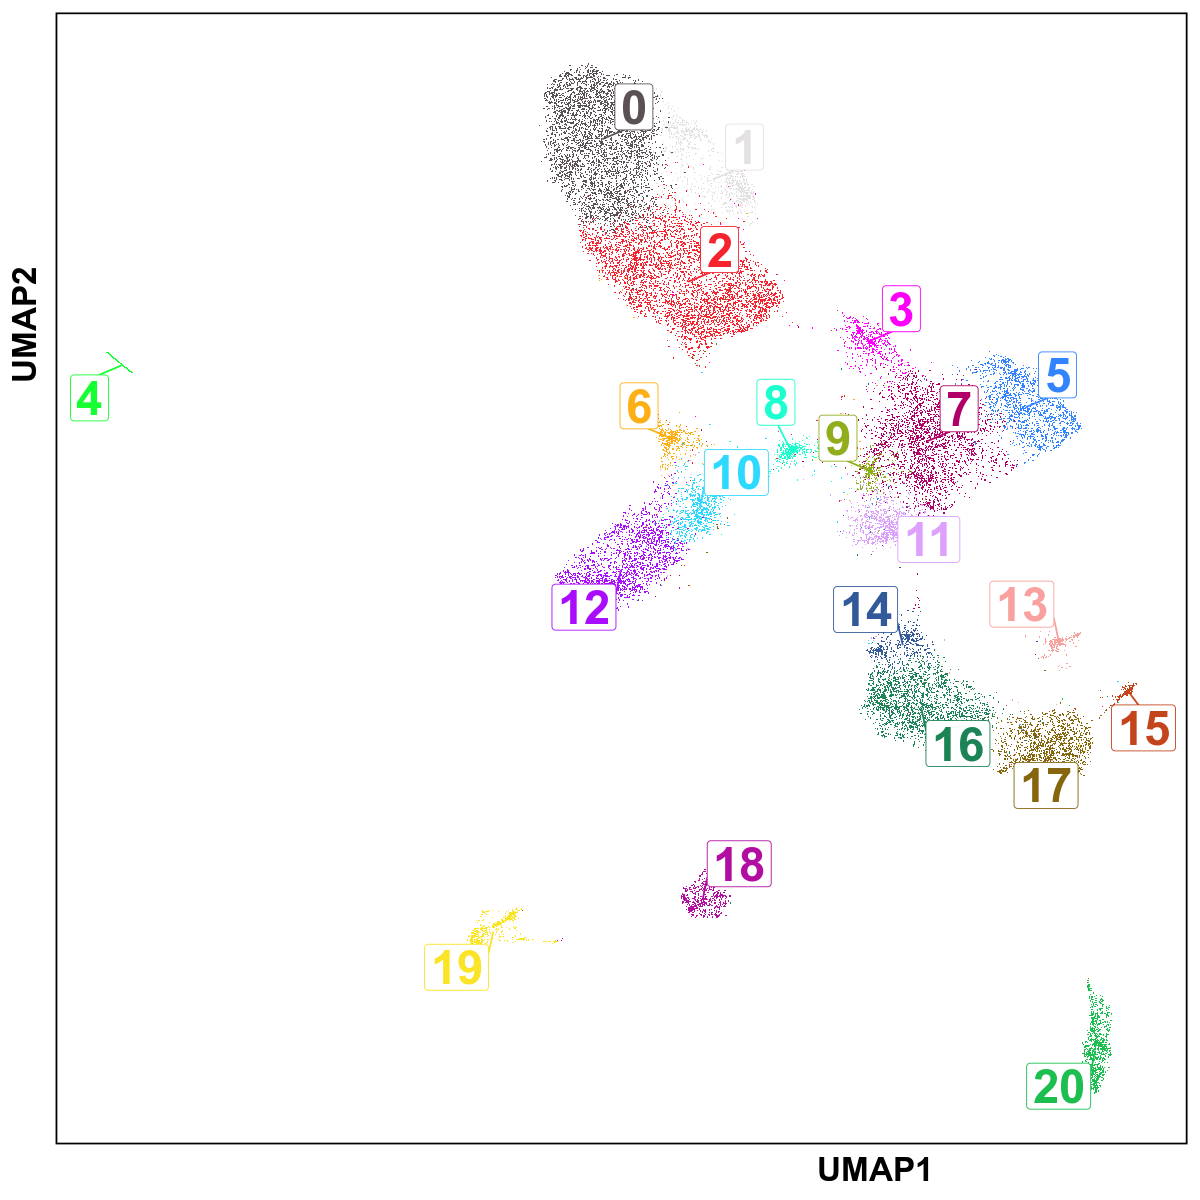

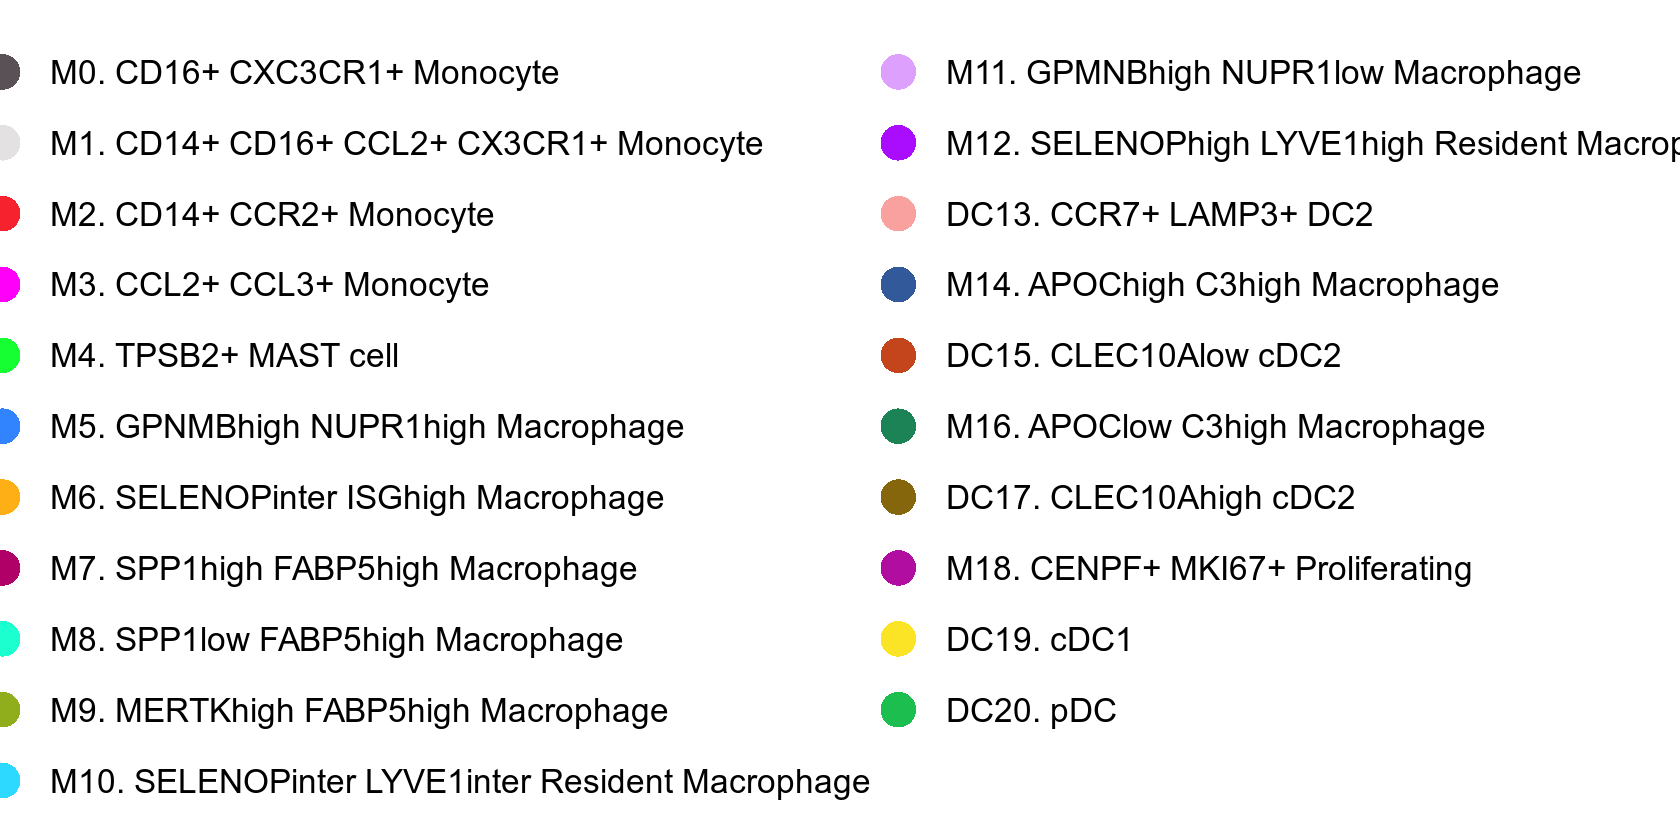

In [10]:
options(warn=-1)
cluster_center <- qcd_meta %>%
                  group_by(new_cluster_number, final_annotation) %>%
                  summarise_at(vars(hUMAP1, hUMAP2), funs(median(., na.rm=TRUE)))
cluster_center <- as.data.frame(cluster_center)

options(repr.plot.height = 9, repr.plot.width = 18)
p <- ggplot() +
      geom_point(
        data = qcd_meta[sample(nrow(qcd_meta)), ] %>% 
          select(hUMAP1, hUMAP2, new_cluster_number, final_annotation) %>% 
                  mutate(final_annotation = factor(final_annotation, 
                                                   levels = cluster_center$final_annotation)),
        aes(x = hUMAP1, y = hUMAP2, color = final_annotation),
          size = 0.6, shape = 20, stroke = 0.0001) +
      ggrepel::geom_label_repel(
        data = cluster_center,
        aes(x = hUMAP1, y = hUMAP2, 
            label = new_cluster_number, color = as.factor(final_annotation)),
        size = 10,  fontface = "bold",
        box.padding = unit(0.5, "lines"),
        point.padding = unit(0.01, "lines"),
        show.legend = FALSE
      ) +
        scale_color_manual(values =as.vector(polychrome(26))) +
    theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1),
              legend.text = element_text(size = 20),
              legend.title = element_blank()
          
    ) +
    theme(text=element_text(family="Arial")) + 
        labs(x = "UMAP1", y = "UMAP2") +
        guides(color = guide_legend(ncol = 2, override.aes = list(size = 15)))
legend <- cowplot::get_legend(p)
p <- p + theme(legend.position = "none")
legend <- cowplot::plot_grid(legend)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2c.png",
       p,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/figure2/figure2c-legend.png",
       legend,
       base_height = 7,
       base_width = 15)
fig.size(10, 10)
p
fig.size(7, 14)
legend
options(warn=0)

### Marker Gene UMAPs

In [13]:
markers = c('CD14', 'FCGR3A', 'MSR1', 'C1QA')

In [14]:
qcd_scaled = qcd_norm[markers, ] %>% scaleData
vmax = qcd_scaled %>% quantile(.95)
vmin = qcd_scaled %>% quantile(.05)

In [15]:
p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[1], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p1 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[2], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p2 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[3], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p3 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

p = plot_shuffled_features(qcd_meta, qcd_scaled, markers[4], pt_size = 1, max.cutoff = vmax,
                          min.cutoff = vmin)
p4 = p + theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
               theme(text=element_text(family="Arial")),
              legend.position = "none") + labs(x = 'UMAP1', y = 'UMAP2')

umap_legend = get_legend(p +theme(legend.text = element_text(size = labelfontsize-2),
                legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize),
                theme(text=element_text(family="Arial"))))
umap_legend = cowplot::plot_grid(umap_legend) 

Warning message in get_plot_component(plot, "guide-box"):
“Multiple components found; returning the first one. To return all, use `return_all = TRUE`.”


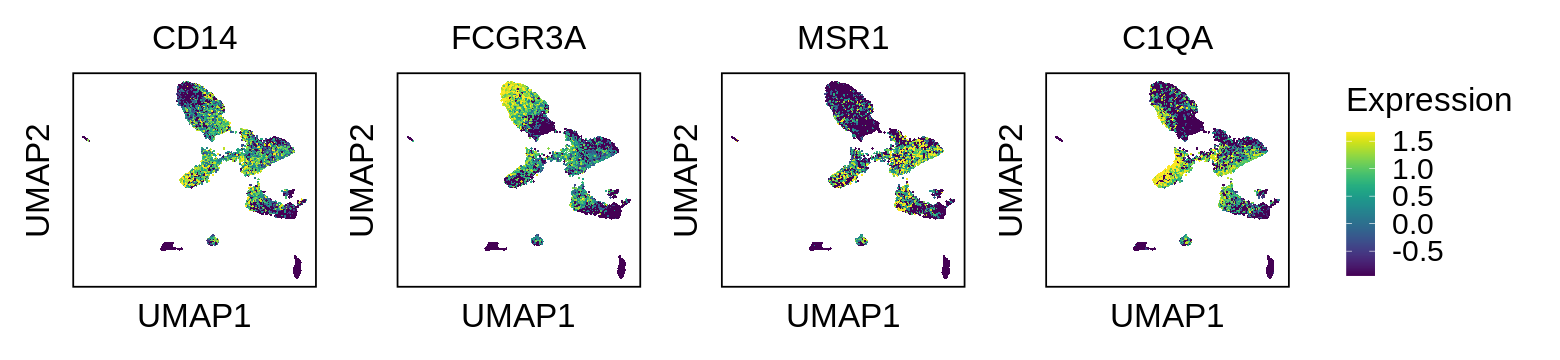

In [17]:
height = 3
width = 13
fig.size(height, width)

outplot = p1 + p2 + p3 + p4 + umap_legend + plot_layout(nrow = 1)
outplot

ggsave(paste0(figdir, 'myeloid_umap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_umap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Gene Heatmaps

In [8]:
qcd_meta <- left_join(qcd_meta, data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC')))

Joining with `by = join_by(new_cluster_number, final_annotation)`


In [9]:
final_annotation <- data.frame(new_cluster_number = seq(0, 20), 
                                           final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC'))

In [10]:
marker.genes <- c("CD14", "FCGR3A", "CCR2", 'CCL2', "TPSB2",  "APOC1", "NUPR1",
                  "SPP1", "GPNMB", 
                  "TIMP1", "FABP5", "C1QA", "SELENOP", "LYVE1", "CCR7", "LAMP3", 
                  "C3", 'HLA-DRB1', "CD1C", "FCER1A", 
                  "CENPF", "MKI67", "CADM1", "CLEC9A", 
                  "JCHAIN", "TCF4")

In [11]:
annotation.order = c('M0. CD16+ CXC3CR1+ Monocyte', 
                       'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                       'M2. CD14+ CCR2+ Monocyte',
                       'M3. CCL2+ CCL3+ Monocyte',
                       'M4. TPSB2+ MAST cell',
                       'M5. GPNMBhigh NUPR1high Macrophage',
                       'M6. SELENOPinter ISGhigh Macrophage', 
                       'M7. SPP1high FABP5high Macrophage',
                       'M8. SPP1low FABP5high Macrophage',
                       'M9. MERTKhigh FABP5high Macrophage',
                       'M10. SELENOPinter LYVE1inter Resident Macrophage',
                       'M11. GPMNBhigh NUPR1low Macrophage',
                       'M12. SELENOPhigh LYVE1high Resident Macrophage',
                       'DC13. CCR7+ LAMP3+ DC2', 
                       'M14. APOChigh C3high Macrophage',
                       'DC15. CLEC10Alow cDC2',
                       'M16. APOClow C3high Macrophage',
                       'DC17. CLEC10Ahigh cDC2',
                       'M18. CENPF+ MKI67+ Proliferating',
                       'DC19. cDC1',
                       'DC20. pDC')

In [12]:
library(googlesheets4)
gs4_deauth()

tissue_names = read_sheet("https://docs.google.com/spreadsheets/d/1f94hwyuDMvSUQyelWM89xfhDos7izNQw9bQ4amml2OQ/edit?usp=sharing", 
                 sheet = "Tissue")
tissue_names = setNames(tissue_names$Annotation_latest, tissue_names$Annotation_v1)
qcd_meta = qcd_meta %>% mutate(final_annotation = recode(final_annotation, !!!tissue_names))

annotation.order = recode(annotation.order, !!!tissue_names)

✔ Reading from UpdatedClusterNames.

✔ Range ''Tissue''.



In [13]:
marker_genes = marker.genes

In [14]:
wilcox_sn <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'snRNAseq') %>% pull(final_annotation))
wilcox_sc <- wilcoxauc(qcd_norm[, qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(cell)], 
                       qcd_meta %>% filter(dataset == 'scRNAseq') %>% pull(final_annotation))

In [15]:
sc_plot_df <- wilcox_sc %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 
sn_plot_df <- wilcox_sn %>%  filter(feature %in% marker_genes) %>% 
                    select(group, feature, 
                           logFC, avgExpr, pct_in) %>% ungroup() %>% group_by(feature) %>% 
                    mutate(avgExpr_scaled = scale(avgExpr)) 

In [16]:
setdiff(sc_plot_df$group, annotation.order)

character(0)

In [17]:
title = 'scRNA-seq'
dat_all = sc_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
                    values_from = 'zscore') %>% as.data.frame
rownames(dat) = dat$feature
dat = dat %>% select(-feature)
row.order = marker_genes
col.order = annotation.order
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)

# dat = dat[!is.na(dat$group), ]

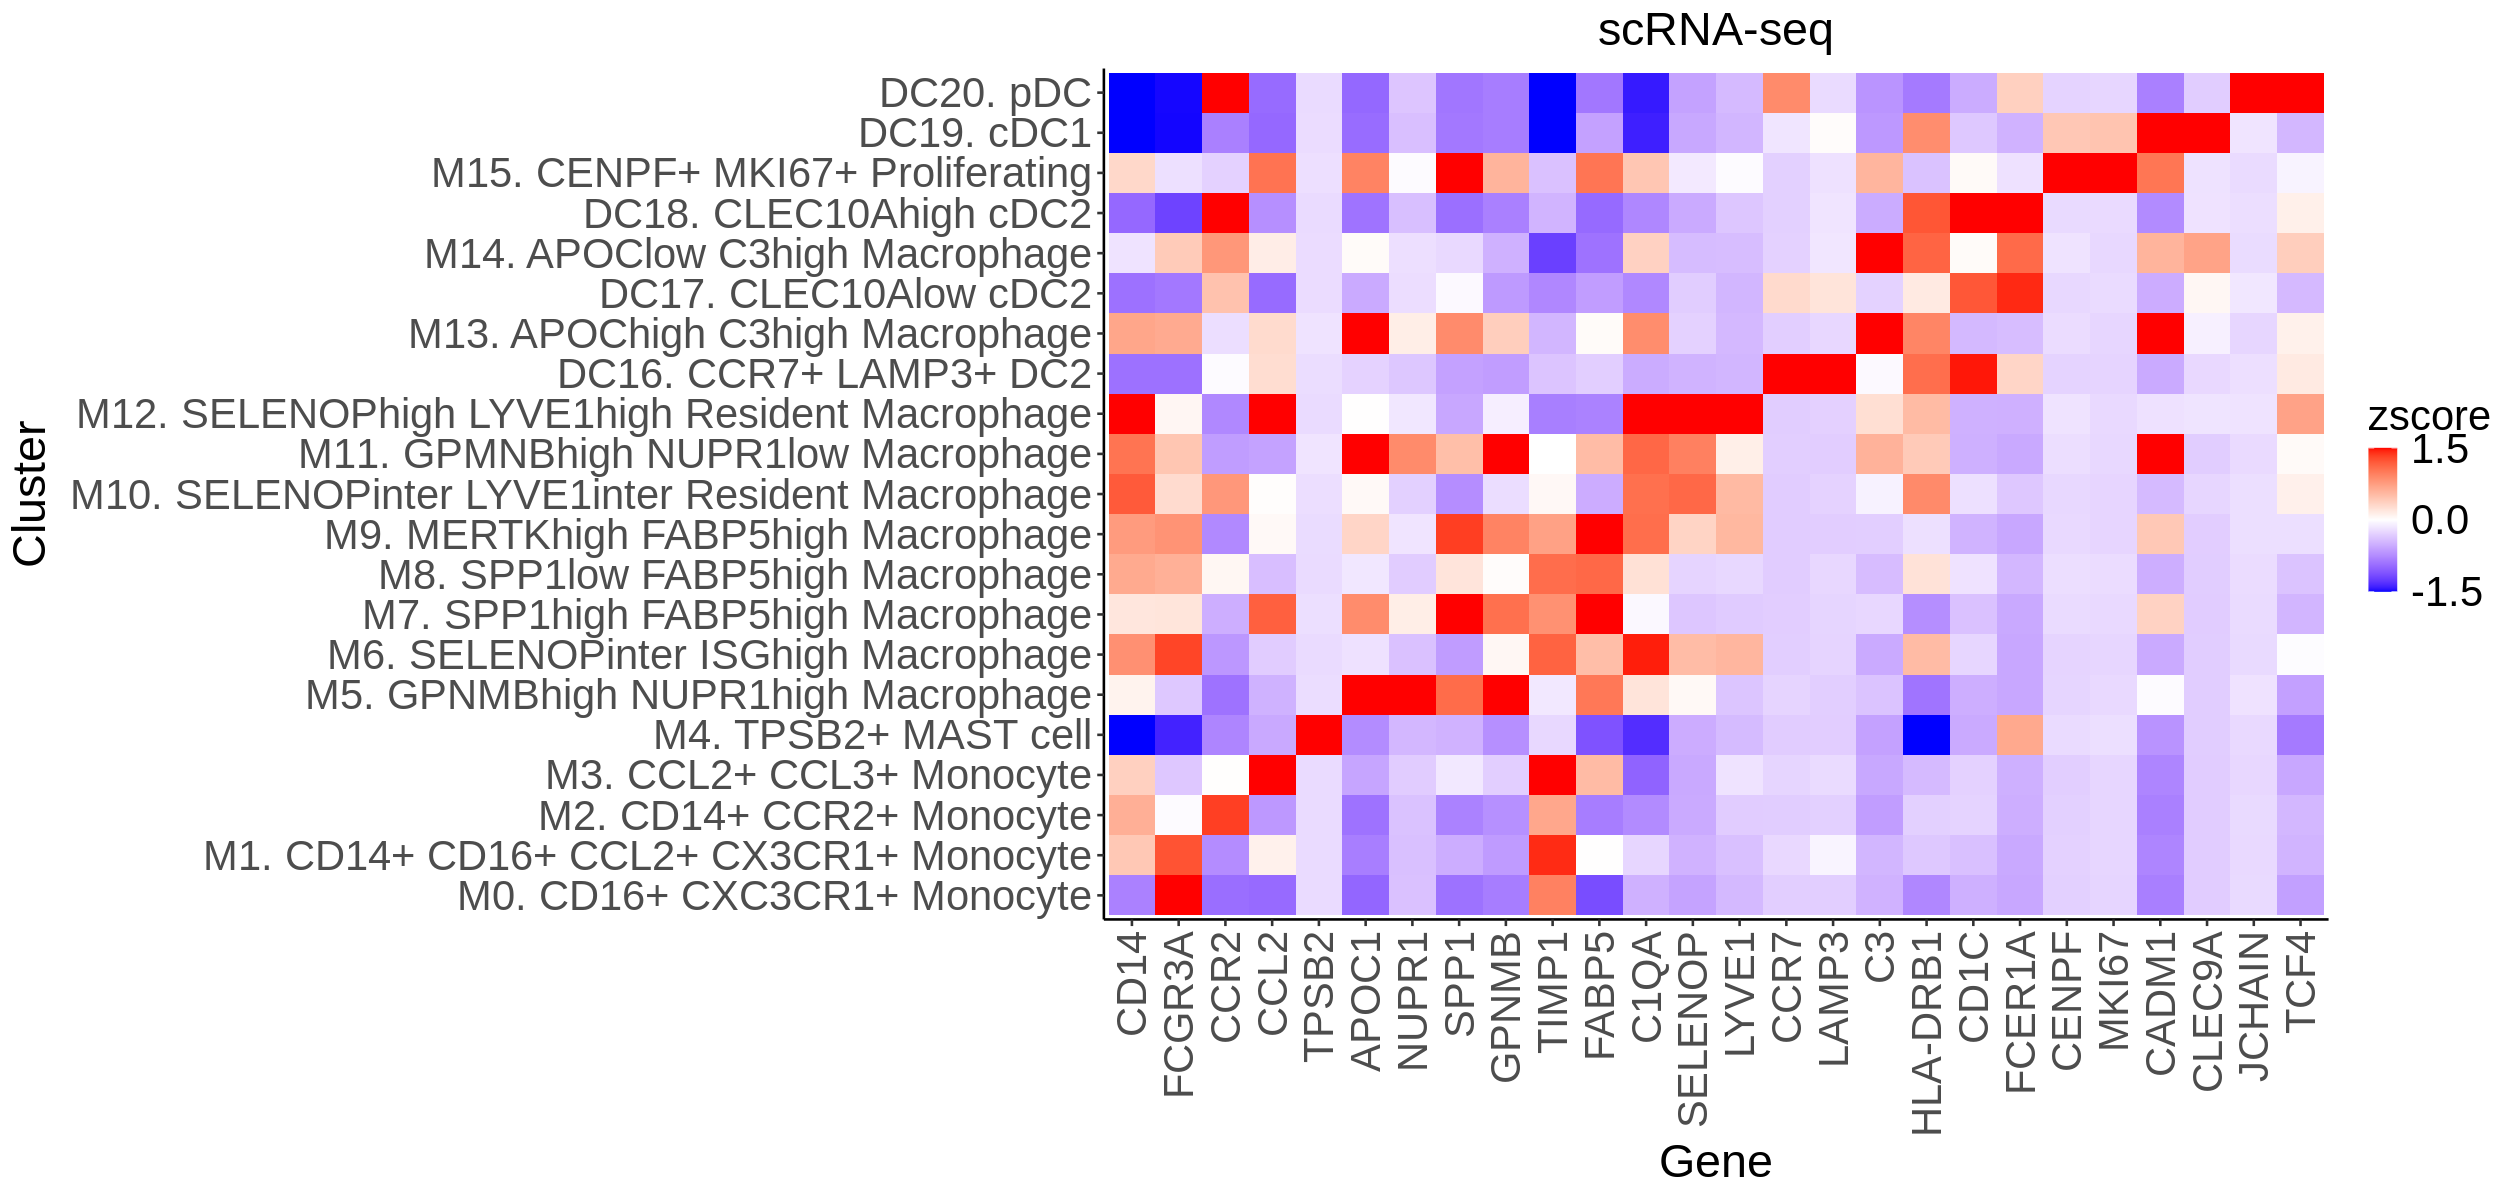

In [19]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'myeloid_sc_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_sc_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [31]:
title = 'snRNA-seq'
dat_all = sn_plot_df %>% rename(percent = pct_in, zscore = avgExpr_scaled) 

# dat = dat_all %>% pivot_wider(id_cols = 'feature', names_from = 'group', 
#                     values_from = 'zscore') %>% as.data.frame
# rownames(dat) = dat$feature
# dat = dat %>% select(-feature)
# row.order = rownames(dat)[hclust(dist(dat))$order]
# col.order = colnames(dat)[hclust(dist(t(dat)))$order]
dat = dat_all
dat$group = factor(dat$group, levels = col.order)
dat$feature = factor(dat$feature, levels = row.order)
# dat = dat[!is.na(dat$group), ]

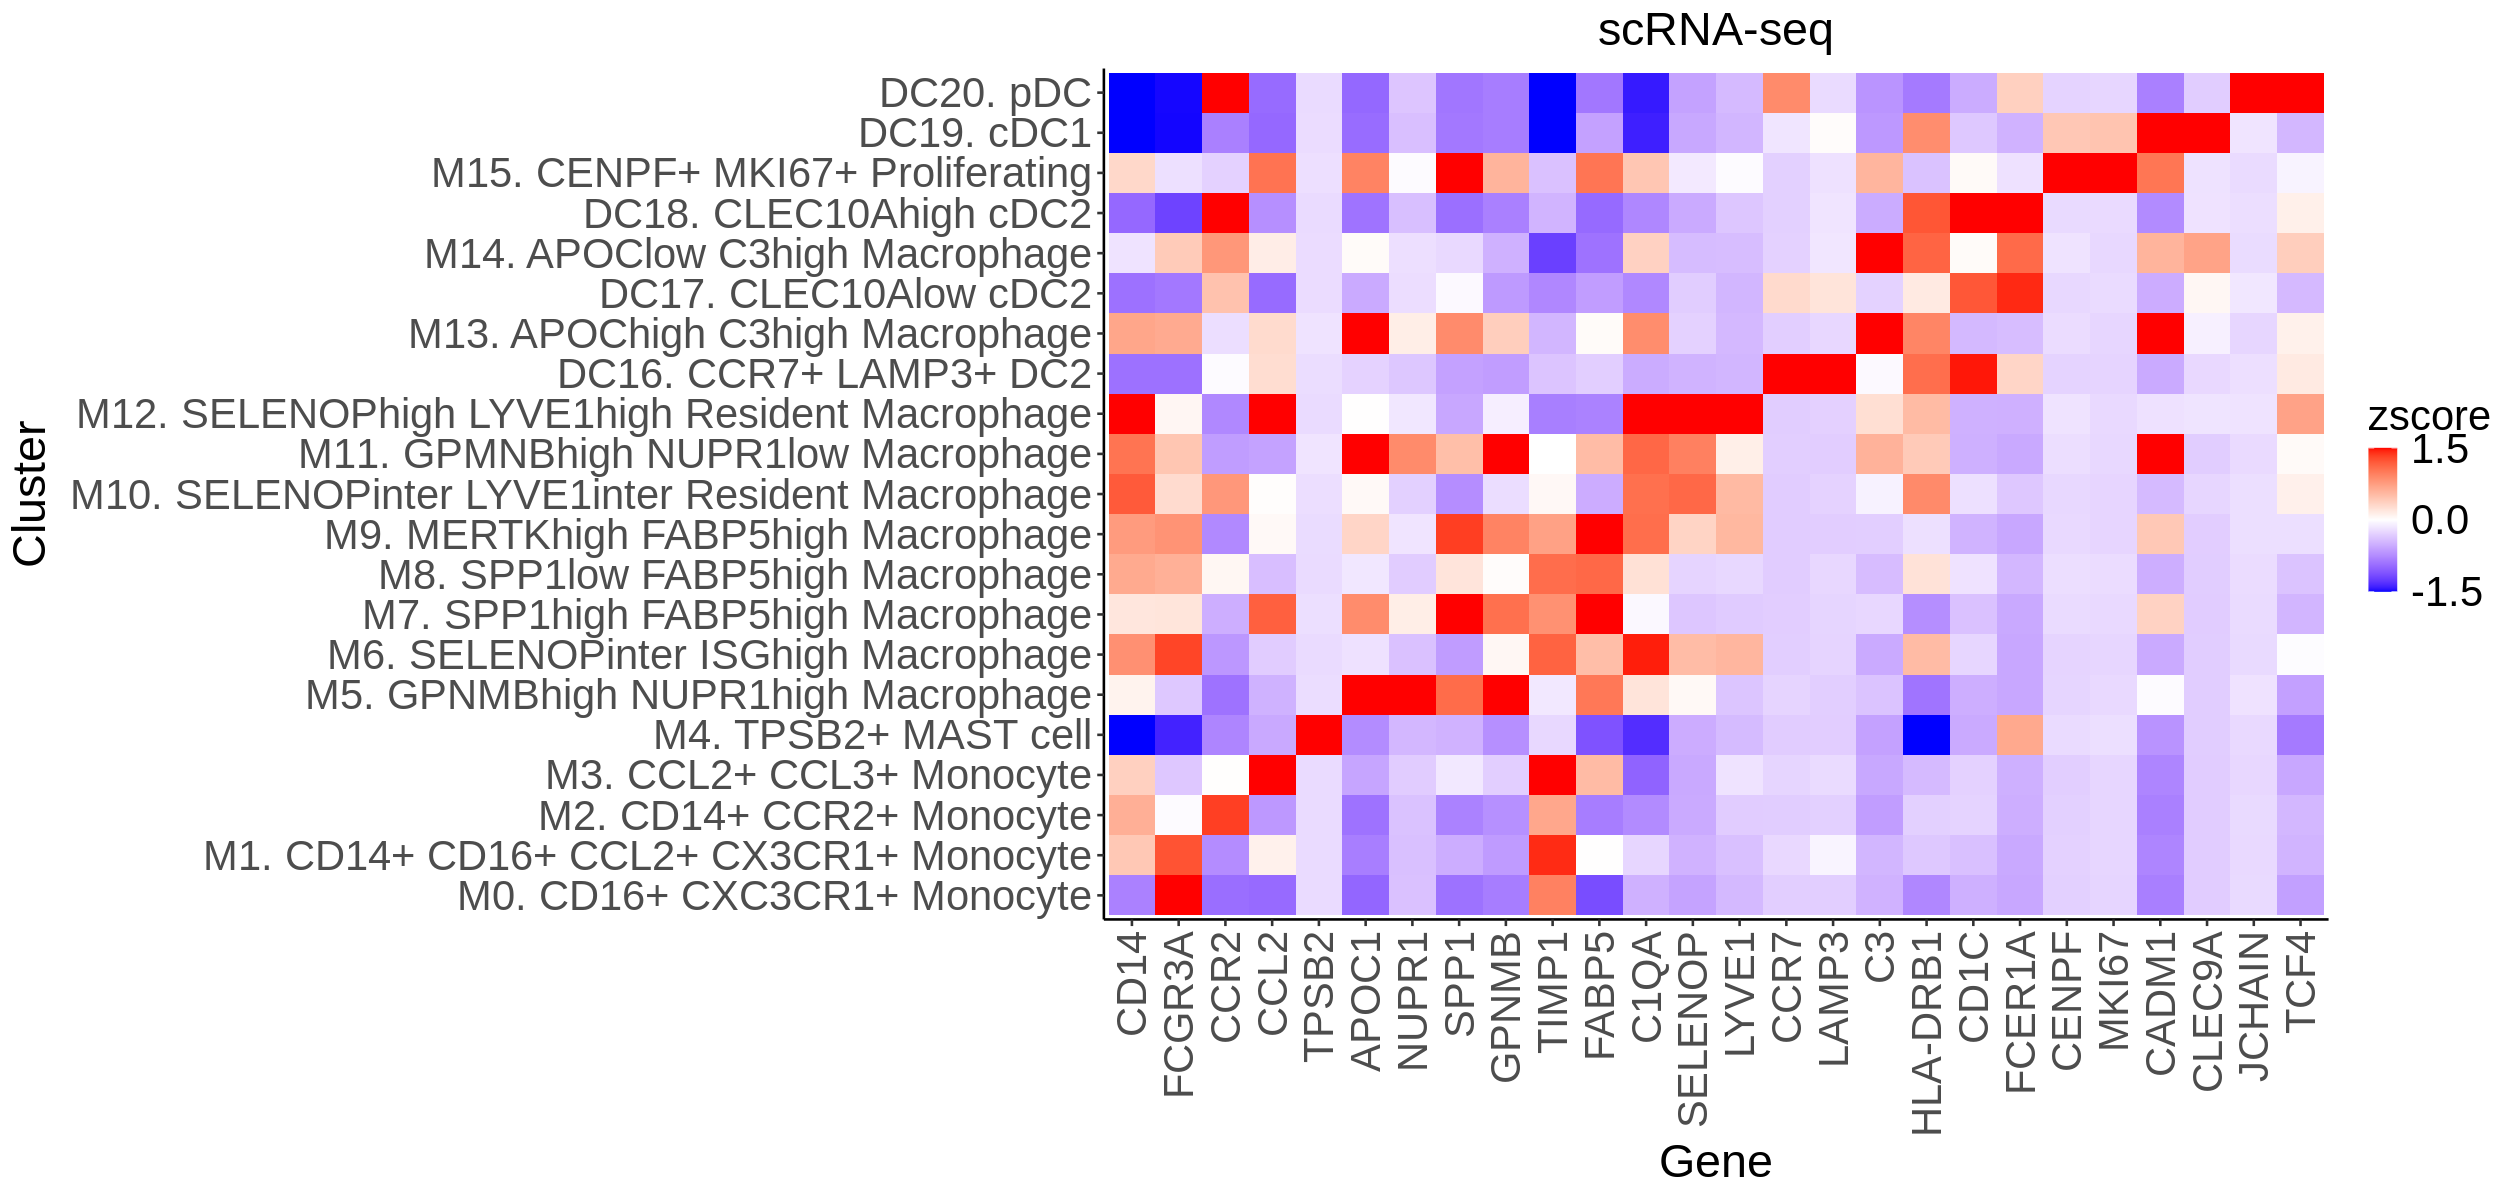

In [20]:
height = 10
width = 21
fig.size(height, width)


marker_heatmap = ggplot(dat, 
               aes(x = feature, y = group, 
                   fill = zscore)) + 
    geom_tile() + 
    theme_classic(base_size = tickfontsize) + 
    scale_fill_gradient2(low = "blue",
                         mid = "white",
                         high= "red", 
                         limits=c(-1.5, 1.5), 
                         oob = scales::squish, breaks = c(-1.5, 0, 1.5)) + 
    # scale_x_discrete(limits = marker_genes) + 
    # scale_y_discrete(limits = final_annotation$final_annotation) + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          axis.text = element_text( size = labelfontsize+5),
          axis.title = element_text(size = labelfontsize+8), 
          plot.title = element_text(size = labelfontsize+8, hjust = 0.5), 
          legend.text = element_text(size = labelfontsize+5),
          legend.title = element_text(size = labelfontsize+5)

         ) + 
    labs(x = "Gene", y = "Cluster", title = title)

outplot = marker_heatmap
outplot

ggsave(paste0(figdir, 'myeloid_sn_heatmap_markers.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_sn_heatmap_markers.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

### Cluster Proportions in Matched Patients

In [34]:
qcd_meta <- qcd_meta  %>% 
                mutate(individual = str_split(sample, '_')) %>% 
                rowwise() %>% 
                mutate(individual = unlist(individual)[3]) 

In [35]:
sample_freq <- qcd_meta %>% select(dataset, individual, new_cluster_number) %>% 
                    table() %>% data.frame() %>% 
                    pivot_wider(names_from = "new_cluster_number", values_from = Freq) 

In [36]:
ind_list <- qcd_meta %>% select(dataset, individual) %>% 
                table() %>% data.frame() %>% 
                pivot_wider(names_from = 'dataset', values_from = "Freq") %>% filter(scRNAseq > 30 & snRNAseq > 30) %>% 
                pull(individual)

In [37]:
sample_freq_sc <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "scRNAseq") %>% 
                    select(-dataset) %>% colSums()

sample_freq_sn <- sample_freq %>% 
                    filter(individual %in% ind_list) %>% 
                    select(- individual) %>% 
                    filter(dataset == "snRNAseq") %>% 
                    select(-dataset) %>% colSums()

In [38]:
sample_freq <- data.frame(rep("a", 21))
sample_freq$sc_freq <- sample_freq_sc / sum(sample_freq_sc)
sample_freq$sc_se <- sqrt((sample_freq$sc_freq * (1 - sample_freq$sc_freq)) / sample_freq_sc)
sample_freq$sn_freq <- sample_freq_sn / sum(sample_freq_sn)
sample_freq$sn_se <- sqrt((sample_freq$sn_freq * (1 - sample_freq$sn_freq)) / sample_freq_sn)
sample_freq <- sample_freq[,- 1]
sample_freq$new_cluster_number <- as.character(seq(0, 20))

In [39]:
r = cor(sample_freq$sc_freq, sample_freq$sn_freq)
pval = cor.test(sample_freq$sc_freq, sample_freq$sn_freq)$p.value

In [40]:
format(pval, format = 'e', digits = 3)

[1] "0.00173"

In [42]:
title = 'Myeloid'

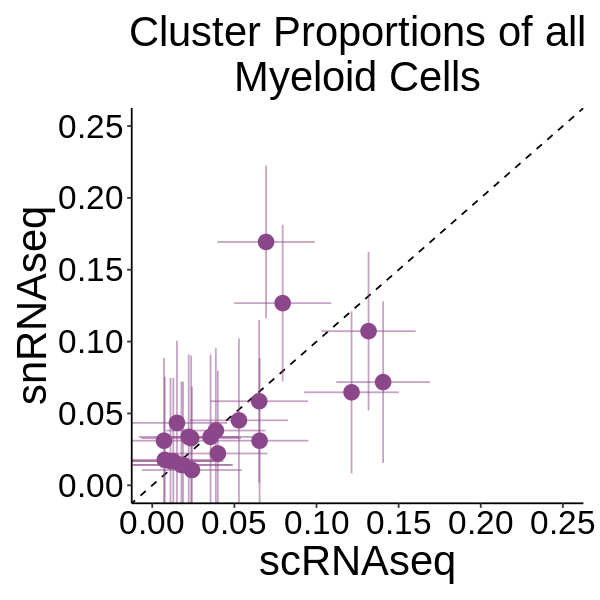

In [45]:
max_val <- max(sample_freq[, c("sc_freq", "sn_freq")])

p = ggplot(sample_freq, aes(x = sc_freq, y = sn_freq)) + 
    geom_abline(linetype = "dashed") +
    # scale_color_manual(values =as.vector(rev(palette36.colors(26)))) +
    theme_classic() + 
    geom_linerange(aes(ymax = sn_freq+1.96*sn_se, 
                        ymin = sn_freq-1.96*sn_se), alpha = 0.5, color = 'orchid4') +
    geom_linerange(aes(xmax = sc_freq+1.96*sc_se, 
                        xmin = sc_freq-1.96*sc_se), alpha = 0.5, color = 'orchid4') +
    geom_point(size = 4, color = 'orchid4') + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18)) +
    coord_cartesian(xlim = c(0, 0.25), ylim = c(0, 0.25)) + 
    labs(x = "scRNAseq",
         y = "snRNAseq", title = paste0('Cluster Proportions of all\n', title, ' Cells'))+
    annotate("text", x = 0, y = 0.4, label = paste0('R=', round(r, 2)), hjust =0, 
         size =7)+
    annotate("text", x = 0, y = 0.36, label = paste0('P=', 
             format(pval, format = 'e', digits = 3)), hjust =0, 
         size =7)

p = p +theme(axis.text = element_text(color = "black", size = labelfontsize, vjust = 0.5),
           axis.title = element_text(size=labelfontsize+5, hjust = 0.5),
            legend.text = element_text(size = labelfontsize),
            legend.title = element_text(size = labelfontsize),
                plot.title = element_text(hjust = 0.5, size = labelfontsize+5),
                theme(text=element_text(family="Arial")),
                                    plot.margin = margin(10, 10, 10, 10))
height = 5
width = 5
fig.size(height, width)

outplot = p
outplot

ggsave(paste0(figdir, 'myeloid_scsn_cellfreqcorr.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_scsn_cellfreqcorr.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [44]:
cor.test(sample_freq$sc_freq, sample_freq$sn_freq)


	Pearson's product-moment correlation

data:  sample_freq$sc_freq and sample_freq$sn_freq
t = 3.6424, df = 19, p-value = 0.001733
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.2897336 0.8403053
sample estimates:
      cor 
0.6412203 


### sc/sn qq ratio

In [316]:
#find individual from sample
qcd_meta <- qcd_meta %>% 
                        mutate(individual = str_split(sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3])
#filter for individuals with > X cells 
ind_meta <- qcd_meta %>% 
                    select(individual, dataset) %>% 
                    table() %>% data.frame() 

ind_keep <- vector() 

for (i in unique(ind_meta$individual)) {
    ind_subset <- ind_meta %>% filter(individual == i)
        if (all(ind_subset$Freq > 10)) {
            ind_keep <- c(ind_keep, i)
        }
}

#pseudobulking
qq_pb_sc <- data.frame(nrow = nrow(all_immune_norm))
individuals_sc <- vector()

for (i in ind_keep) {
            subset <- qcd_meta %>% filter(individual == i, 
                                                 dataset == "scRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(qcd_norm[, subset])
            qq_pb_sc <- cbind(qq_pb_sc, pb_vec)
            individuals_sc <- c(individuals_sc, i)
}

qq_pb_sn <- data.frame(nrow = nrow(all_immune_norm))
individuals_sn <- vector()

for (i in ind_keep) {
    subset <- qcd_meta %>% filter(individual == i, 
                                                 dataset == "snRNAseq") %>% 
                        pull(cell)
            pb_vec <- rowMeans(qcd_norm[, subset])
            qq_pb_sn <- cbind(qq_pb_sn, pb_vec)
            individuals_sn <- c(individuals_sn, i)
}

#remove extraneous first column
qq_pb_sc <- qq_pb_sc[, -1]
qq_pb_sn <- qq_pb_sn[, -1]

#assign column names
colnames(qq_pb_sc) <- paste0(individuals_sc, "_sc")
colnames(qq_pb_sn) <- paste0(individuals_sn, "_sn")
qq_pb <- cbind(qq_pb_sc, qq_pb_sn)

#qqnormalization 
index_to_mean <- function(my_index, my_mean){
  return(my_mean[my_index])
}
df_rank <- apply(qq_pb,2,rank,ties.method="first")
df_sort <- data.frame(apply(df, 2, sort))
df_mean <- apply(df_sort, 1, mean)
df_final <- apply(df_rank, 2, index_to_mean, my_mean=df_mean)

#transpose to df
df_final <- t(df_final) %>% data.frame()

#assign covariates from rownames
df_final <- df_final %>% mutate(ind = sapply(rownames(df_final), 
                                             FUN = function(x) unlist(str_split(x, "_"))[1]),
                                technology = sapply(rownames(df_final), 
                                                    FUN = function(x) unlist(str_split(x, "_"))[2]))

#run pb linear model
out_myeloid <- data.frame()
for (i in 1:nrow(qcd_norm)) {
    gene = rownames(qcd_norm)[i]
    model_df <- cbind(df_final[, i], df_final %>% select(ind, technology))
    colnames(model_df) <- c('Exp', 'ind', 'technology')
    H0 <- lm(Exp ~ ind, data = model_df)
    H1 <- lm(Exp ~ ind + technology, data = model_df)

    ANNO <- anova(H0, H1)
    LRP <- ANNO[2,6]
    F <- ANNO[2,5]
    Beta <- summary(H1)$coefficients['technologysn', 'Estimate']
    SE <- summary(H1)$coefficients['technologysn', 'Std. Error']
    res <- c(gene = gene, LRP = LRP, F = F, Beta = Beta, SE = SE)
    out_myeloid <- rbind(out_myeloid, res)
}

#format output 
colnames(out_myeloid) <- c('gene', 'LRP', 'F', 'Beta', 'SE')
out_myeloid[out_myeloid == "NaN"] <- NA

In [322]:
out_filter <- out_myeloid %>% na.omit() %>% 
                mutate(LRP = as.numeric(LRP),
                       F = as.numeric(F),
                       Beta = as.numeric(Beta),
                       SE = as.numeric(SE)) %>% 
                mutate(FDR = p.adjust(LRP, method = "BH")) %>% 
                filter(FDR < 0.05)

In [323]:
library(msigdbr)
library(fgsea)

##format for gsea 
FC.vec <- out_filter$Beta
names(FC.vec) <- out_filter$gene

scoreType <- "std"

H <- msigdbr(species = "Homo sapiens", category = "H")

H.ensembl.ls <- H %>% 
  select(gs_name, gene_symbol) %>% 
  group_by(gs_name) %>% 
  summarise(all.genes = list(unique(gene_symbol))) %>% 
  tibble::deframe()

#Run GSEA
gsea.H <- fgseaSimple(pathways = H.ensembl.ls,
                      stats = FC.vec,
                      scoreType = scoreType,
                      nperm=10000)

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (0.37% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


Warning message:
“Removed 15487 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 602 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


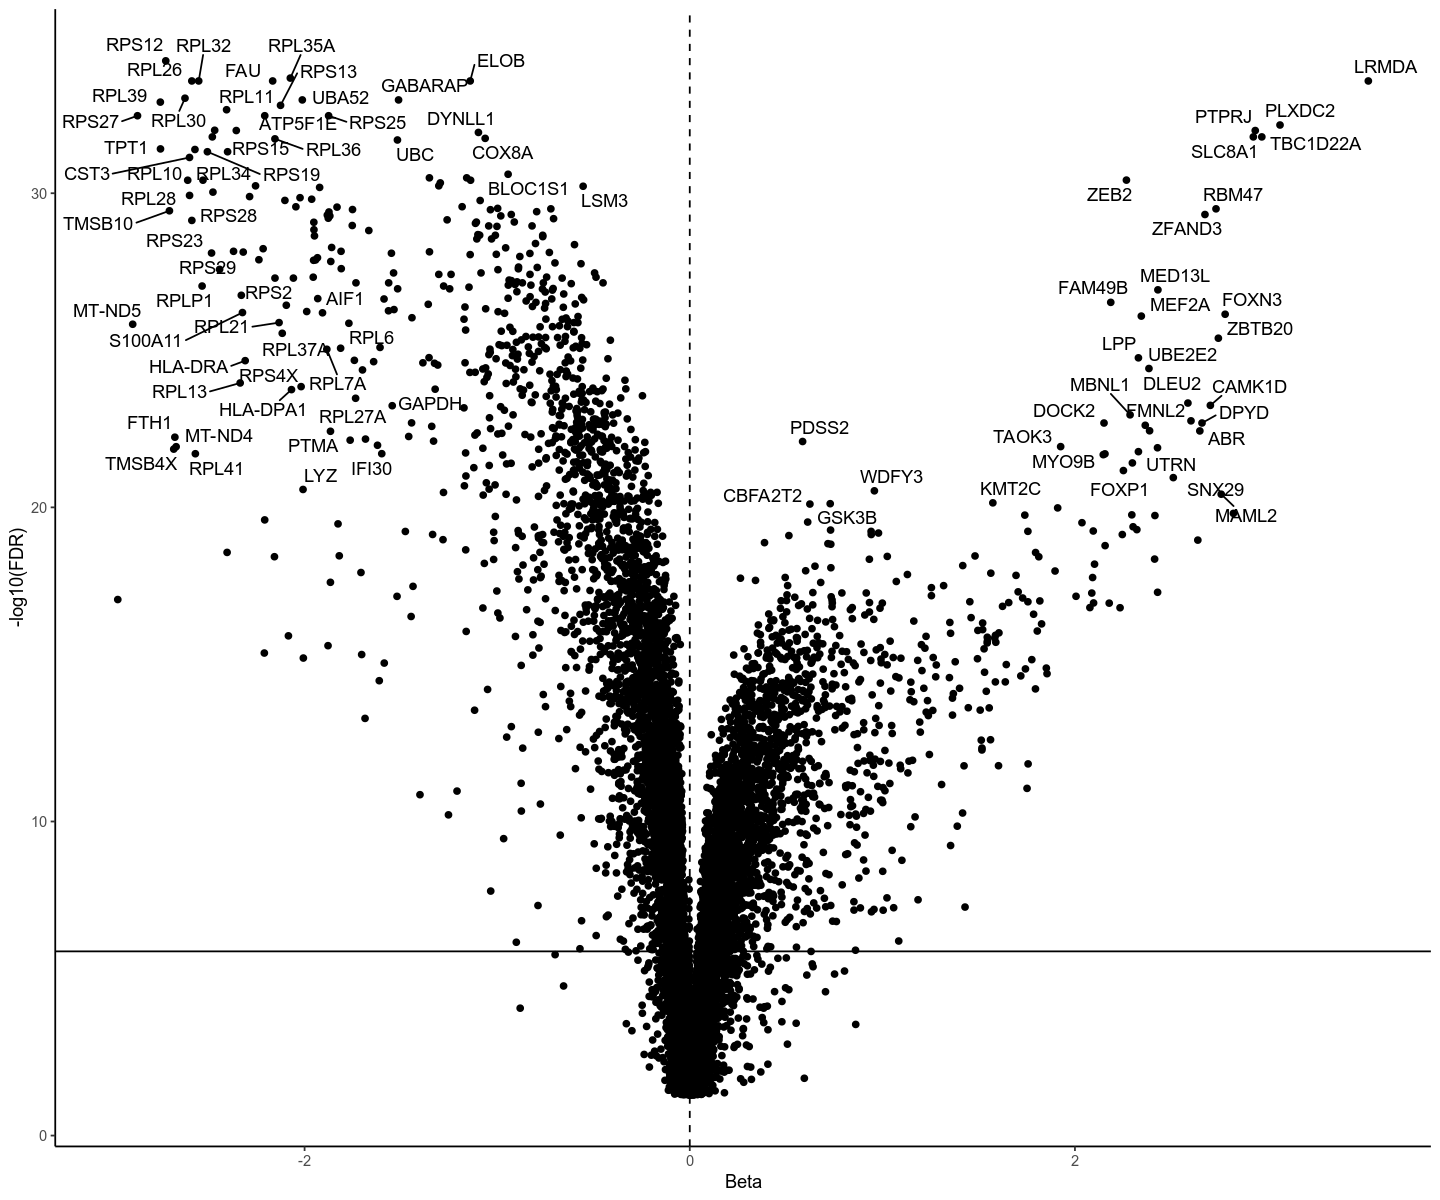

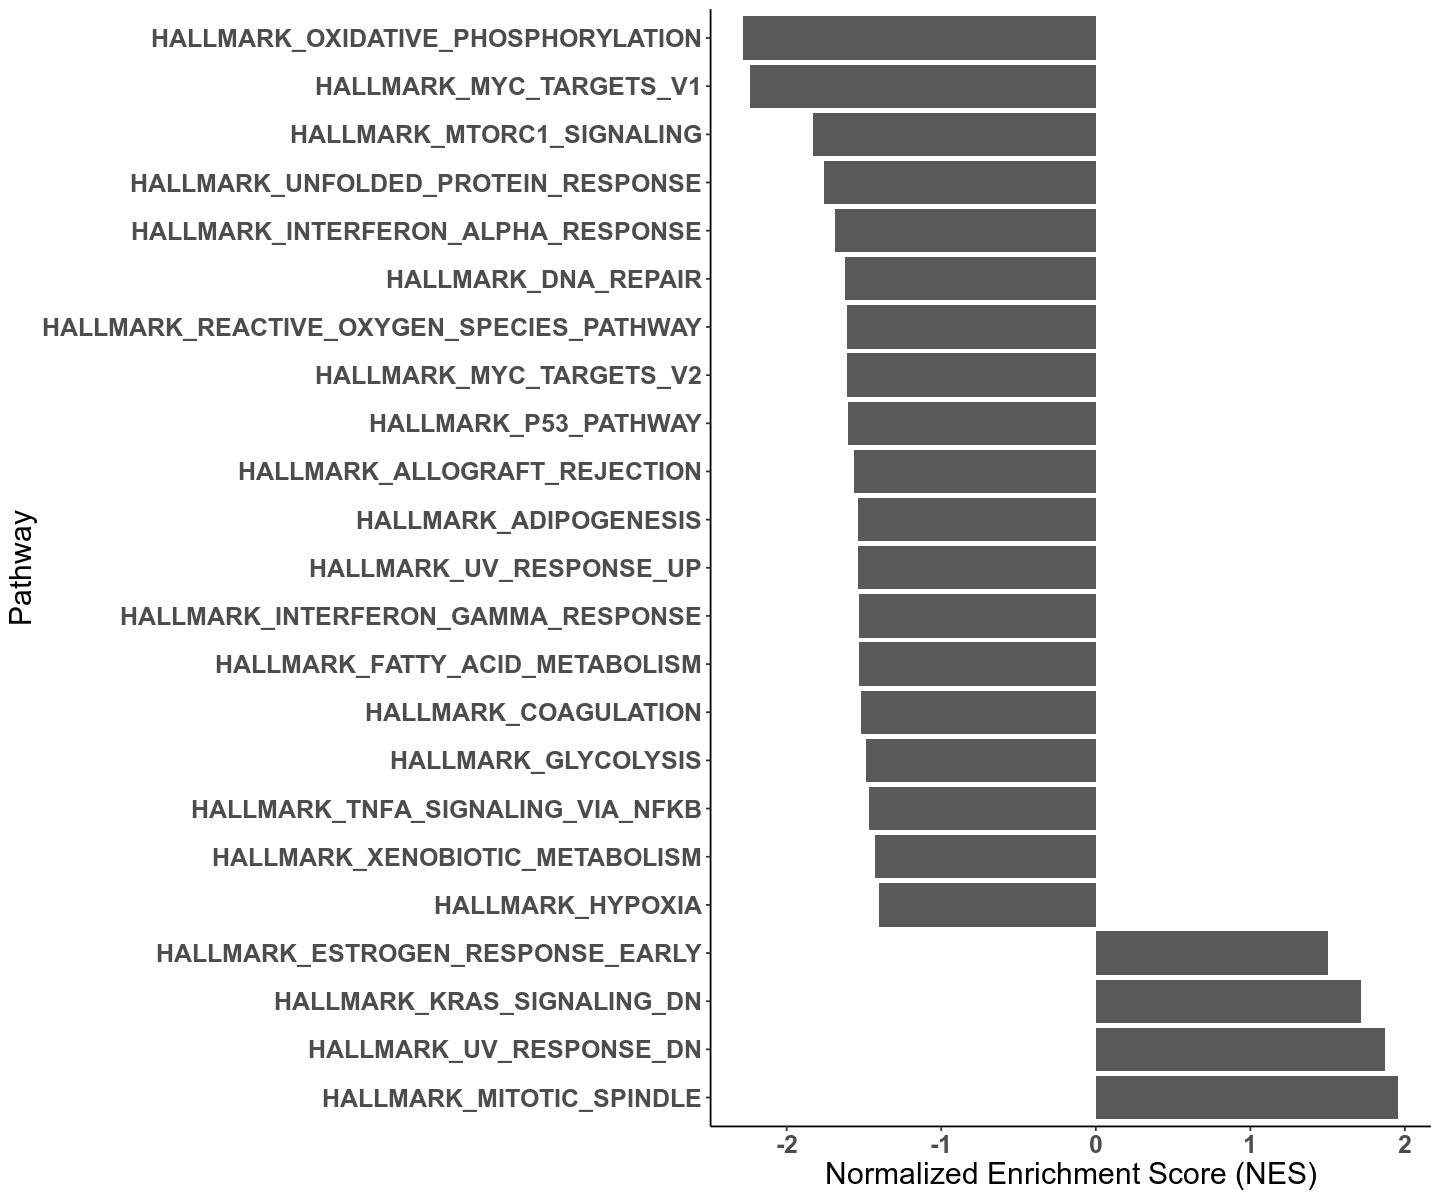

In [325]:
fig.size(10,12)

ggplot(out_filter %>% 
           mutate(label = ifelse(-log10(FDR) > 20, gene, NA)), aes(x = Beta, y = -log10(FDR))) + 
    geom_point() + 
    geom_vline(aes(xintercept = 0), linetype = "dashed") + 
    geom_hline(aes(yintercept = -log10(0.05/36601))) + 
    theme_classic() + 
    ggrepel::geom_text_repel(aes(label = label))


ggplot(gsea.H %>% filter(padj < 0.05), aes(x = NES, y = pathway)) +
    geom_bar(stat = "identity") +
    theme_classic() + 
    scale_y_discrete(limits = gsea.H %>% filter(padj < 0.05) %>% arrange(desc(NES)) %>% pull(pathway)) + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15, face = "bold"),
          axis.title = element_text(size = 18)) +
    labs(x = 'Normalized Enrichment Score (NES)', y = 'Pathway')

### GENE LIST FOR DE

## Case/Control Figure

### CASE/CONTROL CNA

In [5]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')
myeloid_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_rawcounts_03102023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(myeloid_rawcounts[mito_genes_subset, ]) / colSums(myeloid_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)
qcd_meta <- left_join(qcd_meta, percent_mito)

final_annotation = data.frame(new_cluster_number = seq(0, 20), 
                                    final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC'))

qcd_meta <- qcd_meta %>% left_join(final_annotation)
sc_meta <- qcd_meta %>% filter(dataset == "scRNAseq")

Joining, by = "cell"
Joining, by = "new_cluster_number"


In [6]:
sc_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'scRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical %>% select(Final_Site, Age, Sex, Type, individual))

meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Type)]

meta <- meta[ind, ]
umap <- umap[ind, ]
harmony <- harmony[ind, ]

meta <- meta %>% mutate(Type_numeric = ifelse(Type == "LN", 1, 0))


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "individual"


#### RESULTS

In [3]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_meta.csv')
harmony <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_harmony.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_umap.csv')

fdrs <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_fdrs.csv', header = FALSE)
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/case_control/sc_ncorr.csv', header = FALSE)

colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ncorr_thresh = ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)


In [6]:
title = 'Myeloid'
# subset <- c(0, 1, 5, 7, 10, 11, 12, 14, 16, 19)

nclus = 5
subset = c((aggregate(meta['ncorr'], meta['new_cluster_number'], FUN=mean) %>% arrange(ncorr) %>% tail(nclus))[[1]],
           (aggregate(meta['ncorr'], meta['new_cluster_number'], FUN=mean) %>% arrange(ncorr) %>% head(nclus))[[1]])
subset = subset %>% unique
subset

[1]  7  6  5 10 11 16 14  0  2 17

In [7]:
globalp = 9.999000099990002e-05 # From ssg34/SLE_kidney_v2/scripts/cna/*
pheno = 'LN'

In [13]:
library(scales)



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard




In [44]:
pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr
vmax = quantile(abs(tmp_meta$ncorr), .95)[[1]]
vmin = -vmax
custom_palette <- c("blue", "lightgray", "lightgray","lightgray",  "red") 
break_points <- c(vmin, neg_fdr_thresh, 0, pos_fdr_thresh, vmax)  

sig_cmap <- scale_color_gradientn(
  colours = custom_palette,
  values = rescale(break_points, to = c(0, 1)),  # Normalize thresholds
  limits = c(vmin, vmax),  # Ensure full scale
  na.value = "lightgrey",
  guide = guide_colorbar(direction = "horizontal"),  # Horizontal legend
    breaks = c(-floor(abs(vmin)*100)/100, floor(vmax*100)/100),
oob = scales::squish
)

In [45]:
vmax

[1] 0.3109324

In [28]:
sig_cmap

<ScaleContinuous>
 Range:  
 Limits: -0.41 -- 0.41

In [20]:
vmin

[1] -0.4099167

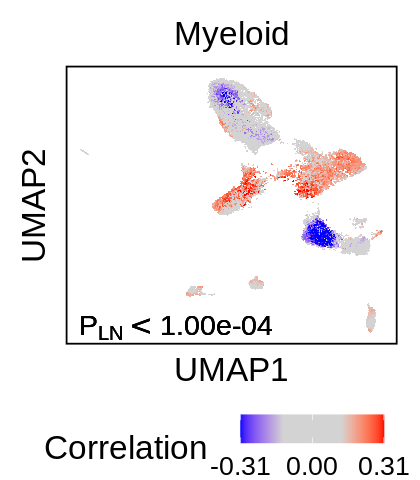

In [50]:
fig.size(3, 3)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 1e-10, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr_thresh), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 1e-10, shape = 20) + 
    sig_cmap+
      # scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey",
      #                       guide = guide_colorbar(direction = "horizontal"),
      #                      breaks = seq(-1, 1, by = 0.4)
      #                      ) + 
    theme_classic(base_size = tickfontsize) +
        theme(
        legend.position = "right",
        legend.justification = c(1, 1),
        legend.text = element_text(size = labelfontsize-4),
        legend.title = element_text(size = labelfontsize),
          plot.title = element_text(hjust = 0.5, size = labelfontsize),
          axis.title = element_text(size = labelfontsize), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
    annotate("text", x = -6.5, y = -14, 
         label = bquote(P[.(pheno)] < .(formatC(globalp, format = "e", digits = 2))), 
         size = 6)+
    labs(title = title, x = "UMAP1", y = "UMAP2", color = 'Correlation') + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)


height = 4
width = 3.5
fig.size(height, width)
outplot = cna_umap + umap_legend + plot_layout(heights = c(6, 1.5))
outplot

ggsave(paste0(figdir, 'myeloid_cna_umap.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_cna_umap.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [8]:
breaks = c(-.4, 0, 0.4)

Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`


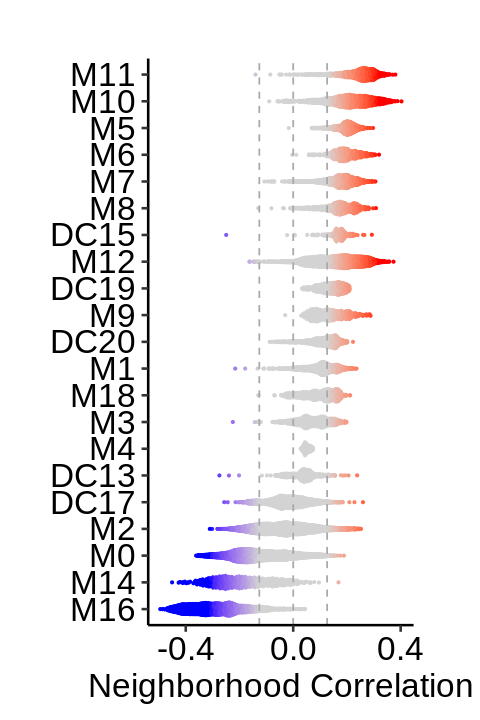

In [49]:
meta = meta %>% mutate(final_annotation_num = final_annotation %>% str_split('. ') %>% map(1) %>% unlist)
pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


violin_plot <- ggplot(meta, aes(y = reorder(final_annotation_num, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    sig_cmap+
                    scale_x_continuous(breaks = breaks) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = tickfontsize) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = labelfontsize, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = labelfontsize, hjust=1),
                        axis.title = element_text(size=labelfontsize, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black'),
                        axis.line.y.left   = element_line(color = 'black'),
                        plot.margin = margin(10, 40, 10, 10)
                         
                         )

height = 6
width = 4
fig.size(height, width)
outplot = violin_plot #+ plot_layout(heights = c(6, 1.5))
outplot


Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`
Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`
Orientation inferred to be along y-axis; override with
`position_quasirandom(orientation = 'x')`


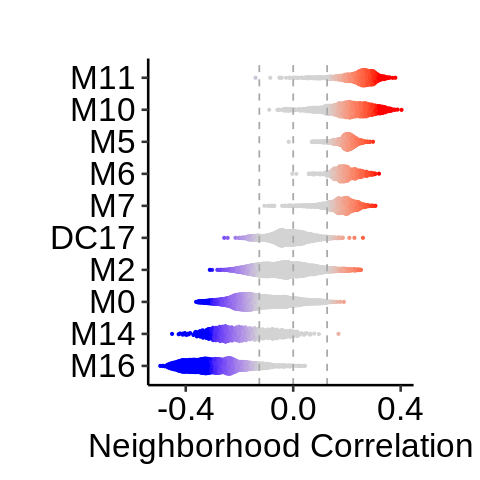

In [48]:
meta = meta %>% mutate(final_annotation_num = final_annotation %>% str_split('. ') %>% map(1) %>% unlist)
pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


violin_plot <- ggplot(meta %>% filter(new_cluster_number %in% subset), aes(y = reorder(final_annotation_num, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    sig_cmap + 
                    scale_x_continuous(breaks = breaks) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = tickfontsize) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = labelfontsize, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = labelfontsize, hjust=1),
                        axis.title = element_text(size=labelfontsize, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black'),
                        axis.line.y.left   = element_line(color = 'black'),
                        plot.margin = margin(10, 40, 10, 10)
                         
                         )

height = 4
width = 4
fig.size(height, width)
outplot = violin_plot #+ plot_layout(heights = c(6, 1.5))
outplot

ggsave(paste0(figdir, 'myeloid_violin_plot.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_violin_plot.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)

In [18]:
ci_summary <- meta %>% 
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/case_control.rds') %>% 
            mutate(new_cluster_number = as.numeric(str_remove(cluster, "cluster")),
               OR.ci = paste0("(", round(Type.OR.95pct.ci.lower, 3), ", ", 
                              round(Type.OR.95pct.ci.upper, 3), ")")) %>% 
        select(new_cluster_number, OR.ci)

summary <- ci_summary %>% left_join(res)
write.csv(summary, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/myeloid_casecontrol_corr_04152024.csv', quote = FALSE, row.names = FALSE)

Joining, by = "new_cluster_number"


### Pseudobulk DE

In [4]:
out <- mclapply(unique(qcd_meta$sample), pseudobulk, qcd_meta, qcd_norm,
               mc.cores = 6)
myeloid_pb <- data.frame(do.call(rbind, out))

In [5]:
sample_stats <- qcd_meta %>% group_by(sample) %>% summarize(avg_count = mean(nCount_RNA), avg_mt = mean(percent.mt))
myeloid_pb <- myeloid_pb %>% left_join(sample_stats) %>% left_join(unique(qcd_meta %>% select(sample, Type)))
myeloid_pb <- myeloid_pb[grep("cells", myeloid_pb$sample), ]
colnames(myeloid_pb)[1:36601] <- rownames(qcd_norm)

Joining, by = "sample"
Joining, by = "sample"


In [6]:
saveRDS(myeloid_pb, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_norm_pseudobulk_12072023.rds')

In [19]:
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_norm_pseudobulk_12072023.rds')

In [ ]:
de_out <- mclapply(rownames(qcd_norm), de, myeloid_pb, mc.cores = 20)

In [ ]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [ ]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_case_control_differential_expression_120722023.rds')

In [2]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_case_control_differential_expression_120722023.rds')

In [3]:
de_df <- na.omit(de_df)

In [8]:
genes <- c("FKBP5", "CEBPD", "CXCR4", "ZBTB16",
           "PRDX1", "STAT1", "SIGLEC1", "IFI6")

Warning message:
“Removed 19763 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 73 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


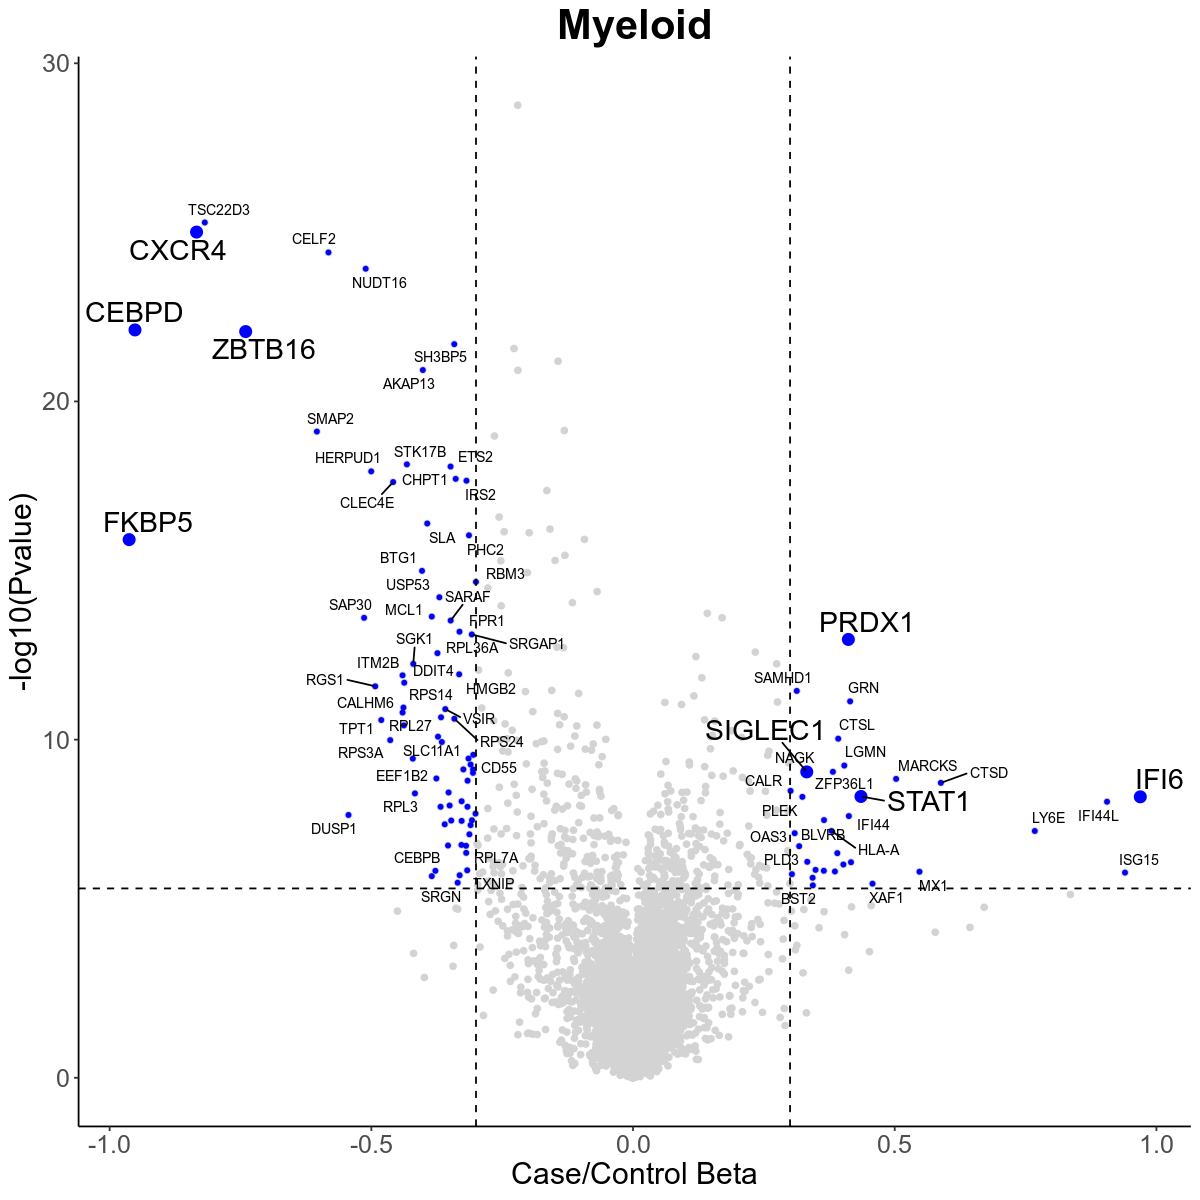

In [11]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(LRP))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(LRP)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.3, 0.3), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05/nrow(de_df)), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(LRP < 0.05/nrow(de_df) & abs(Beta) >= 0.3 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(LRP), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Case/Control Beta", y = "-log10(Pvalue)", title = "Myeloid")

### MASC

In [ ]:
model_df <- sc_meta %>% select(sample, processing.batch, Type, nCount_RNA, percent.mt, new_cluster_number)
model_df <- model_df %>% 
                mutate(Type = ifelse(Type == "LN", 1, 0),
                       nCount_RNA = log(nCount_RNA))

In [81]:
res <- MASC.me(model_df, factor(model_df$new_cluster_number),
                contrast = "Type",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Using null model: cluster ~ nCount_RNA + percent.mt + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0990409 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”
Creating logistic mixed models for cluster15

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converg

In [83]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/case_control.rds')

In [21]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/case_control.rds')

In [22]:
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

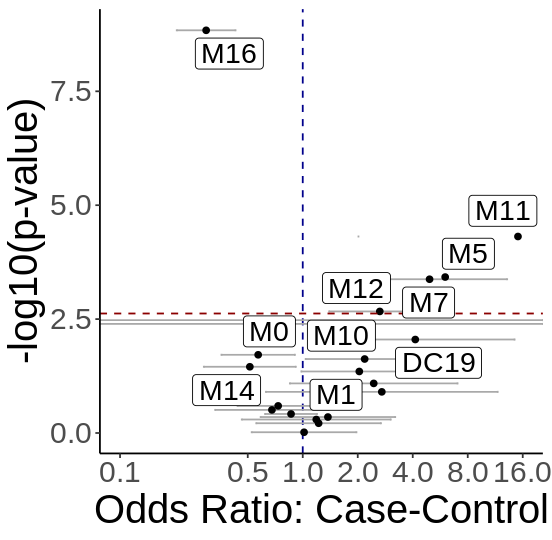

In [51]:
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = Type.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds Ratio: Case-Control") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=Type.OR.95pct.ci.lower, 
                                  xmax=Type.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(limits= c(0.1, 16), breaks = c(0.1, 0.5, 1, 2, 4, 8, 16)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = labelfontsize+4),
                      axis.text = element_text(size = tickfontsize+2),
                     text=element_text(family="Arial"))

height = 4.5
width = 4.6

fig.size(height, width)
outplot = masc_plot
outplot

# ggsave(paste0(figdir, 'myeloid_masc_casectrl.png'), plot = outplot,  
#        height = height, width = width, dpi = 500)
# ggsave(paste0(figdir, 'myeloid_masc_casectrl.pdf'), plot = outplot,  
#        height = height, width = width, dpi = 500, device = cairo_pdf)


In [91]:
xmax  = (res[c('Type.OR.95pct.ci.upper')] %>% log2 %>% abs)[
    res[c('Type.OR.95pct.ci.upper')] %>% log2 %>% abs 
    %>% rowSums %>% is.finite, ] %>% max


xmin  =-( (res[c('Type.OR.95pct.ci.lower')] %>% log2 %>% abs)[
    res[c('Type.OR.95pct.ci.lower')] %>% log2 %>% abs 
    %>% rowSums %>% is.finite, ] %>% max)


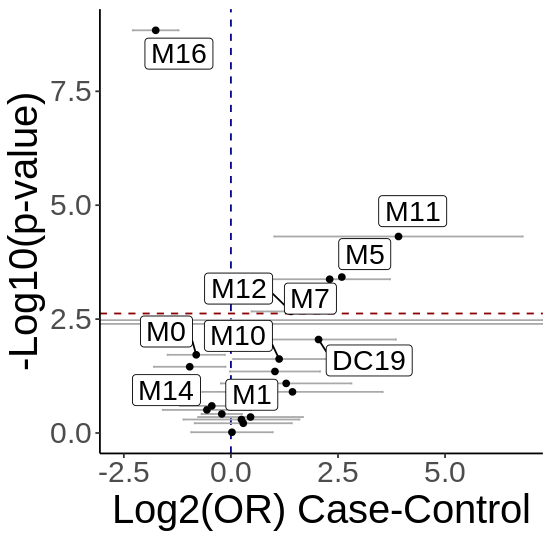

In [97]:
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = log2(Type.OR), y = -log10(model.pvalue))) +
                theme_classic() + ylab("-Log10(p-value)") + xlab("Log2(OR) Case-Control") +
                geom_vline(xintercept = 0, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=log2(Type.OR.95pct.ci.lower), 
                                  xmax=log2(Type.OR.95pct.ci.upper)), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                xlim(c(xmin, xmax)) +
                # scale_x_log10(limits= c(0.1, 16), breaks = c(0.1, 0.5, 1, 2, 4, 8, 16)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = labelfontsize+4),
                      axis.text = element_text(size = tickfontsize+2),
                     text=element_text(family="Arial"))

height = 4.5
width = 4.6

fig.size(height, width)
outplot = masc_plot
outplot

ggsave(paste0(figdir, 'myeloid_masc_casectrl.png'), plot = outplot,  
       height = height, width = width, dpi = 500)
ggsave(paste0(figdir, 'myeloid_masc_casectrl.pdf'), plot = outplot,  
       height = height, width = width, dpi = 500, device = cairo_pdf)


## WITHIN CASE ASSOCIATIONS

In [24]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

In [25]:
qcd_meta <- qcd_meta %>% select(-final_annotation)
final_annotation = data.frame(new_cluster_number = seq(0, 20), 
                                    final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPNMNBhigh NUPR1low Resident Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ cDC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC'))

qcd_meta <- qcd_meta %>% left_join(final_annotation)

myeloid_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_rawcounts_03102023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(myeloid_rawcounts[mito_genes_subset, ]) / colSums(myeloid_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)
qcd_meta <- left_join(qcd_meta, percent_mito)

Joining, by = "new_cluster_number"
Joining, by = c("cell", "percent.mt")


In [4]:
first_biop_pred <- readRDS("/data/srlab2/qxiao/AMP-SLE/data/clinical/df_pred_biop.rds") %>% 
                        mutate(individual = str_split(Subject_ID, '-')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[2])

In [5]:
sc_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'scRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        filter(Type == "LN") %>% 
                        select(c(cell, paste0('hPC', 1:20), Sex, hUMAP1, hUMAP2, sample, new_cluster_number, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

sn_meta <- qcd_meta[, !colnames(qcd_meta) %in% colnames(clinical)] %>% 
                        mutate(kid_sample = qcd_meta$sample) %>% 
                        filter(dataset == 'snRNAseq') %>% 
                        mutate(individual = str_split(kid_sample, '_')) %>% 
                        rowwise() %>% 
                        mutate(individual = unlist(individual)[3]) %>% 
                        left_join(clinical) %>% 
                        left_join(first_biop_pred) %>% 
                        filter(Type == "LN") %>% 
                        select(c(cell, paste0('hPC', 1:20), Sex, hUMAP1, hUMAP2, sample, new_cluster_number, final_annotation,
                                 Responder.Status, Age, Race, Final_ISN, Final_Chronicity, Final_Activity, Type, Final_Site,
                                 First_biop, Pred_use)) 

Joining, by = "individual"
Joining, by = "individual"
Joining, by = "individual"
Joining, by = "individual"


### RESPONSE

In [290]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")



write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sn_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sn_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sn_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [12]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[which(meta$Responder.Status %in% c("NR", "CR", "PR"))]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

sc_pt_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/sc_injured_pt_prop_07142023.rds')

meta <- left_join(meta, sc_pt_meta)



write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sc_meta_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sc_harmony_response.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/age_sex_response_race/sc_umap_response.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"
Joining, by = "sample"


### Chronicity

In [6]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Chronicity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [7]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Chronicity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


#### RESULTS - NO CONDITIONING

In [53]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_activity_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_activity_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

#### MASC

In [487]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Chronicity",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt", "Final_Activity"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + Final_Activity + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Creating logistic mixed models for cluster20

Creating logistic mixed models for cluster3

Creating logistic mixed models for cluster4

Creating logistic mixed models for cluster5

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with ma

In [488]:
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

In [494]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/chronicity_tested_activity_conditioned.rds')

Warning message:
“Removed 10 rows containing missing values (`geom_label_repel()`).”


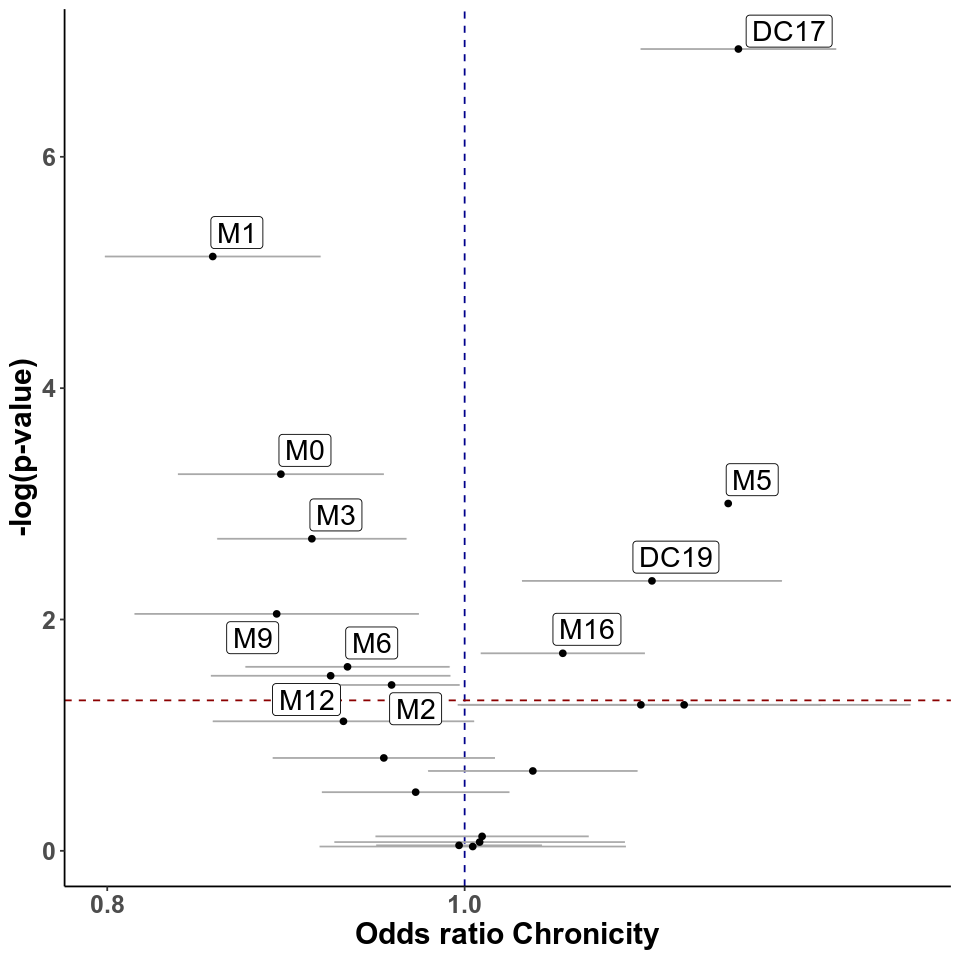

In [489]:
fig.size(8, 8)
ggplot(data = res %>% mutate(label = ifelse(-log10(model.pvalue) > -log10(0.05), cluster, NA)), 
       aes(x = Final_Chronicity.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log(p-value)") + xlab("Odds ratio Chronicity") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=Final_Chronicity.OR.95pct.ci.lower, xmax=Final_Chronicity.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(.05), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.2, 0.4, 0.6, 0.8, 1, 2.0, 3.0, 4.0, 6.0, 10.0, 16.0)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

#### CNA

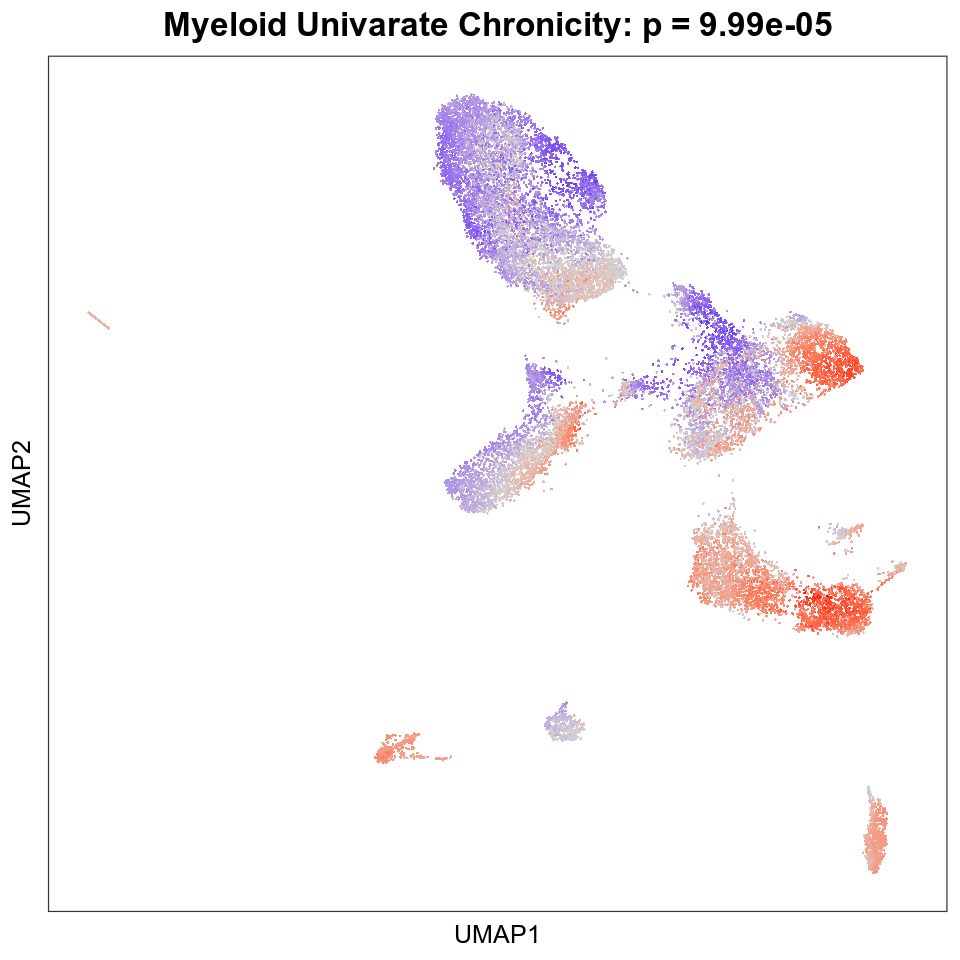

In [55]:
fdr_10 <- fdrs %>% filter(fdr < 0.10) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)


tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_10, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
ggplot() + 
        geom_point(data = qcd_meta %>% filter(dataset == 'scRNAseq'),
                     aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', alpha = 0.1,
                   size = 0.75, stroke = 0.0001) +
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation),
       size = 0.75, stroke = 0.0001) +  
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
      labs(x="UMAP1", y="UMAP2", title = "Myeloid Univarate Chronicity: p = 9.99e-05") +
      theme_bw(base_size = 15) +
  theme( legend.position = "none",
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(color="black", hjust = 0.5, face = "bold", size=20)
  ) 

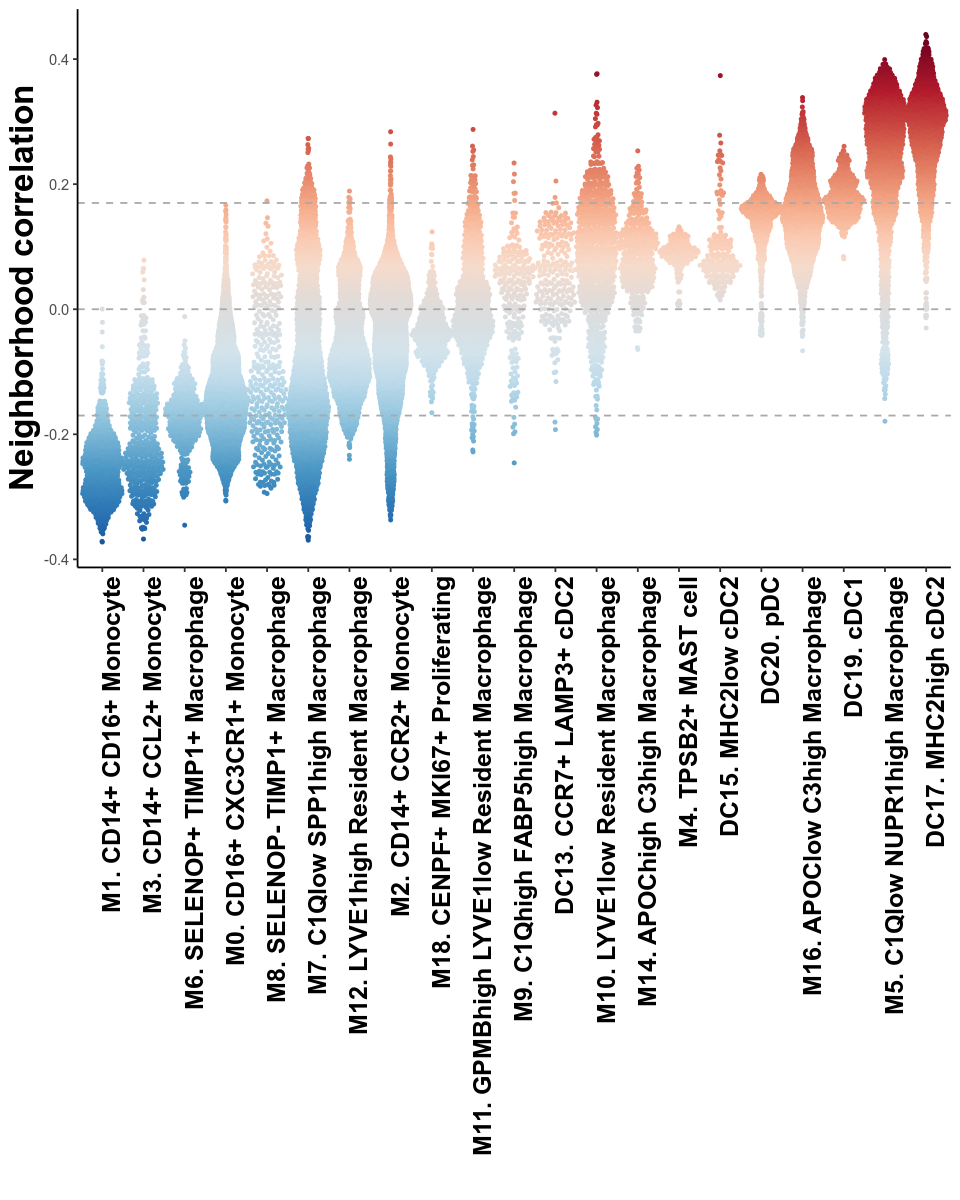

In [640]:
pos_fdr_thresh <- fdr_10
neg_fdr_thresh <- -1 * fdr_10

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
fig.size(10, 8)

cluster_order <- meta %>% select(final_annotation, ncorr) %>% group_by(final_annotation) %>% summarize(ncorr = mean(ncorr)) %>% arrange(ncorr) %>% pull(final_annotation)


ggplot(meta, aes(x = reorder(final_annotation, ncorr), y = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.5, size = 0.75) +
    geom_hline(yintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
    labs( x= "", y = "Neighborhood correlation") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        plot.title = element_text(color="black", size=22, face = "bold"),
        axis.text.x = element_text(color = "black", size = 15, angle = 90, hjust=1, face = "bold"),
        axis.title = element_text(size=20, face = "bold"))

#### RESULTS - CONDITIONING

In [2]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

In [109]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')

ci_summary <- meta %>% left_join(qcd_meta %>% select(cell, new_cluster_number)) %>% 
                select(new_cluster_number, cell, ncorr) %>% 
                group_by(new_cluster_number) %>% 
                summarize(ncorr.ci = paste0("(", round(mean(ncorr) - 1.96 * sd(ncorr) / sqrt(length(cell)), 3),
                                      ", ", round(mean(ncorr) + 1.96 * sd(ncorr) / sqrt(length(cell)), 3), ")"))
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/chronicity_covariates.rds') %>% 
        mutate(new_cluster_number = as.numeric(str_remove(cluster, "cluster")),
               OR.ci = paste0("(", round(Final_Chronicity.OR.95pct.ci.lower, 3), ", ", 
                              round(Final_Chronicity.OR.95pct.ci.upper, 3), ")")) %>% 
        select(new_cluster_number, OR.ci)

summary <- ci_summary %>% left_join(res)
write.table(summary, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/myeloid_chronicity_corr_04152024.csv', quote = FALSE, row.names = FALSE,
            sep = "\t")

Joining, by = "cell"
Joining, by = "new_cluster_number"


#### MASC

In [4]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')

In [5]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Chronicity",
                random_effects = c("sample"),
                fixed_effects = c('First_biop', 'Responder_Status'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Joining, by = "cell"
Using null model: cluster ~ First_biop + Responder_Status + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Creating logistic mixed models for cluster20

Creating logistic mixed models for cluster3

Creating logistic mixed models for cluster4

Creating logistic mixed models for cluster5

Creating logistic mixed models for cluster6

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :

In [8]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/chronicity_covariates.rds')

In [9]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/chronicity_covariates.rds')

In [10]:
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

In [11]:
fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = Final_Chronicity.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio Chronicity") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=Final_Chronicity.OR.95pct.ci.lower, xmax=Final_Chronicity.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(breaks = c(0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = 18, face = "bold"),
                      axis.text = element_text(size = 15, face = "bold"),
                     text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure3/myeloid_masc.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

Warning message:
“Removed 14 rows containing missing values (`geom_label_repel()`).”
Warning message:
“Removed 14 rows containing missing values (`geom_label_repel()`).”


ERROR: Error in value[[3L]](cond): could not open file '/tmp/1631.tmpdir/RtmpqGU0ut/file4beaa235fb082.png'


plot without title

#### CNA

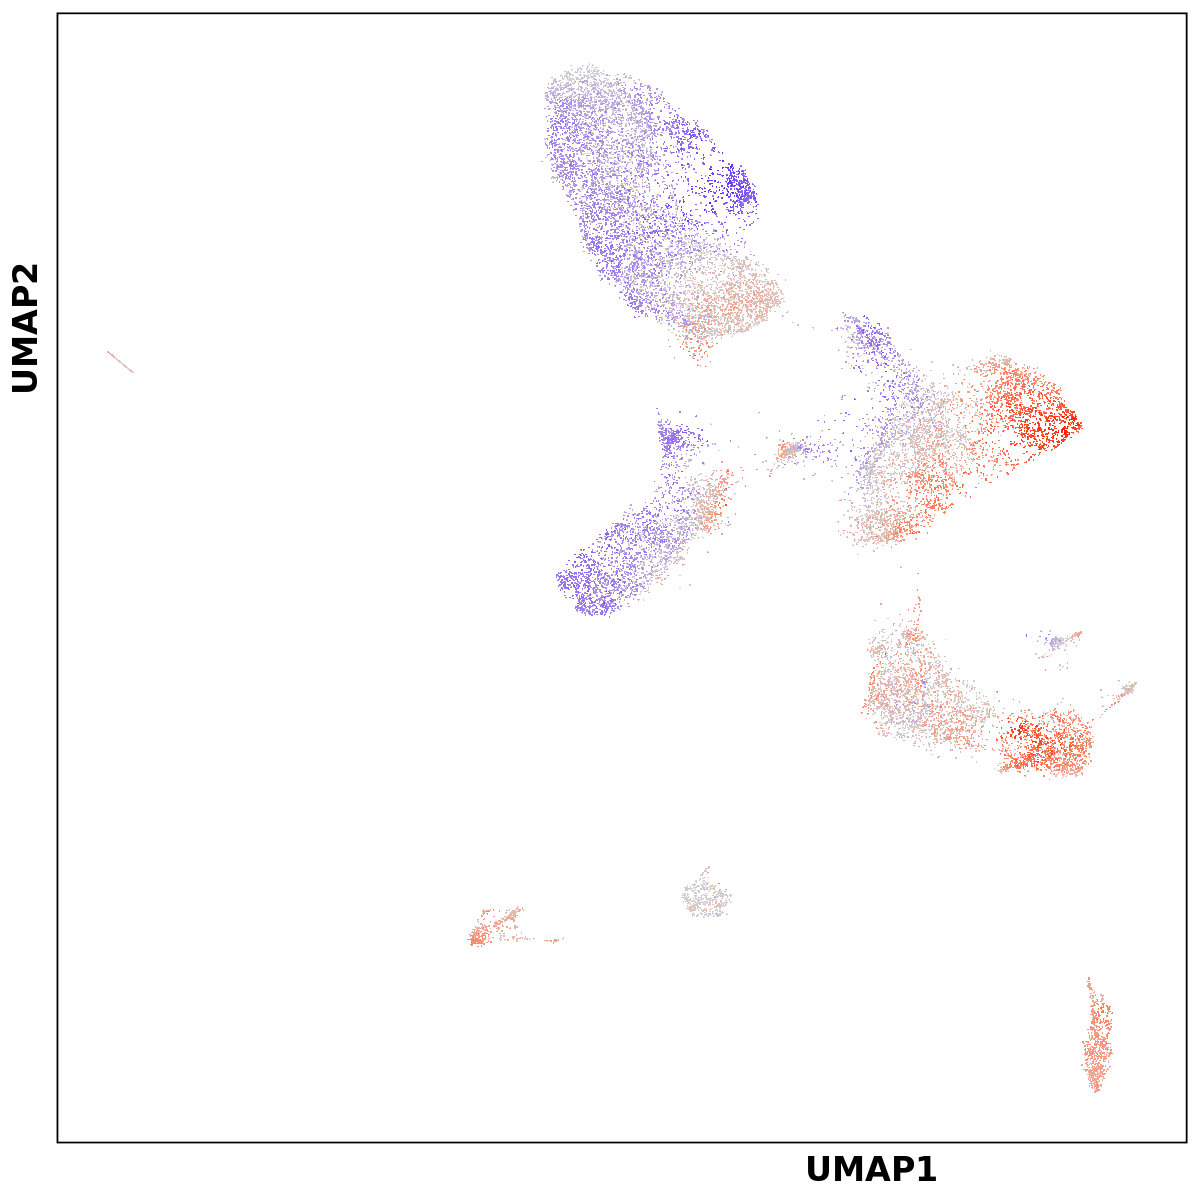

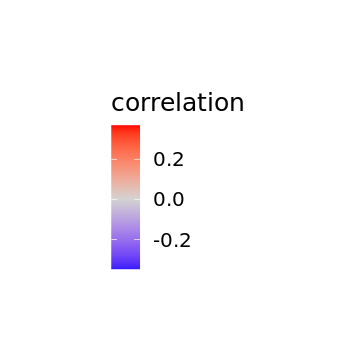

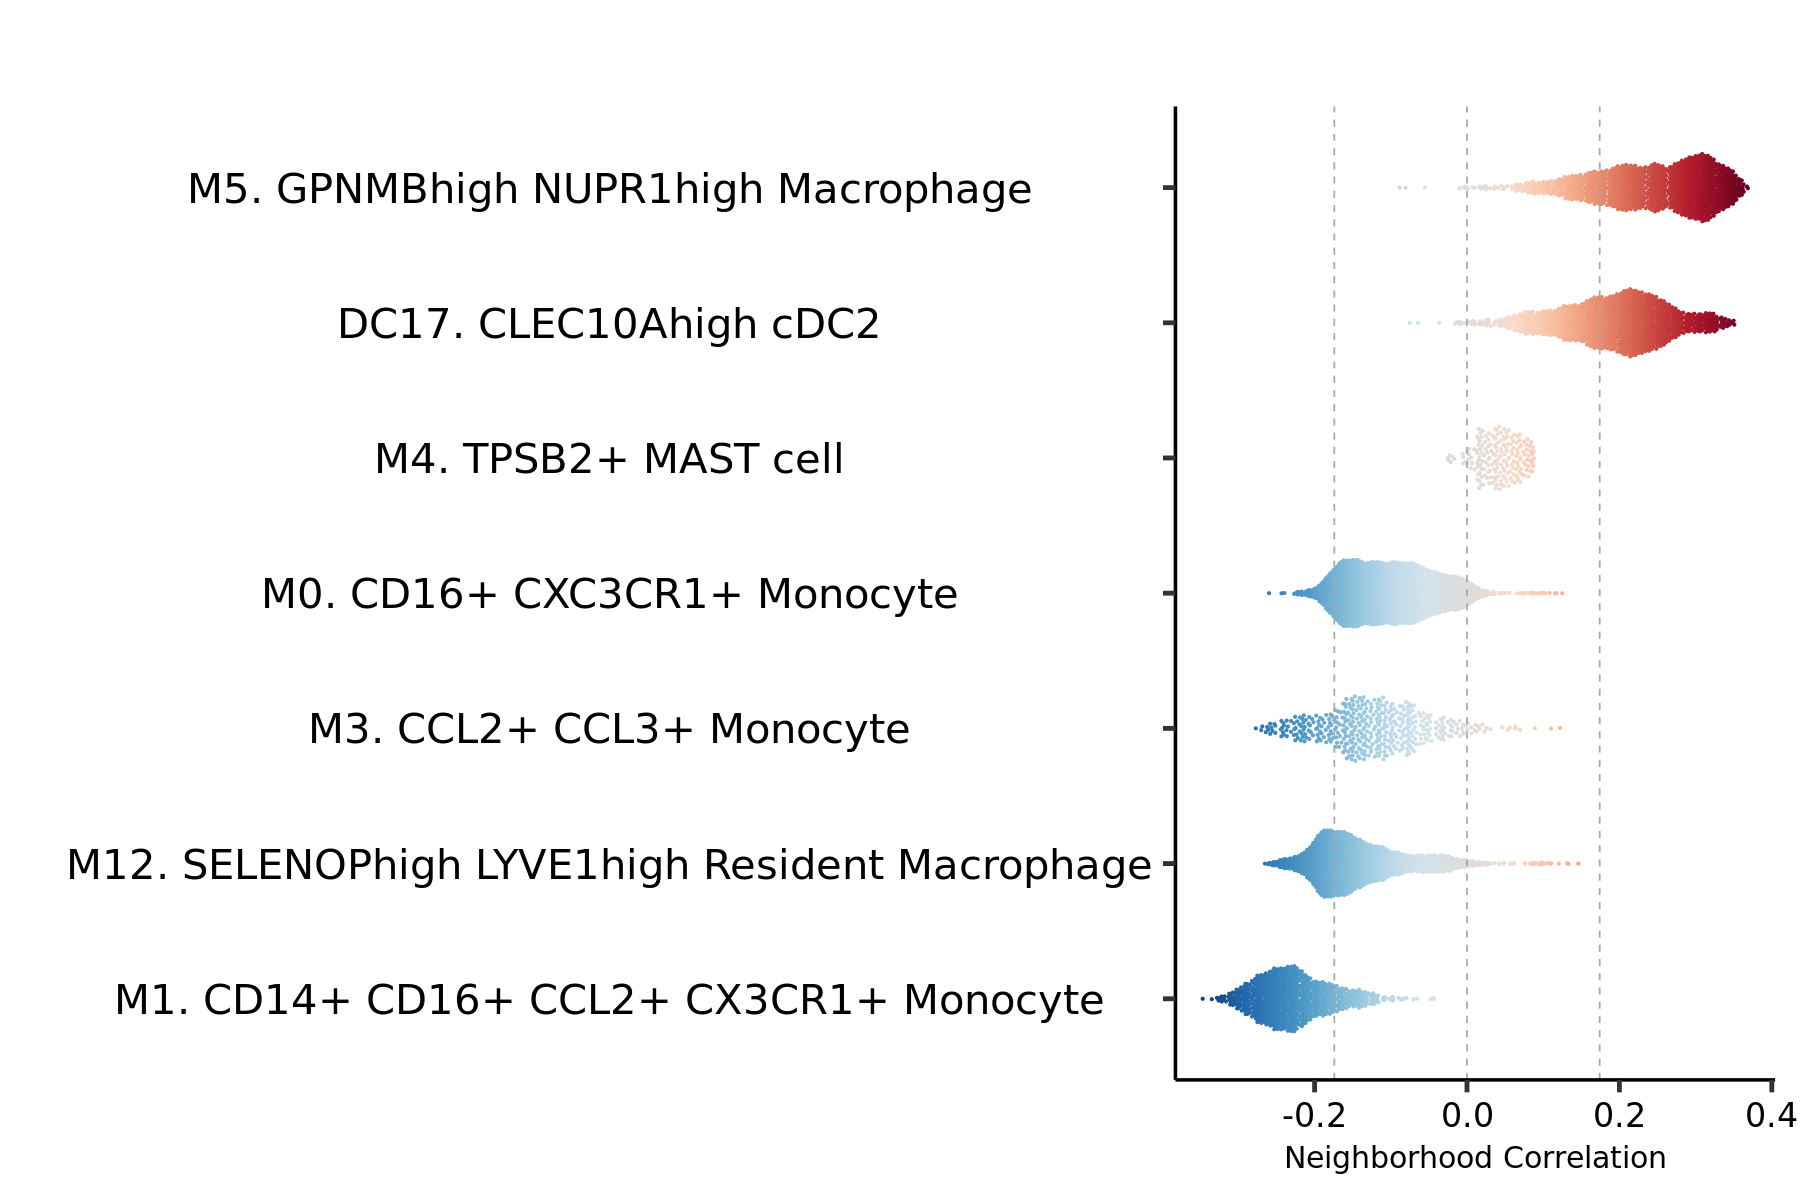

In [13]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
harmony <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_harmony.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')

fdrs <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_fdrs.csv', header = FALSE)
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_ncorr.csv', header = FALSE)

colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
subset <- c(0, 1, 3, 4, 5, 12, 17)

violin_plot <- ggplot(meta %>% filter(new_cluster_number %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 30) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_violin_plot.png",
       violin_plot,
       base_height = 10,
       base_width = 15)
fig.size(10, 15)
violin_plot

options(warn=0)

In [ ]:
meta <- meta %>% cbind(umap)


In [17]:
fig.size(10,10)
p <- plot_shuffled_features(meta, 
                       qcd_norm, 
                       "ISG15", pct = 0.95, pt_size = 0.75)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_isg_plot.png",
       violin_plot,
       base_height = 10,
       base_width = 10)

#### CNA Chronicity Prediction

In [14]:
meta <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv")
yresid_hat <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_yresid_hat.csv", header = TRUE)

In [16]:
yresid_predicted <- yresid_hat %>% 
                        left_join(meta %>% 
                                      select(Final_Chronicity, sample) %>%
                                         unique())

Joining, by = "sample"


In [24]:
cor.test(yresid_predicted$Predicted.Chronicity, yresid_predicted$Final_Chronicity)


	Pearson's product-moment correlation

data:  yresid_predicted$Predicted.Chronicity and yresid_predicted$Final_Chronicity
t = 5.942, df = 112, p-value = 3.242e-08
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3359075 0.6178595
sample estimates:
     cor 
0.489577 


`geom_smooth()` using formula = 'y ~ x'


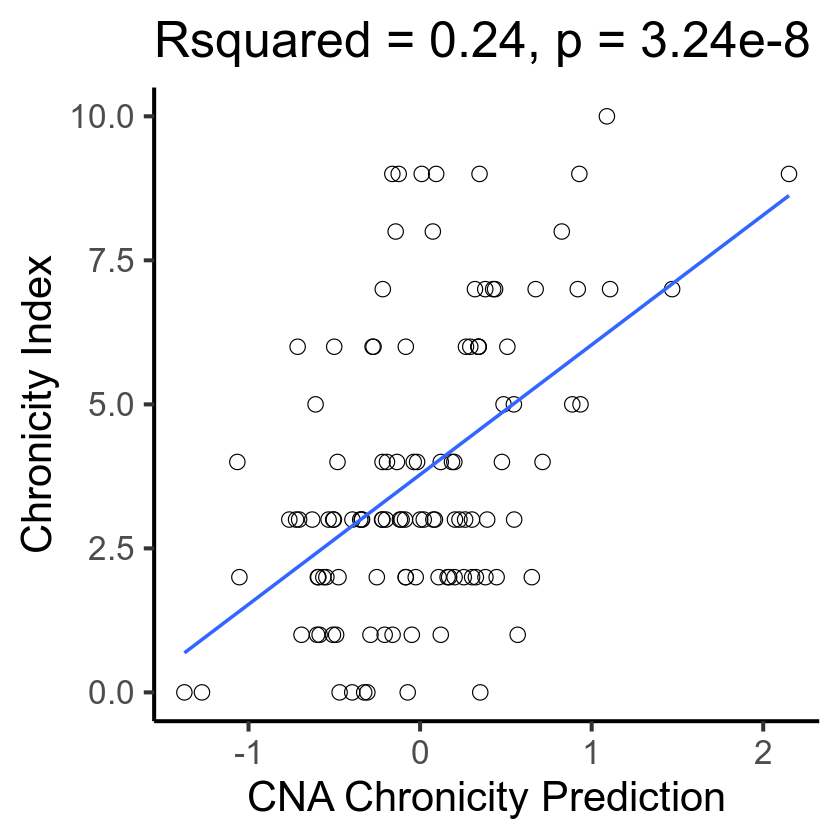

In [26]:
ggplot(yresid_predicted, aes(x = Predicted.Chronicity, y = Final_Chronicity)) + 
    geom_point(size = 4, shape = 1) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = "CNA Chronicity Prediction", 
         y = "Chronicity Index",
         title = "Rsquared = 0.24, p = 3.24e-8") + 
    theme_classic(base_size = 25) 

#### DE

In [135]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample, First_biop, Responder_Status, 
                              Final_Chronicity, avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.05 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + Final_Chronicity, data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['Final_Chronicity', 'Estimate']
        SE <- summary(m_1)$coefficients['Final_Chronicity', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [136]:
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_norm_pseudobulk_12072023.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')

In [137]:
myeloid_pb <- myeloid_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, First_biop, Responder_Status, Final_Chronicity) %>% 
                              unique())

Joining, by = "sample"


In [138]:
de_out <- mclapply(colnames(myeloid_pb)[1:36601], de, myeloid_pb, mc.cores = 20)

In [139]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [140]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_chronicity_differential_expression_03082024.rds')

In [141]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_chronicity_differential_expression_03082024.rds')

In [142]:
de_df <- de_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

In [143]:
genes <- c("NUPR1", "WFDC2", "TIMP1", "KLF2", "ALOX5AP", "CHIT1",
           "CCL4", "FCN1", "ISG15", "FCGR3A", "LST1")

Warning message:
“Removed 22156 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 85 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


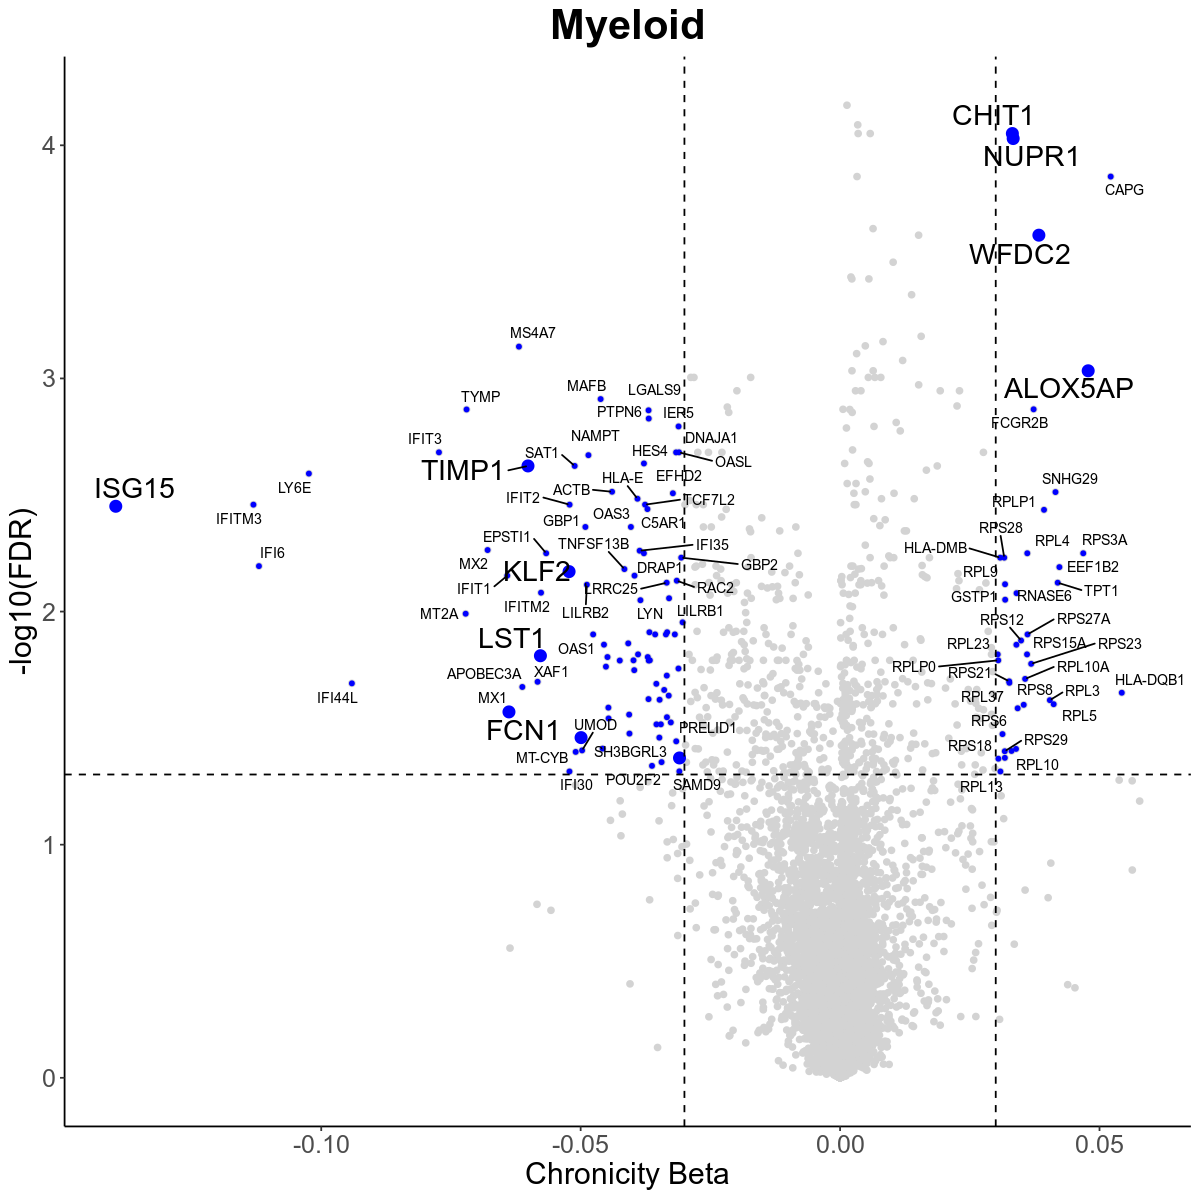

In [144]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.03,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.03, 0.03), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic() + 
    theme(legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR < 0.05 & abs(Beta) >= 0.03 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Chronicity Beta", y = "-log10(FDR)", title = "Myeloid")

In [13]:
qcd_norm <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_norm_10042022.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
ncorr <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_ncorr.csv', header = FALSE)
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')
meta <- meta %>% cbind(umap)
meta$ncorr <- ncorr$V1

In [14]:
cor.test(qcd_norm['ISG15', meta$cell], meta$ncorr)


	Pearson's product-moment correlation

data:  qcd_norm["ISG15", meta$cell] and meta$ncorr
t = -59.508, df = 21477, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.3876452 -0.3646835
sample estimates:
       cor 
-0.3762221 


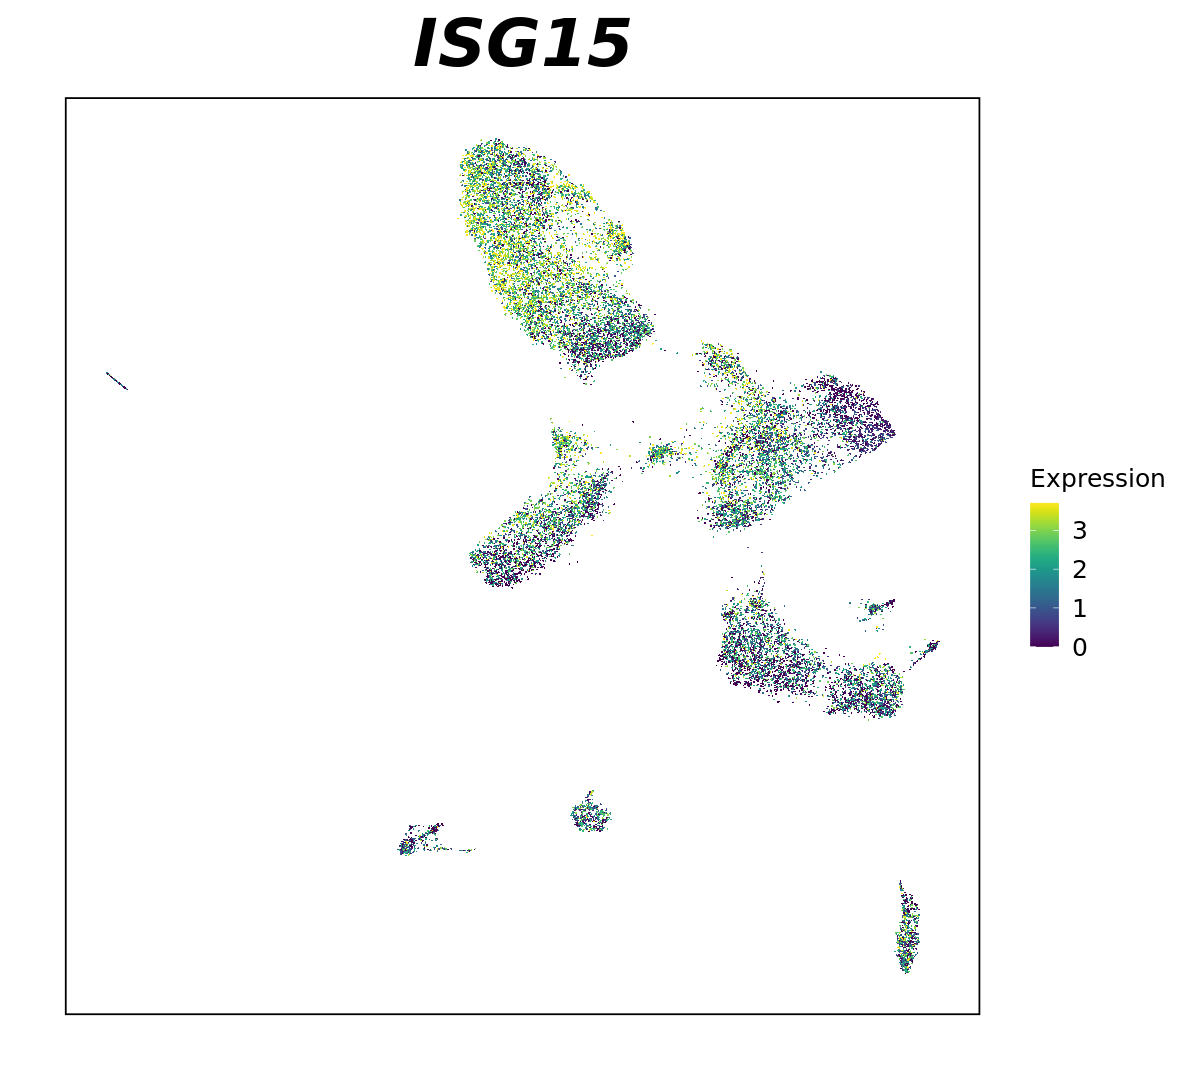

In [19]:
fig.size(9, 10)
p <- plot_shuffled_features(meta, 
                       qcd_norm, 
                       "ISG15", 
                       pct = 0.95, 
                       pt_size = 0.75)  + 
    theme(plot.title = element_text(size = 40),
          panel.border = element_rect(colour = "black", fill=NA, size=1),
          legend.text = element_text(size = 15),
          legend.title = element_text(size = 15))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_isg_plot.png",
       p,
       base_height = 9,
       base_width = 10)
p

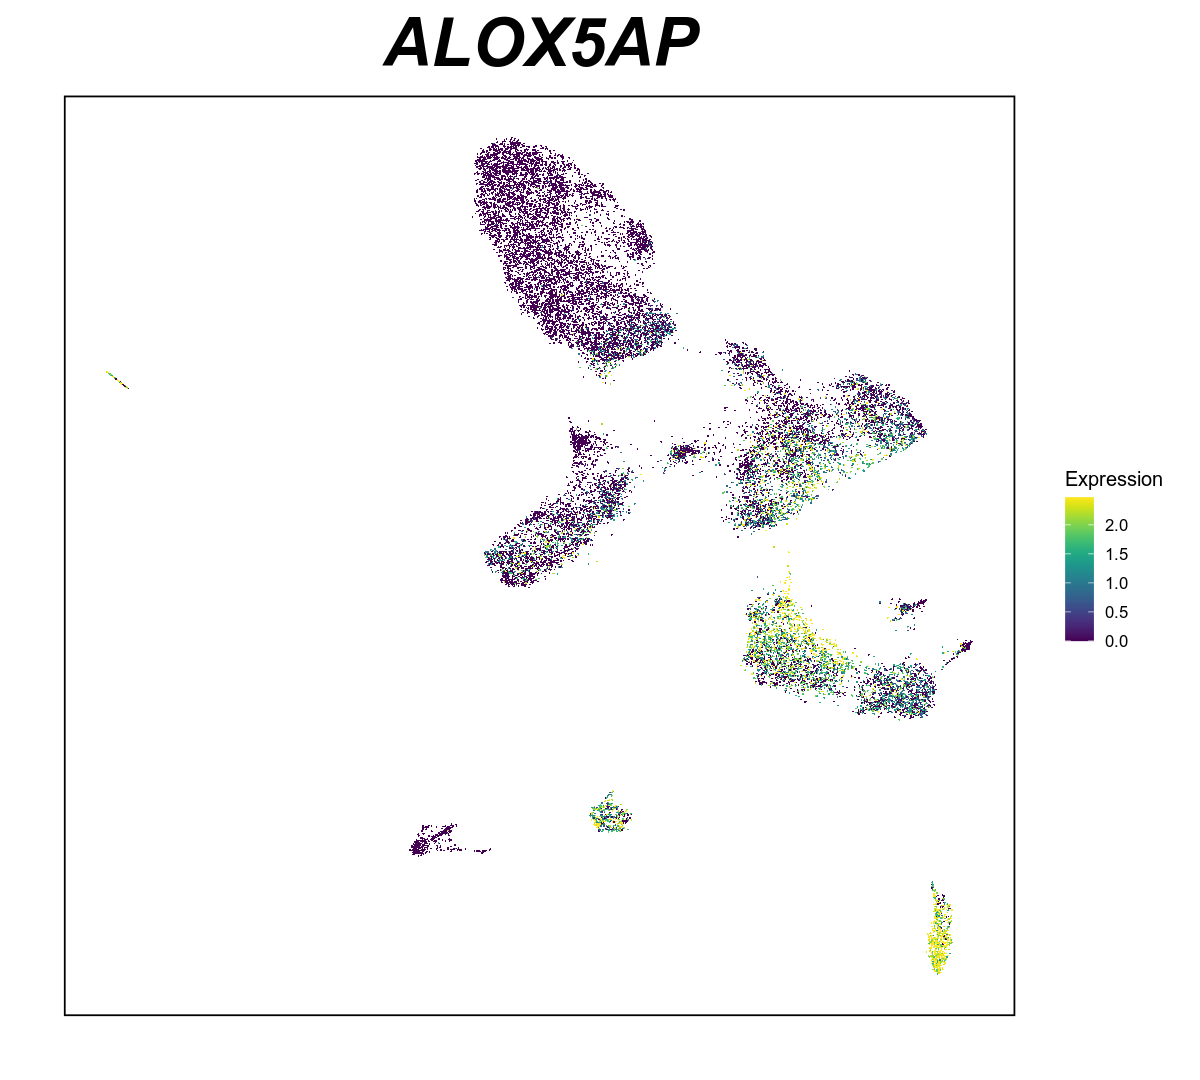

In [11]:
fig.size(9, 10)
plot_shuffled_features(meta, 
                       qcd_norm, 
                       "ALOX5AP", 
                       pct = 0.95, 
                       pt_size = 0.75) + 
    theme(plot.title = element_text(size = 40),
                    panel.border = element_rect(colour = "black", fill=NA, size=1))

#### ISG Score 

In [3]:
genes <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/isg_genes.rds')
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_norm_pseudobulk_12072023.rds')

In [4]:
chron_isg_pb <- myeloid_pb %>% 
                    mutate(individual = str_remove(sample, "AMPSLEkid_cells_")) %>% 
                    select(c(genes, individual)) %>% 
                    left_join(clinical %>% select(individual, Final_Chronicity)) 
for (i in genes) {
    chron_isg_pb[, i] <- as.numeric(chron_isg_pb[, i])
}
chron_isg_pb$isg_score <- rowMeans(chron_isg_pb[, genes])

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(genes)

  # Now:
  data %>% select(all_of(genes))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Joining, by = "individual"


In [5]:
cor.test(chron_isg_pb$Final_Chronicity, chron_isg_pb$isg_score)


	Pearson's product-moment correlation

data:  chron_isg_pb$Final_Chronicity and chron_isg_pb$isg_score
t = -4.4806, df = 139, p-value = 1.541e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.4916892 -0.2017914
sample estimates:
       cor 
-0.3552528 


In [6]:
p1 <- ggplot(chron_isg_pb, 
           aes(x = Final_Chronicity, y = isg_score)) +
    geom_point(shape = 21, size = 4) + 
    theme_classic(base_size = 20) + 
    geom_smooth(method = 'lm', se = FALSE) + 
    labs(x = 'Chronicity Index', 
         y = 'ISG Score',
         title = 'Myeloid : R = -0.355, p = 1.54e-4') + 
    theme(plot.title = element_text(hjust = 0.5),
          text=element_text(family="Arial"))

In [7]:
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure4/myeloid_isg_score.png",
       p1,
       base_height = 10,
       base_width = 10)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 42 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 42 rows containing missing values (`geom_point()`).”


### Activity

In [297]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Activity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]


meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [298]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- which(is.na(meta$Final_Activity))
meta <- meta[-ind, ]
harmony <- harmony[-ind, ]
umap <- umap[-ind, ]


meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


#### RESULTS

In [3]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

#### MASC

In [4]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Activity",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", "percent.mt"),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11



In [ ]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/activity_uni.rds')

In [5]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_Activity",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", 
                                  "percent.mt", 
                                  'Pred_use', 
                                  "Final_ISN_.IV.",
                                  'Final_ISN_.IV..V.',
                                  'Final_ISN_.V.',
                                  'Final_Site_NYU',
                                  'Final_Site_JHU'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/activity_cond.rds')

Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + Pred_use + Final_ISN_.IV. + Final_ISN_.IV..V. + Final_ISN_.V. + Final_Site_NYU + Final_Site_JHU + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.115707 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 -

In [6]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/activity_cond.rds')

In [7]:
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

Warning message:
“Removed 20 rows containing missing values (`geom_label_repel()`).”


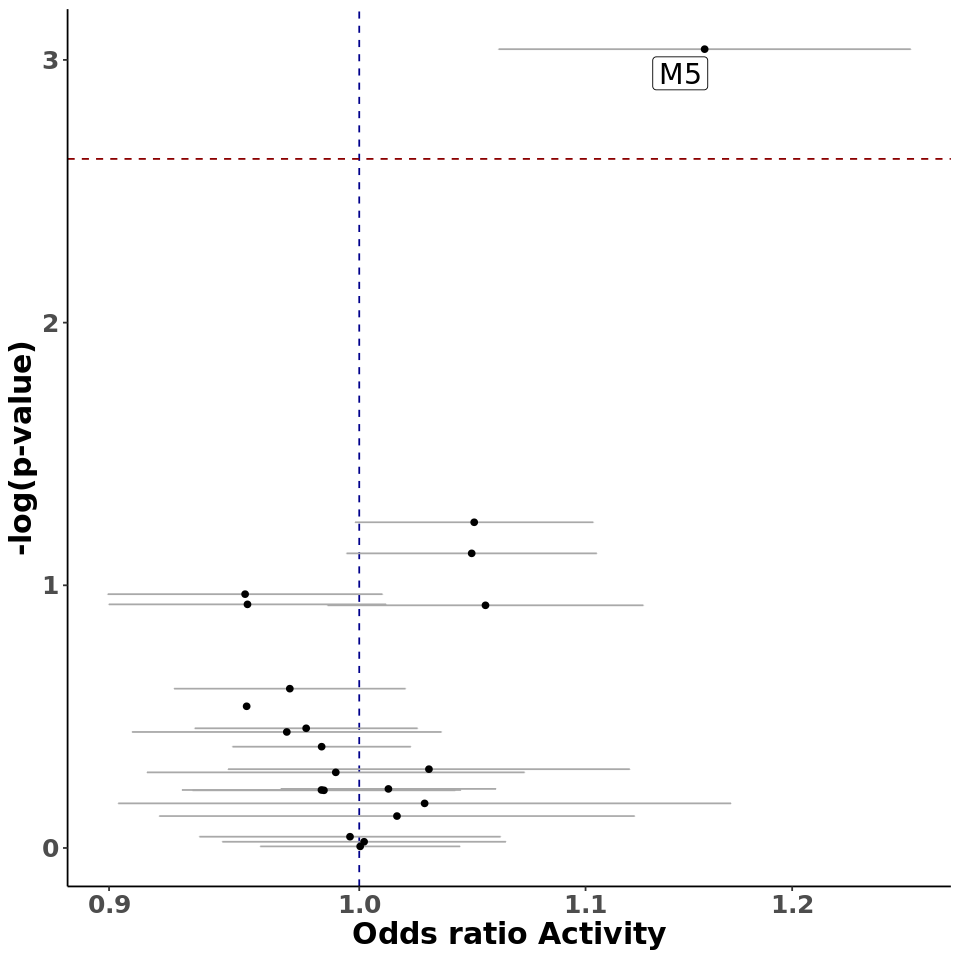

In [8]:
fig.size(8, 8)
ggplot(data = res %>% mutate(label = ifelse(-log10(model.pvalue) > -log10(0.05), cluster, NA)), 
       aes(x = Final_Activity.OR, y = -log10(model.pvalue))) +
    theme_classic() + ylab("-log(p-value)") + xlab("Odds ratio Activity") +
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=Final_Activity.OR.95pct.ci.lower, xmax=Final_Activity.OR.95pct.ci.upper), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(.05/21), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.2, 0.4, 0.6, 0.8, 0.9, 1, 1.1, 1.2, 2.0, 3.0, 4.0, 6.0, 10.0, 16.0)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6) +
    theme(axis.title = element_text(size = 18, face = "bold"),
          axis.text = element_text(size = 15, face = "bold"))

#### CNA

In [ ]:

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

meta <- meta %>% 
            select(-final_annotation) %>% 
            left_join(qcd_meta %>% select(cell, final_annotation))

fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_activity.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_legend_activity.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

pos_fdr_thresh <- fdr_5
neg_fdr_thresh <- -1 * fdr_5

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))

fig.size(3,6)
subset <- c("M5. GPNMBhigh NUPR1high Macrophage") 
ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
 #   scale_x_discrete(limits = cluster_order) +
    labs( x= "Neighborhood Correlation", y = "", title = "") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        axis.text.x = element_text(color = "black", size = 15, hjust=0.5),
        axis.text.y = element_text(color = "black", size = 18, hjust=0.5),
        axis.title = element_text(size=18, hjust = 0.5))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_violin_plot_activity.png",
       umap_legend,
       base_height = 3,
       base_width = 6)

Joining, by = "cell"


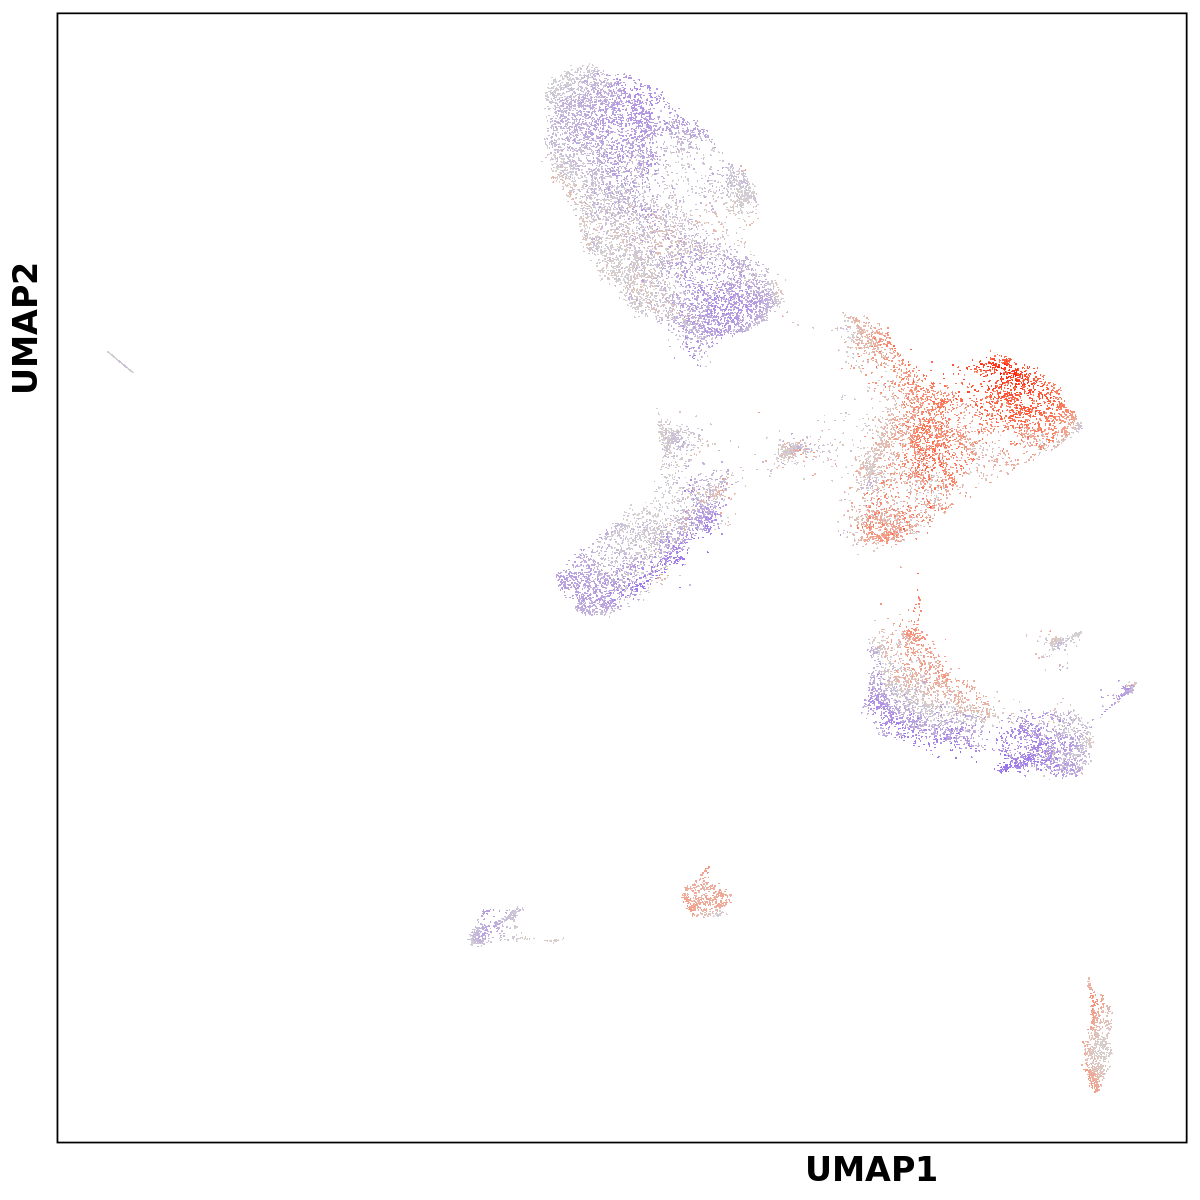

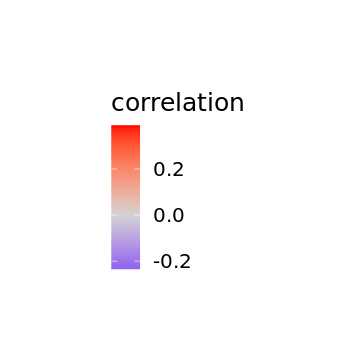

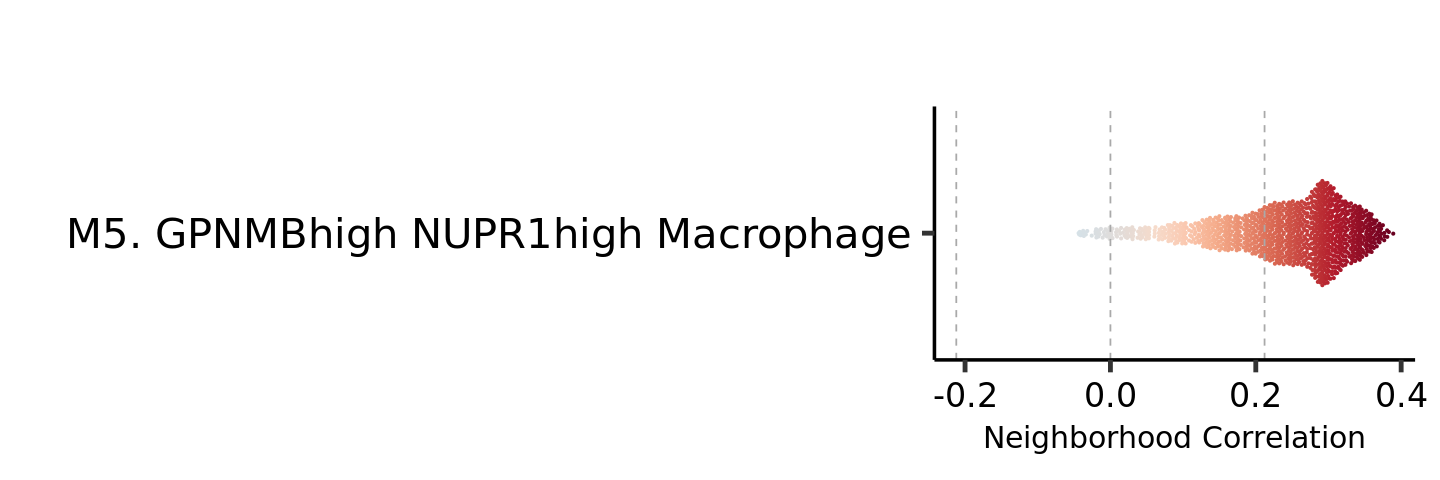

In [75]:
options(warn = -1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

meta <- meta %>% 
            select(-final_annotation) %>% 
            left_join(qcd_meta %>% select(cell, final_annotation))

fdr_5 <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_activity.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_legend_activity.png",
       umap_legend,
       base_height = 3,
       base_width = 3)


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

pos_fdr_thresh <- fdr_5
neg_fdr_thresh <- -1 * fdr_5

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))

fig.size(2,8)
subset <- c("M5. GPNMBhigh NUPR1high Macrophage") 
violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 30) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 20, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 25, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_violin_plot.png",
       violin_plot,
       base_height = 4,
       base_width = 12)
fig.size(4, 12)
violin_plot
options(warn=0)

#### DE

In [126]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample, , 
                              Final_Activity, avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.05 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + Final_Activity, data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['Final_Activity', 'Estimate']
        SE <- summary(m_1)$coefficients['Final_Activity', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [127]:
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_norm_pseudobulk_12072023.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/activity/sc_meta.csv')

In [128]:
myeloid_pb <- myeloid_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, Final_Activity) %>% 
                              unique())

Joining, by = "sample"


In [129]:
de_out <- mclapply(colnames(myeloid_pb)[1:36601], de, myeloid_pb, mc.cores = 20)

In [130]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [131]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_activity_differential_expression_05022024.rds')

In [42]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_activity_differential_expression_05022024.rds')

In [43]:
keep_genes <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_5pgenes_de.rds')

In [45]:
de_df <- de_df %>% 
            na.omit() %>% 
            filter(gene %in% keep_genes$genes) %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

In [47]:
genes <- c("SPP1", "APOE", "APOC1", "GPNMB", "CTSD", "FCN1", "FABP5", "CTSB", 
           "LST1", "FCN1", "AIF1", "CX3CR1", "CFD", "CFP", "CDKN1C")

Warning message:
“Removed 9597 rows containing missing values (`geom_text_repel()`).”


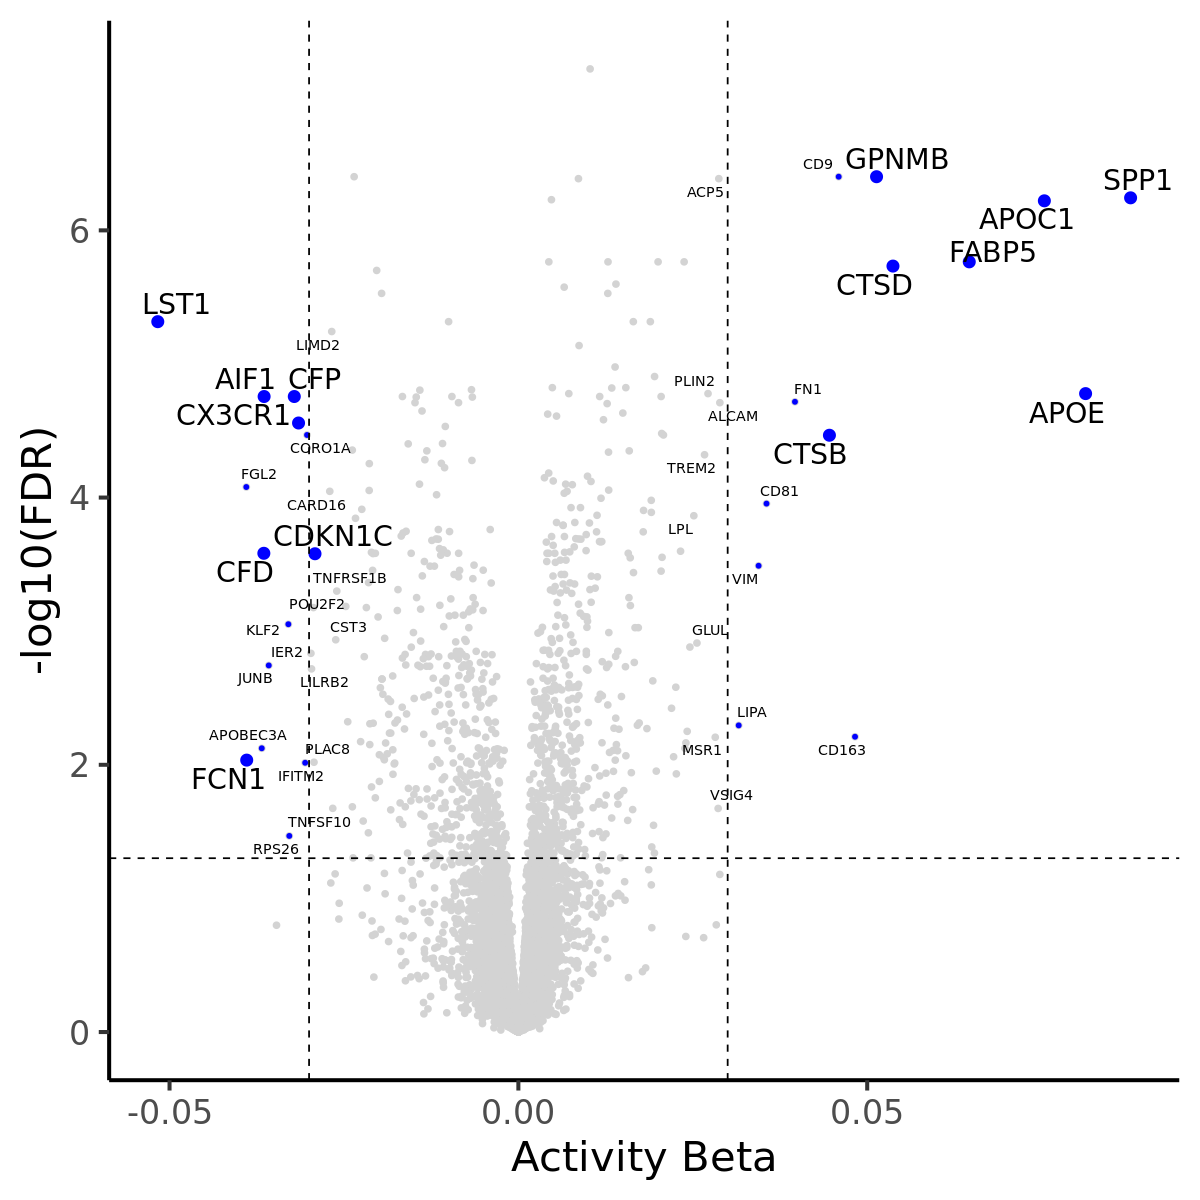

In [55]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.03,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.03, 0.03), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic(base_size = 25) + 
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR < 0.05 & abs(Beta) >= 0.025 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Activity Beta", y = "-log10(FDR)")

In [60]:
genes <- c("SPP1", "APOE", "APOC1", "GPNMB", "CTSD", "FABP5", "CTSB", 
           "LST1", "AIF1", "CX3CR1", "CFD", "CFP", "CDKN1C")

In [61]:
activity_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_activity_differential_expression_05022024.rds')
activity_df <- activity_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) %>%
            mutate(Var = "Activity") %>% filter(gene %in% genes) 

isn_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_classV_differential_expression_05022024.rds')
isn_df <- isn_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) %>%
            mutate(Var = "Class V") %>% filter(gene %in% genes)

In [84]:
fig.size(6, 12)
myeloid_de_df <- rbind(activity_df, isn_df)
activity_de_plot <- ggplot(activity_df, aes(y = Var,
                        x = gene, 
                        fill = Beta)) + 
                        geom_tile(width = 0.75, 
                                  height = 0.5) + 
                        theme_classic(base_size = 25) + 
                        labs(x = "Gene", y = "") + 
                        scale_fill_viridis(na.value = "white", ) + 
                        theme(legend.position = "bottom",
                              legend.text = element_text(size = 15, angle = 60, vjust = 0.75),
                              axis.text.x = element_text(angle = 90)) + 
                        scale_x_discrete(limits = genes) 
isn_de_plot <- ggplot(isn_df, aes(y = Var,
                        x = gene, 
                        fill = Beta)) + 
                geom_tile(width = 0.75, 
                          height = 0.5) + 
                theme_classic(base_size = 25) + 
                labs(x = "Gene", y = "") + 
                scale_fill_viridis(na.value = "white", ) + 
                theme(legend.position = "bottom",
                      legend.text = element_text(size = 15, angle = 60),
                      axis.text.x = element_text(angle = 90)) + 
                scale_x_discrete(limits = genes)

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/activity_de_plot.png",
       activity_de_plot,
       base_height = 6,
       base_width = 12)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/isn_de_plot.png",
       isn_de_plot,
       base_height = 6,
       base_width = 12)

### ISN

In [299]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('UMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))
ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


In [300]:
meta <- sn_meta %>% select(-c(colnames(sn_meta[grep('hPC', colnames(sn_meta))]), 
                          colnames(sn_meta[grep('UMAP', colnames(sn_meta))])))
harmony <- sn_meta %>% select(colnames(sn_meta)[grep('hPC', colnames(sn_meta))])

umap <- sn_meta %>% select(c(hUMAP1, hUMAP2))

ind <- c(1:nrow(meta))[!is.na(meta$Final_ISN)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))
meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)



meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")

write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sn_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sn_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sn_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "Responder.Status"


#### Results

In [11]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[IV]_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[IV]_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

#### MASC

In [468]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[V]_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[V]_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

In [523]:
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA)) %>% 
                select(sample, new_cluster_number,
                       Race_.A., Race_.B., Race_.W.,
                       percent.mt, nCount_RNA, First_biop,
                       Pred_use, Final_Site_JHU, Final_Site_NYU,
                       Final_ISN_.V., Final_Activity)


res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "Final_ISN_.V.",
                random_effects = c("sample"),
                fixed_effects = c('Final_Activity', 
                         'Pred_use',
                         'Race_.A.',
                         'Race_.B.',
                         'Race_.W.',
                         'First_biop',
                         'Final_Site_JHU',
                         'Final_Site_NYU'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)

Joining, by = "cell"
Using null model: cluster ~ Final_Activity + Pred_use + Race_.A. + Race_.B. + Race_.W. + First_biop + Final_Site_JHU + Final_Site_NYU + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Creating logistic mixed models for cluster19

Creating logistic mixed models for cluster2

Creating logistic mixed models for cluster20

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 1.4633 (tol = 0.002, component 1)”
Warning message in checkC

In [524]:
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/cond_ISN_V.rds')

In [29]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/cond_ISN_V.rds')

In [30]:
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

In [31]:
colnames(res) <- c("Cluster", "Size",
                   "model.pvalue", "ISN_V_OR",
                   "ISN_V_OR_95pct.lower",
                   "ISN_V_OR_95pct.higher",
                   "bonferonni")

Warning message:
“Removed 14 rows containing missing values (`geom_label_repel()`).”


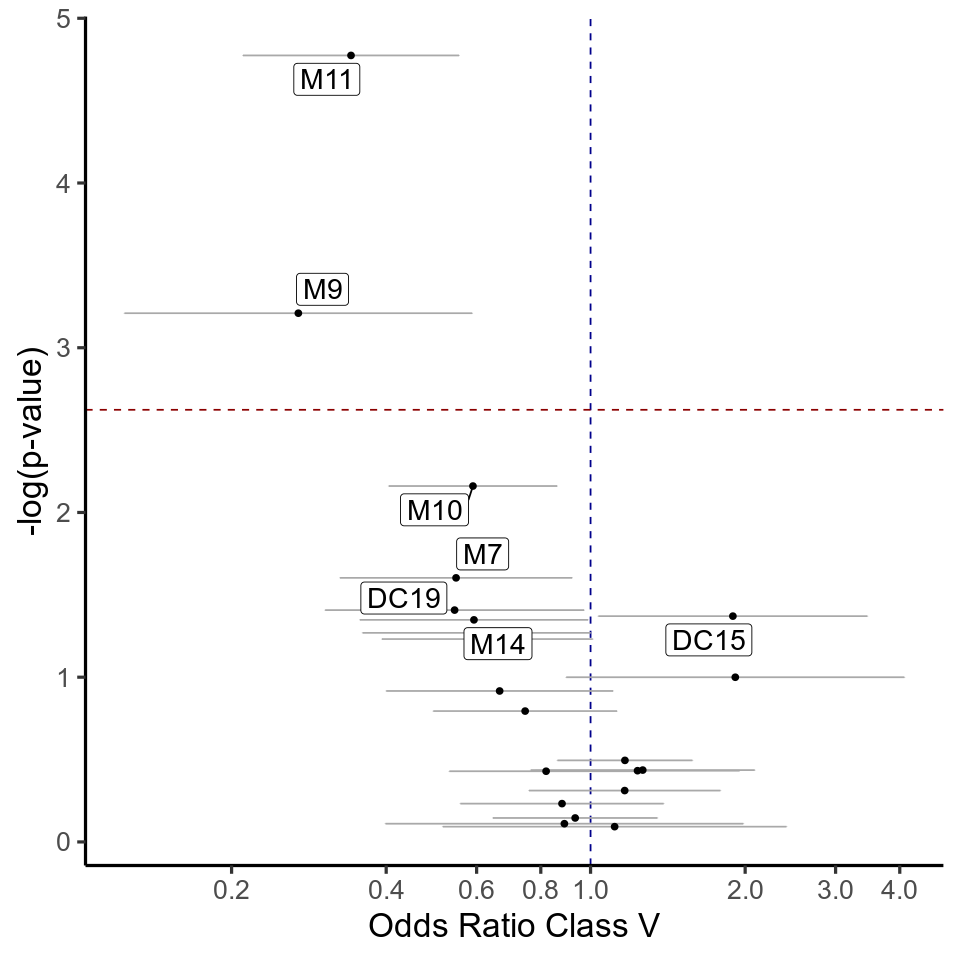

In [32]:
fig.size(8, 8)
ggplot(data = res %>% mutate(label = ifelse(-log10(model.pvalue) > -log10(0.05), Cluster, NA)), 
       aes(x = ISN_V_OR, y = -log10(model.pvalue))) +
    theme_classic(base_size = 20) + 
    labs(y = "-log(p-value)",
         x = "Odds Ratio Class V") + 
    geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
    geom_errorbar(aes(xmin=ISN_V_OR_95pct.lower	, 
                      xmax=ISN_V_OR_95pct.higher), col = "darkgrey") +
    geom_point() + 
    geom_hline(yintercept = -log10(.05/21), linetype = "dashed", color = "darkred") +
    scale_x_log10(breaks = c(0.2, 0.4, 0.6, 0.8, 1, 2.0, 3.0, 4.0, 6.0, 10.0, 16.0)) + 
    ggrepel::geom_label_repel(aes(label = label), size = 6)

#### CNA 

Joining, by = "cell"


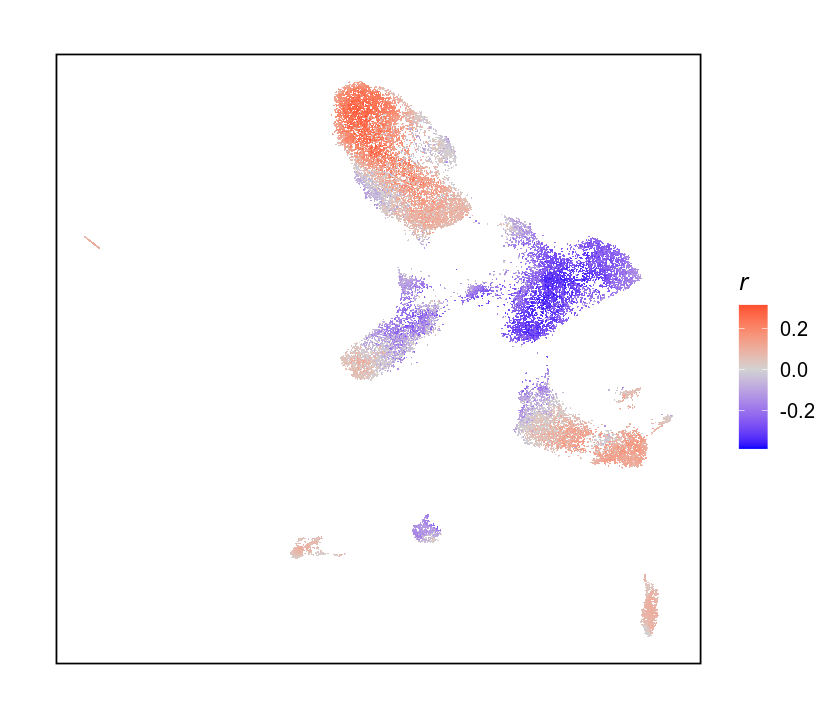

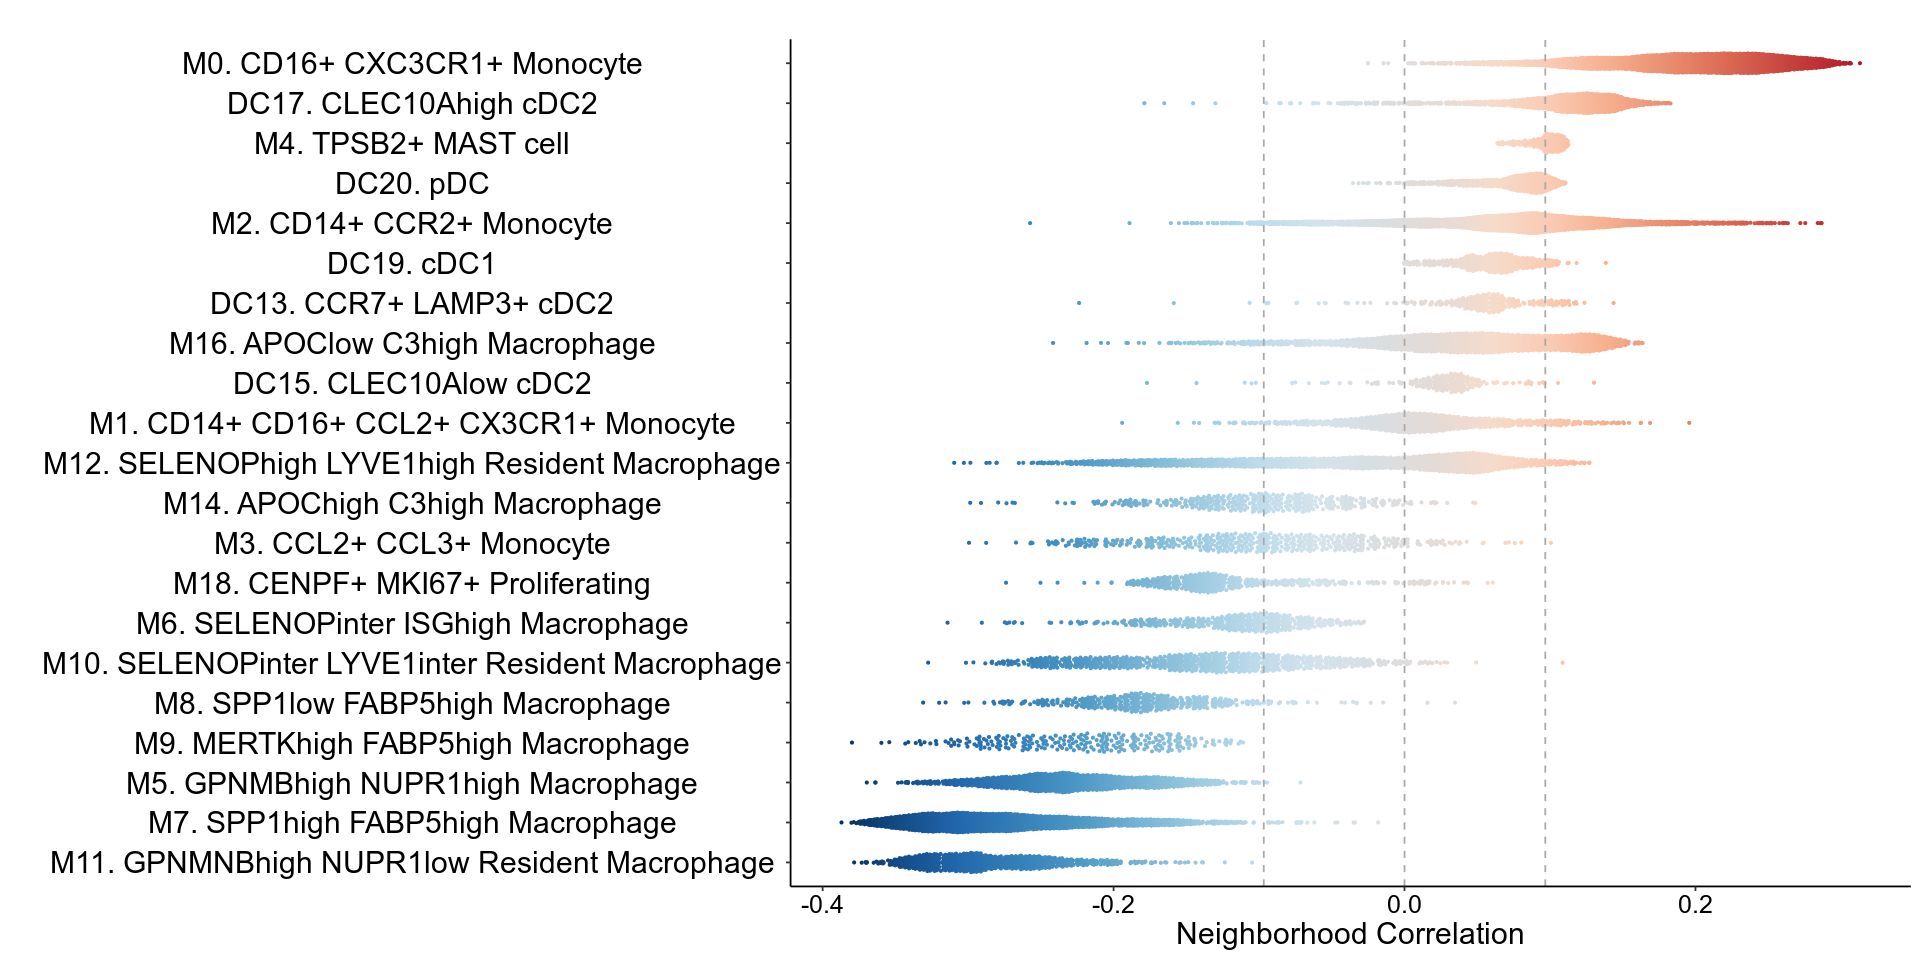

In [536]:
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[V]_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_ISN_[V]_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

meta <- meta %>% 
            select(-final_annotation) %>% 
            left_join(qcd_meta %>% select(cell, final_annotation))

fdr_5 <- fdrs %>% filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr_5, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(6, 7)
ggplot() + 
      geom_point(data = qcd_meta,
                 aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
                           #breaks = c(-0.3, -0.15, 0, 0.15, 0.3)) + 
     # labs(x="UMAP1", y="UMAP2", title = "T/NK Chronicity: p = 0.006") +
theme_classic(base_size = 15) +
  theme(legend.position = "right",
          plot.title = element_text(hjust = 0.5, 
                                    size = 18, 
                                    face = "bold"),
          axis.title = element_text(hjust = 0.75, 
                                    size = 20, 
                                    face = "bold"), 
          axis.text = element_blank(),
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          legend.title = element_text(face = "italic"),
          panel.border = element_rect(colour = "black", fill=NA, size=1)
) +
    labs(x="", y="", title = "", color = "r") 

myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

pos_fdr_thresh <- fdr_5
neg_fdr_thresh <- -1 * fdr_5

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


fig.size(8, 16)


ggplot(meta, aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
 #   scale_x_discrete(limits = cluster_order) +
    labs( x= "Neighborhood Correlation", y = "", title = "") +
    theme_classic() +
    theme(
        legend.position = "none",
        panel.grid = element_blank(),
        axis.text.x = element_text(color = "black", size = 15, hjust=0.5),
        axis.text.y = element_text(color = "black", size = 18, hjust=0.5),
        axis.title = element_text(size=18, hjust = 0.5))

In [28]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/cond_sc_ISN_[V]_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/cond_sc_ISN_[V]_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

meta <- meta %>% 
            select(-final_annotation) %>% 
            left_join(qcd_meta %>% select(cell, final_annotation))

fdr <- fdrs %>% 
            filter(fdr < 0.1) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_isn_class_V.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_cna_umap_legend_isn_class_V.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))

subset <- final_annotation %>% 
            filter(new_cluster_number %in% c(7, 9, 10, 11, 14, 15, 19)) %>% 
            pull(final_annotation)

fig.size(3,10)
violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                 #   scale_x_discrete(limits = cluster_order) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic() +
                    theme(
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 15, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 18, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure5/myeloid_violin_plot_isn_class_V.png",
       violin_plot,
       base_height = 3,
       base_width = 10)
options(warn=0)

Joining, by = "cell"


#### DE

In [108]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample,  
                              Final_ISN_.V., avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.05 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + Final_ISN_.V., data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['Final_ISN_.V.', 'Estimate']
        SE <- summary(m_1)$coefficients['Final_ISN_.V.', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [99]:
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_norm_pseudobulk_12072023.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/ISN/sc_meta.csv')

In [104]:
colnames(meta) <- str_remove_all(str_remove_all(colnames(meta), "\\["), "\\]")

myeloid_pb <- myeloid_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, Final_ISN_.V.) %>% 
                              unique())

Joining, by = "sample"


In [111]:
de_out <- mclapply(colnames(myeloid_pb)[1:36601], de, myeloid_pb, mc.cores = 20)

In [112]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [113]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/tissue/Myeloid_classV_differential_expression_05022024.rds')

In [114]:
de_df <- de_df %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

In [119]:
genes <- c("SPP1", "APOE", "FABP5", "APOC1", "CTSD", "GPNMB",
           "LST1", "PLAC8", "KLF2", "CDKN1C", "CFP", "CFD")

Warning message:
“Removed 22521 rows containing missing values (`geom_text_repel()`).”


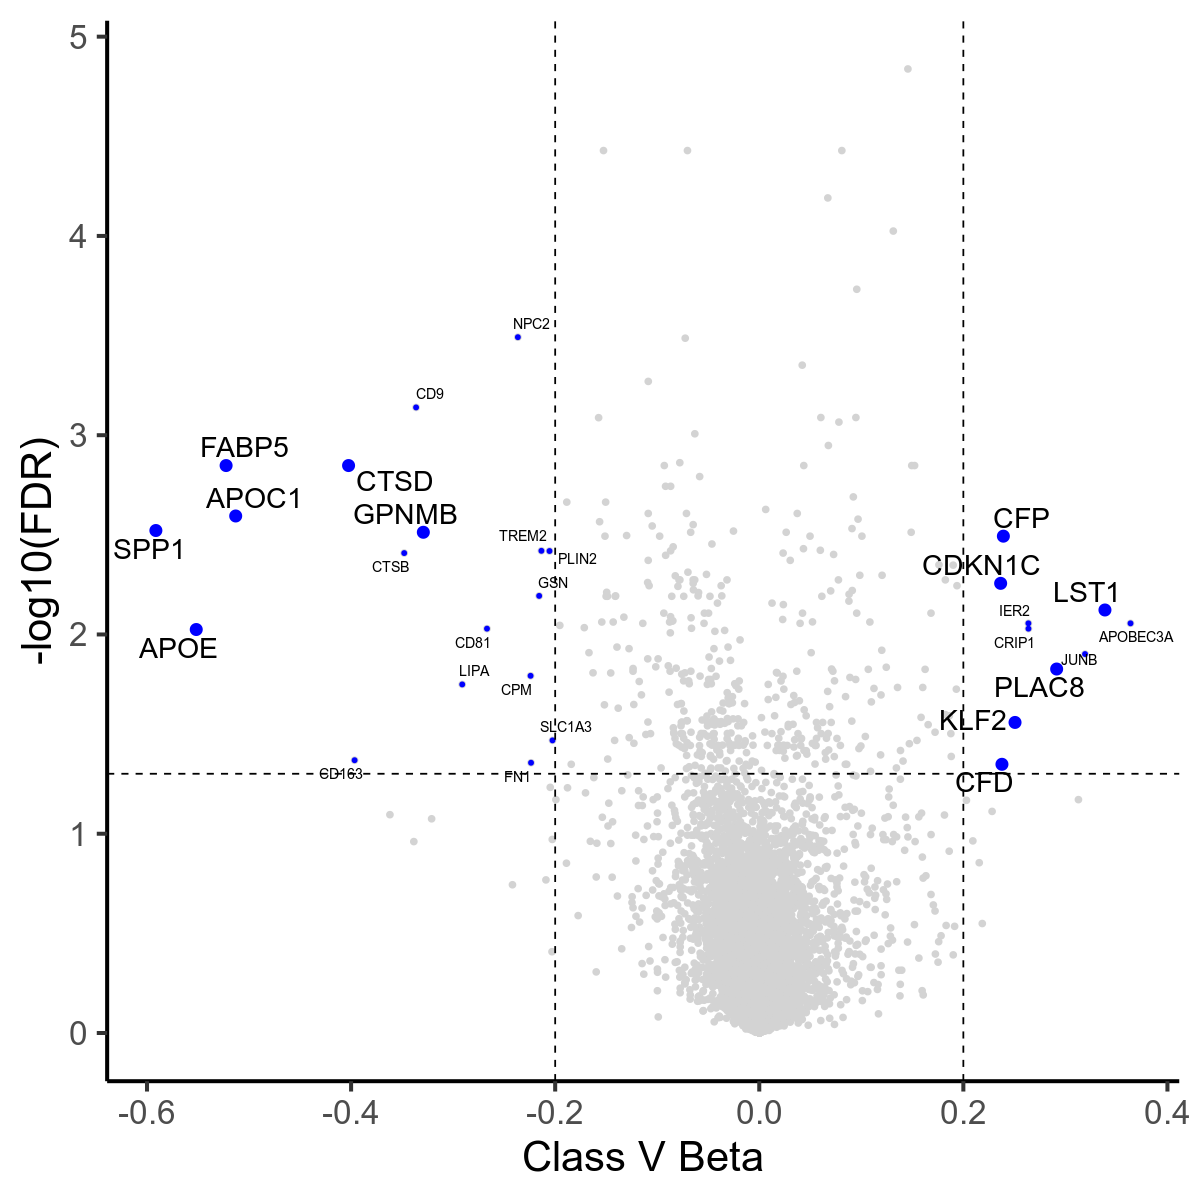

In [123]:
fig.size(10, 10)
ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.2,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.2, 0.2), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic(base_size = 25) + 
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR < 0.05 & abs(Beta) >= 0.2 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Class V Beta", y = "-log10(FDR)")

### % Injured PT

In [8]:
lateinjury_high_prop <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/injured_pt_highprop_singlecell_05102024.rds') %>% 
                            select(Prop, sample)

In [9]:
meta <- sc_meta %>% select(-c(colnames(sc_meta[grep('hPC', colnames(sc_meta))]), 
                          colnames(sc_meta[grep('hUMAP', colnames(sc_meta))])))
harmony <- sc_meta %>% select(colnames(sc_meta)[grep('hPC', colnames(sc_meta))])

umap <- sc_meta %>% select(c(hUMAP1, hUMAP2))

meta <- meta %>% left_join(lateinjury_high_prop %>% rename(injured_pt_prop = Prop))

ind <- c(1:nrow(meta))[!is.na(meta$injured_pt_prop)]

meta <- meta[ind, ]
harmony <- harmony[ind, ]
umap <- umap[ind, ]

meta$Age <- as.numeric(scale(meta$Age))
meta$Sex <- as.numeric(as.factor(meta$Sex))

meta$Final_Chronicity <- as.factor(as.numeric(meta$Final_Chronicity))
meta$Final_Activity <- as.factor(as.numeric(meta$Final_Activity))

meta <- meta %>% left_join(data.frame(Responder.Status = c("NR", "PR", "CR"),
                                      Responder_Status = c(0, 1, 2)))

meta$Responder_Status <- as.numeric(meta$Responder_Status)
meta$First_biop <- as.numeric(meta$First_biop)
meta$Pred_use <- as.numeric(meta$Pred_use)


meta <- fastDummies::dummy_cols(meta, "Race")
meta <- fastDummies::dummy_cols(meta, "Final_ISN")
meta <- fastDummies::dummy_cols(meta, "Final_Site")


write.csv(meta, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(harmony, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_harmony.csv', 
          row.names = FALSE, quote = FALSE)
write.csv(umap, '/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_umap.csv', 
          row.names = FALSE, quote = FALSE)

Joining, by = "sample"
Joining, by = "Responder.Status"


#### Results

#### PER CELL Chronicity vs Injured PT

Joining, by = "cell"



	Pearson's product-moment correlation

data:  ncorr_meta$pt_ncorr and ncorr_meta$chronicity_ncorr
t = 216.99, df = 21477, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8244725 0.8328518
sample estimates:
      cor 
0.8287086 


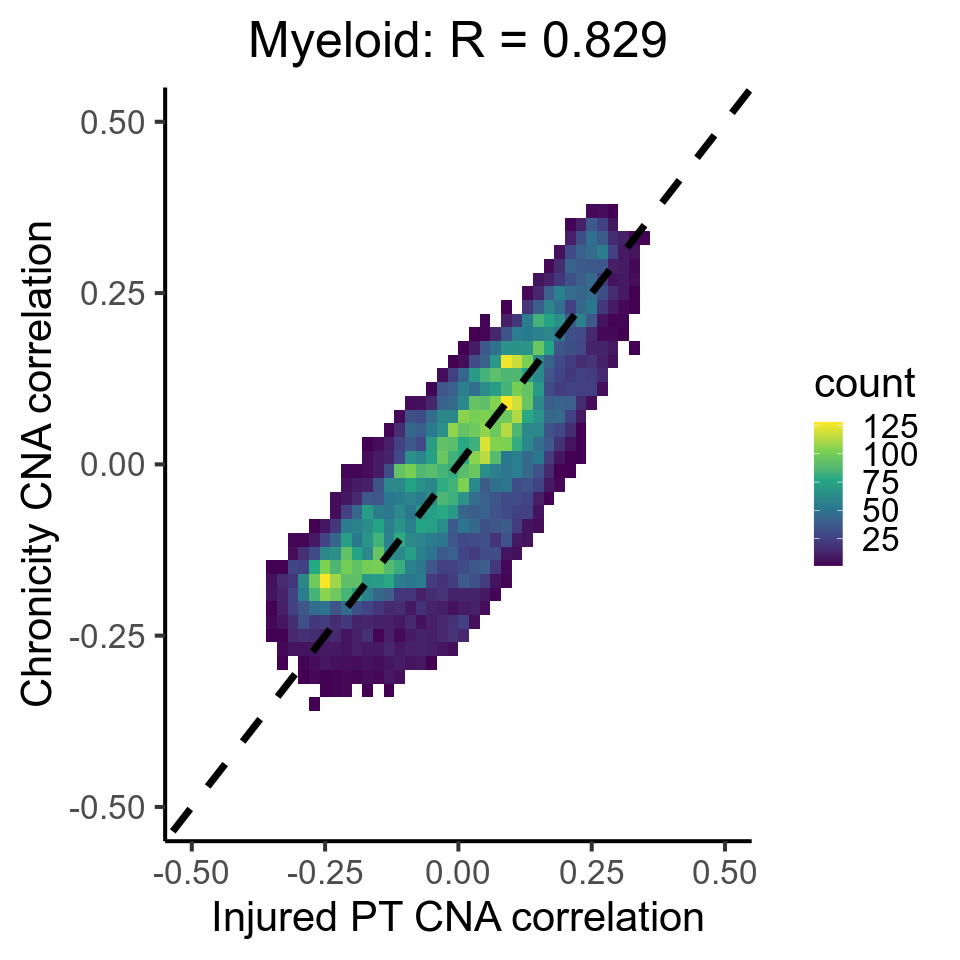

In [7]:
pt_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_ncorr_cond_nochron.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_fdrs_cond_nochron.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
pt_meta$ncorr <- ncorr$V1

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

ncorr_meta <- pt_meta %>% 
                    dplyr::select(cell, ncorr) %>% 
                    rename(pt_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            dplyr::select(cell, ncorr) %>% 
                            rename(chronicity_ncorr = ncorr)) %>% na.omit()

fig.size(8, 8)
cor.test(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)
cor_plot <- ggplot(ncorr_meta, aes(x = pt_ncorr, y = chronicity_ncorr)) +
                    geom_bin2d(bins = 50) +
                    scale_fill_continuous(type = "viridis",
                                          name = "count") +
                   theme_classic(base_size = 25) +
                    geom_abline(linetype = 'dashed', linewidth = 2) + 
                    scale_x_continuous(limits = c(-0.5, 0.5)) + 
                    scale_y_continuous(limits = c(-0.5, 0.5)) + 
                    labs(x = "Injured PT CNA correlation",
                         y = "Chronicity CNA correlation",
                         title = "Myeloid: R = 0.829") + 
                    theme(legend.position = "right",
                          plot.title = element_text(size = 30, 
                                                    hjust = 0.5),
                            text=element_text(family="Arial"))

cor_plot

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/extended_data/figure9/figure9j.png",
       cor_plot,
       base_height = 8,
       base_width = 9)

In [33]:
pt_meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
pt_meta$ncorr <- ncorr$V1

meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/chronicity/sc_conditional_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1

In [34]:
ncorr_meta <- pt_meta %>% 
                    dplyr::select(cell, ncorr) %>% 
                    rename(pt_ncorr = ncorr) %>% 
                left_join(meta %>% 
                            dplyr::select(cell, ncorr) %>% 
                            rename(chronicity_ncorr = ncorr)) %>% na.omit()

Joining, by = "cell"



	Pearson's product-moment correlation

data:  ncorr_meta$pt_ncorr and ncorr_meta$chronicity_ncorr
t = 95.42, df = 21477, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5361804 0.5549652
sample estimates:
      cor 
0.5456413 


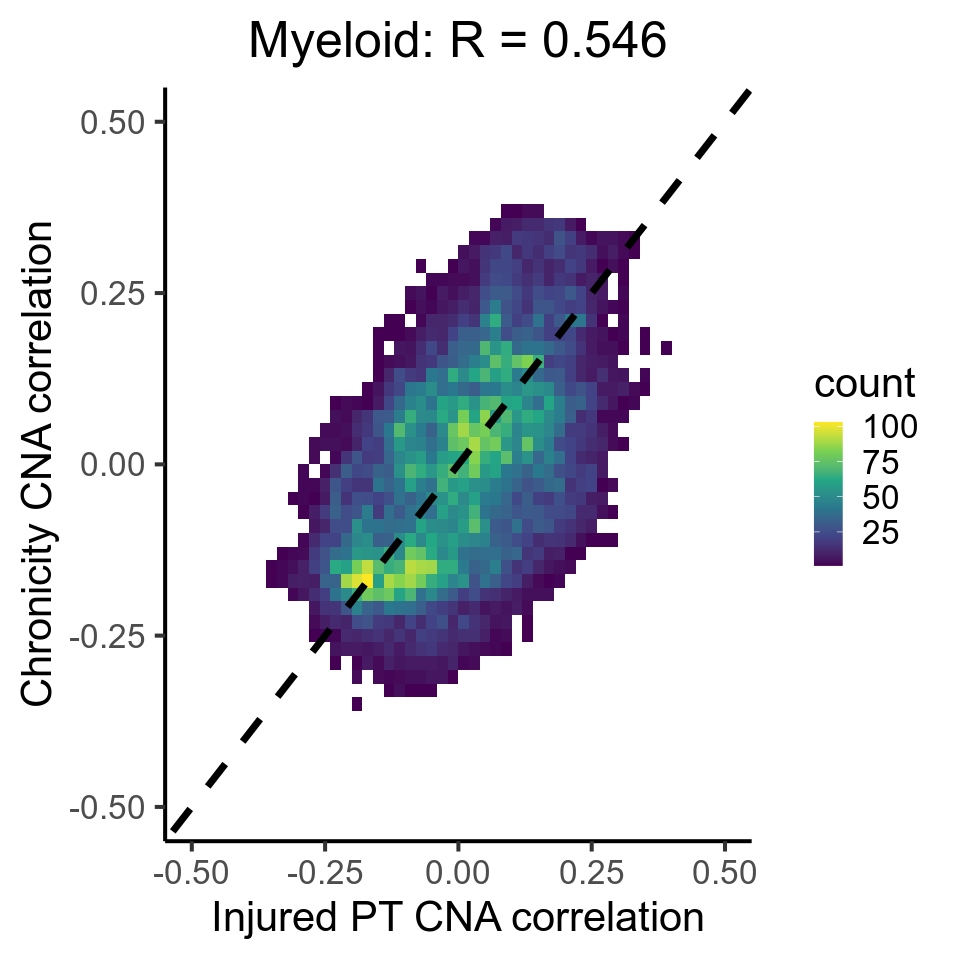

In [35]:
fig.size(8, 8)
cor.test(ncorr_meta$pt_ncorr, ncorr_meta$chronicity_ncorr)
cor_plot <- ggplot(ncorr_meta, aes(x = pt_ncorr, y = chronicity_ncorr)) +
                    geom_bin2d(bins = 50) +
                    scale_fill_continuous(type = "viridis",
                                          name = "count") +
                   theme_classic(base_size = 25) +
                    geom_abline(linetype = 'dashed', linewidth = 2) + 
                    scale_x_continuous(limits = c(-0.5, 0.5)) + 
                    scale_y_continuous(limits = c(-0.5, 0.5)) + 
                    labs(x = "Injured PT CNA correlation",
                         y = "Chronicity CNA correlation",
                         title = "Myeloid: R = 0.546") + 
                    theme(legend.position = "right",
                          plot.title = element_text(size = 30, 
                                                    hjust = 0.5),
                            text=element_text(family="Arial"))

cor_plot

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6b.png",
       cor_plot,
       base_height = 8,
       base_width = 9)

#### MASC

In [2]:
qcd_meta <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_meta_harmonizedPCUMAPCellStateClusters_10042022.rds')
myeloid_rawcounts <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/qcd/Myeloid_clusterQCd_rawcounts_03102023.rds')
mito_genes_subset <- c("MT-ND5", "MT-ND6")
percent_mito <- colSums(myeloid_rawcounts[mito_genes_subset, ]) / colSums(myeloid_rawcounts) * 100
percent_mito <- data.frame(cell = names(percent_mito), percent.mt = percent_mito)
qcd_meta <- left_join(qcd_meta, percent_mito)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')
model_df <- meta %>% 
                left_join(qcd_meta %>% select(cell, nCount_RNA, percent.mt, new_cluster_number)) %>%
                mutate(nCount_RNA = log(nCount_RNA))

res <- MASC.me(model_df, as.factor(model_df$new_cluster_number),
                contrast = "injured_pt_prop",
                random_effects = c("sample"),
                fixed_effects = c("nCount_RNA", 
                                  "percent.mt", 
                                  'Final_Site_JHU',
                                  'Final_Site_NYU',
                                  'First_biop',
                                  'Responder_Status',
                                  'Age'),
                verbose = TRUE,
                save_models = F) %>%
            dplyr::mutate(bonferroni = p.adjust(model.pvalue, method = "bonferroni")) %>%
            dplyr::arrange(model.pvalue)
saveRDS(res, '/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/injured_pt_cond_nochron.rds')

Joining, by = "cell"
Joining, by = "cell"
Using null model: cluster ~ nCount_RNA + percent.mt + Final_Site_JHU + Final_Site_NYU + First_biop + Responder_Status + Age + (1|sample)

Creating logistic mixed models for cluster0

Creating logistic mixed models for cluster1

Creating logistic mixed models for cluster10

Creating logistic mixed models for cluster11

Creating logistic mixed models for cluster12

Creating logistic mixed models for cluster13

Creating logistic mixed models for cluster14

Creating logistic mixed models for cluster15

Creating logistic mixed models for cluster16

Creating logistic mixed models for cluster17

Creating logistic mixed models for cluster18

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.110717 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Resc

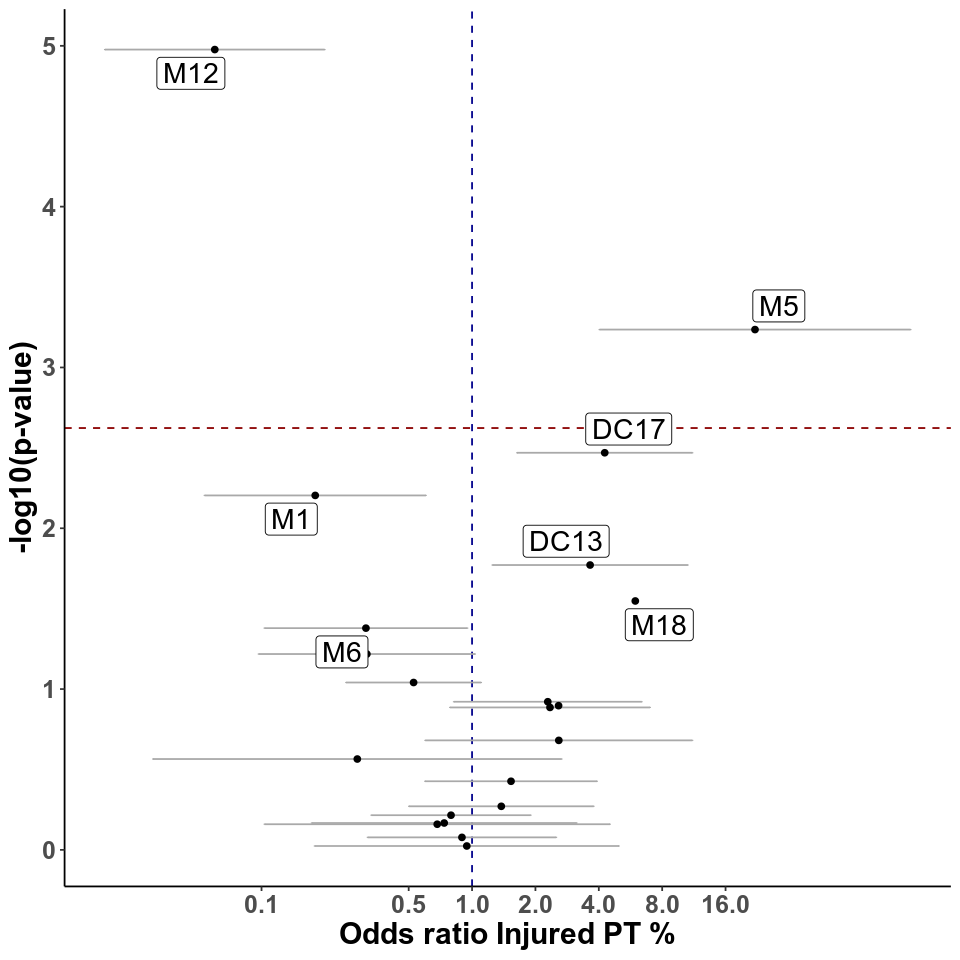

In [14]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/injured_pt_cond_nochron.rds')
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = injured_pt_prop.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio Injured PT %") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=injured_pt_prop.OR.95pct.ci.lower, 
                                  xmax=injured_pt_prop.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(breaks = c(0.1, 0.5, 1, 2, 4, 8, 16)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = 18, face = "bold"),
                      axis.text = element_text(size = 15, face = "bold"),
                     text=element_text(family="Arial"))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9l-masc.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

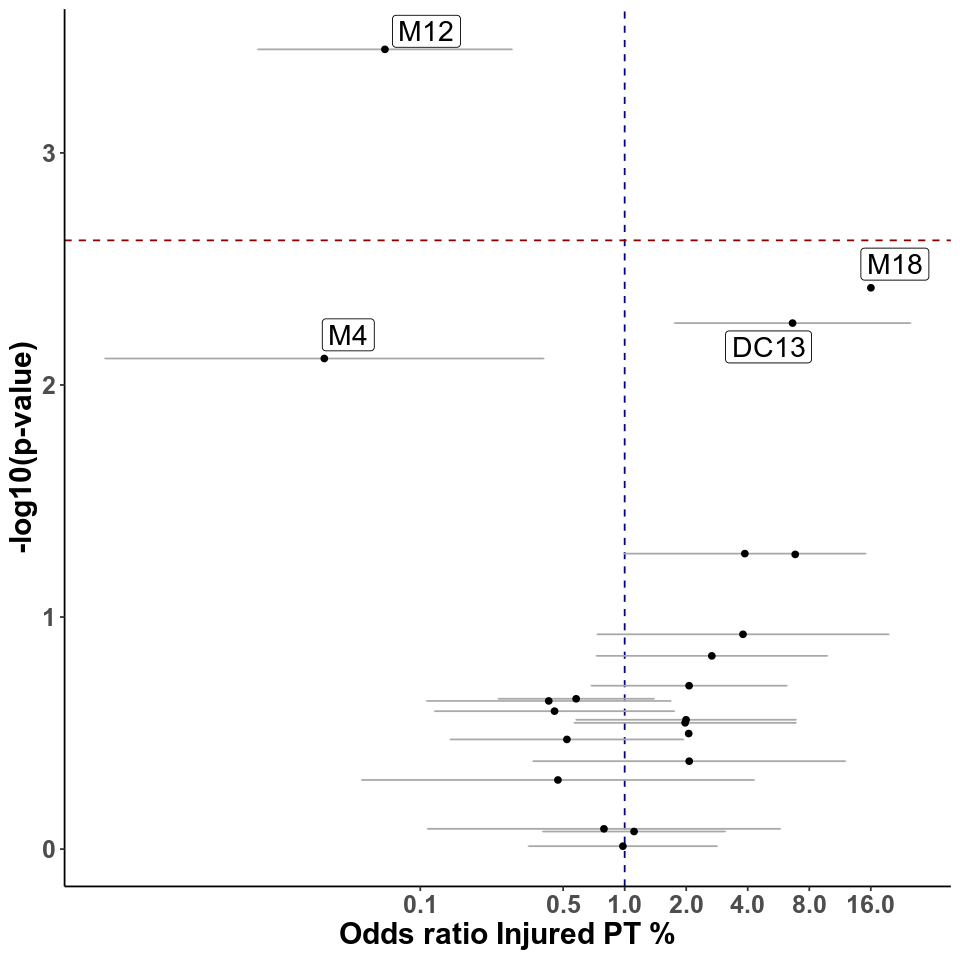

In [16]:
res <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/masc/myeloid/injured_pt_cond.rds')
res <-  res %>% 
            rowwise() %>% 
            mutate(cluster = ifelse(unlist(str_split(cluster, 'cluster'))[2] %in% c(13, 15, 17, 19, 20), 
                                paste0('DC', unlist(str_split(cluster, 'cluster'))[2]),
                                paste0('M', unlist(str_split(cluster, 'cluster'))[2])))

fig.size(8, 8)
masc_plot <- ggplot(data = res %>% 
                   mutate(label = ifelse(model.pvalue < 0.05, cluster, NA)), 
                   aes(x = injured_pt_prop.OR, y = -log10(model.pvalue))) +
                theme_classic() + ylab("-log10(p-value)") + xlab("Odds ratio Injured PT %") +
                geom_vline(xintercept = 1, linetype = "dashed", color = "darkblue") +
                geom_errorbar(aes(xmin=injured_pt_prop.OR.95pct.ci.lower, 
                                  xmax=injured_pt_prop.OR.95pct.ci.upper), col = "darkgrey") +
                geom_point() + 
                geom_hline(yintercept = -log10(0.05/nrow(res)), linetype = "dashed", color = "darkred") +
                scale_x_log10(breaks = c(0.1, 0.5, 1, 2, 4, 8, 16)) + 
                ggrepel::geom_label_repel(aes(label = label), size = 6) +
                theme(axis.title = element_text(size = 18, face = "bold"),
                      axis.text = element_text(size = 15, face = "bold"),
                     text=element_text(family="Arial"))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure10/figure10a.png",
       masc_plot,
       base_height = 8,
       base_width = 8)
masc_plot

#### CNA

In [ ]:
                                    final_annotation = c('M0. CD16+ CXC3CR1+ Monocyte', 
                                                               'M1. CD14+ CD16+ CCL2+ CX3CR1+ Monocyte',
                                                               'M2. CD14+ CCR2+ Monocyte',
                                                               'M3. CCL2+ CCL3+ Monocyte',
                                                               'M4. TPSB2+ MAST cell',
                                                               'M5. GPNMBhigh NUPR1high Macrophage',
                                                               'M6. SELENOPinter ISGhigh Macrophage', 
                                                               'M7. SPP1high FABP5high Macrophage',
                                                               'M8. SPP1low FABP5high Macrophage',
                                                               'M9. MERTKhigh FABP5high Macrophage',
                                                               'M10. SELENOPinter LYVE1inter Resident Macrophage',
                                                               'M11. GPMNBhigh NUPR1low Macrophage',
                                                               'M12. SELENOPhigh LYVE1high Resident Macrophage',
                                                               'DC13. CCR7+ LAMP3+ DC2', 
                                                               'M14. APOChigh C3high Macrophage',
                                                               'DC15. CLEC10Alow cDC2',
                                                               'M16. APOClow C3high Macrophage',
                                                               'DC17. CLEC10Ahigh cDC2',
                                                               'M18. CENPF+ MKI67+ Proliferating',
                                                               'DC19. cDC1',
                                                               'DC20. pDC'))

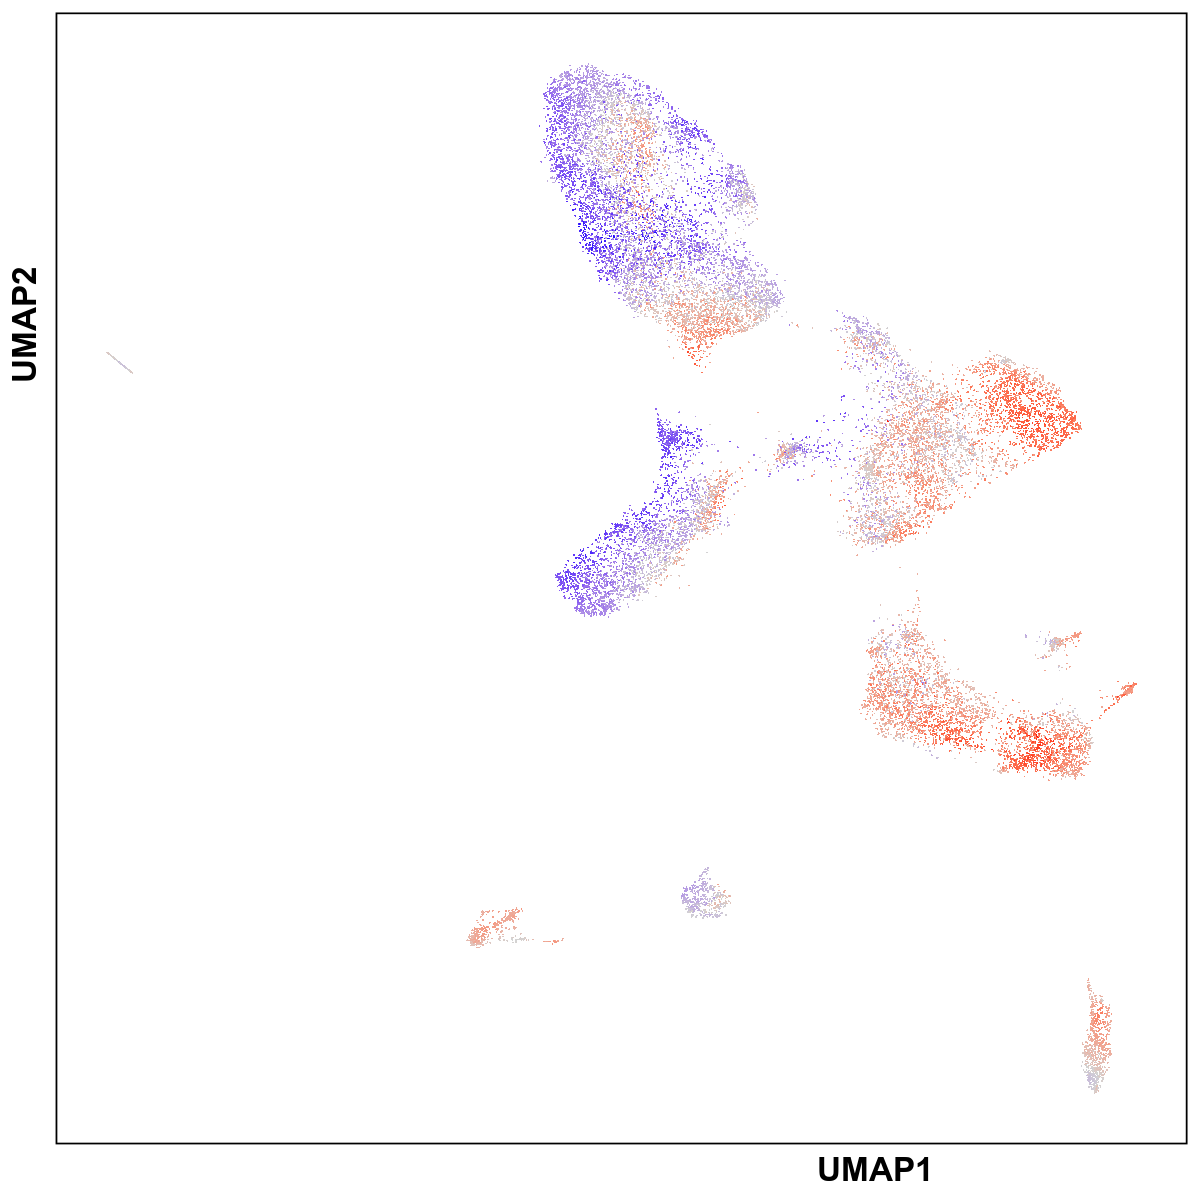

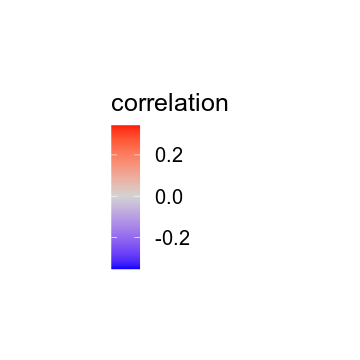

In [8]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_ncorr_cond_nochron.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_fdrs_cond_nochron.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.05) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9j-cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure9/figure9j-cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

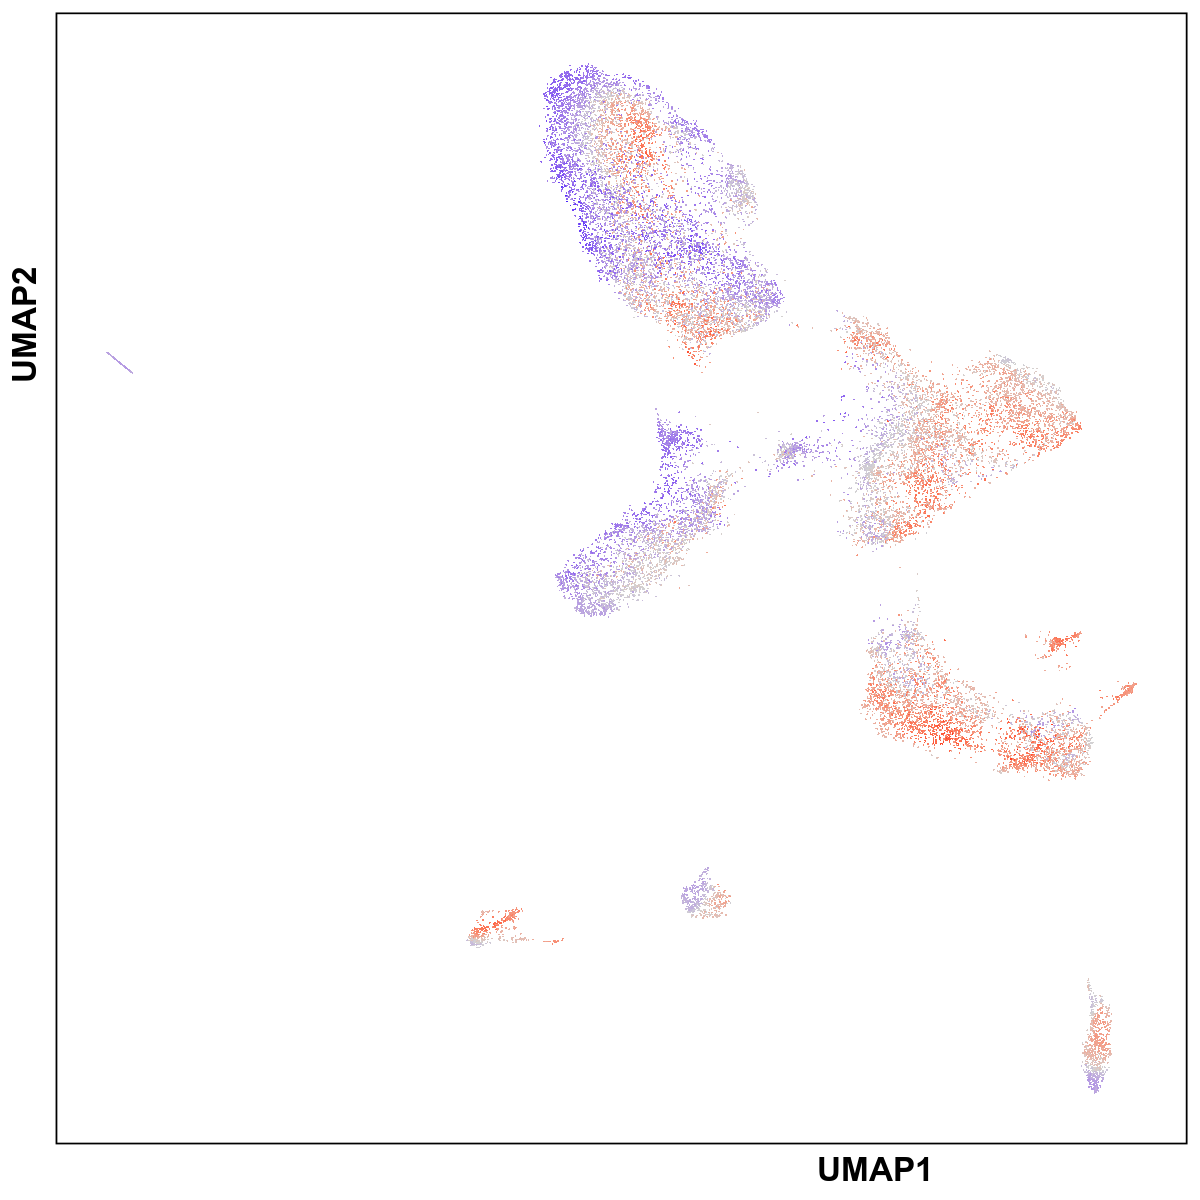

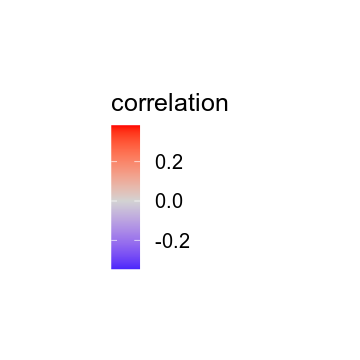

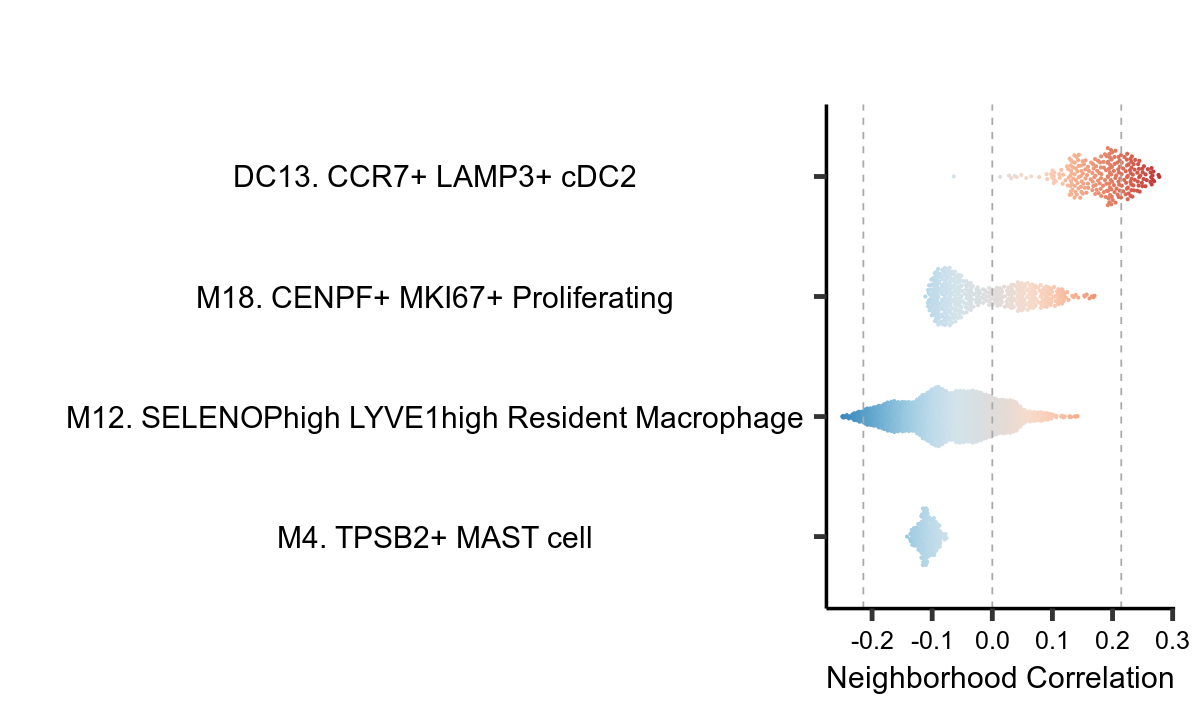

In [ ]:
options(warn=-1)
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')
umap <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_umap.csv')
ncorr <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_cond_ncorr.csv", header = FALSE)
fdrs <- read.csv("/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_cond_fdrs.csv", header = FALSE)
colnames(fdrs) <- c('threshold', 'fdr', 'ncells')
meta$ncorr <- ncorr$V1


fdr <- fdrs %>% 
            filter(fdr < 0.1) %>% 
            mutate(fdr = round(fdr, 4)) %>% 
            filter(fdr == max(fdr)) %>% 
            pull(threshold)

tmp_meta <- meta %>% mutate(ifelse(abs(meta$ncorr) > fdr, ncorr, NA))
tmp_meta <- cbind(tmp_meta, umap)

fig.size(8, 8)
cna_umap <- ggplot() + 
      geom_point(data = tmp_meta,
                aes(x = hUMAP1, y = hUMAP2), color = 'lightgrey', size = 0.75, stroke = 0.0001, shape = 20) + 
      geom_point(
      data = tmp_meta[sample(nrow(tmp_meta)),] %>% rename(correlation = ncorr), 
          aes(x = hUMAP1, y = hUMAP2, color = correlation), size = 0.75, stroke = 0.0001, shape = 20) + 
      scale_color_gradient2(low = 'blue', mid = 'lightgray', high = 'red', na.value = "lightgrey") + 
     # labs(x="UMAP1", y="UMAP2", title = "Myeloid Chronicity: p = 2.00e-04") +
theme_classic(base_size = 15) +
      theme(
        legend.position = "right",
            #  plot.title = element_text(hjust = 0.5, 
            #                            size = 18, 
            #                            face = "bold"),
              axis.title = element_text(hjust = 0.75, 
                                        size = 20, 
                                        face = "bold"), 
              axis.text = element_blank(),
              axis.line = element_blank(),
              axis.ticks = element_blank(),
              panel.border = element_rect(colour = "black", fill=NA, size=1)
    ) +
        labs(x = "UMAP1", y = "UMAP2") + 
    theme(text=element_text(family="Arial")) 
umap_legend <- cowplot::get_legend(cna_umap)
cna_umap <- cna_umap + theme(legend.position = "none")
umap_legend <- cowplot::plot_grid(umap_legend)
fig.size(10, 10)
cna_umap
fig.size(3, 3)
umap_legend
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6a-cna_umap.png",
       cna_umap,
       base_height = 10,
       base_width = 10)
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6a-cna_umap_legend.png",
       umap_legend,
       base_height = 3,
       base_width = 3)

pos_fdr_thresh <- fdr
neg_fdr_thresh <- -1 * fdr

interval <- c(-max(abs(meta$ncorr)), max(abs(meta$ncorr)))


myPalette <- colorRampPalette(c(RColorBrewer::brewer.pal(11, "RdBu")[11:7], "#DCDCDC", RColorBrewer::brewer.pal(11, "RdBu")[5:1]))
subset <- c('M12. SELENOPhigh LYVE1high Resident Macrophage', 'M4. TPSB2+ MAST cell', 
            'M18. CENPF+ MKI67+ Proliferating', 'DC13. CCR7+ LAMP3+ cDC2')

violin_plot <- ggplot(meta %>% filter(final_annotation %in% subset), aes(y = reorder(final_annotation, ncorr), x = ncorr)) +
                    ggbeeswarm::geom_quasirandom(aes(color = ncorr), width = 0.25, size = 0.5) +
                    geom_vline(xintercept = neg_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = pos_fdr_thresh, linetype = "dashed", color = "darkgrey") +
                    geom_vline(xintercept = 0, linetype = "dashed", color = "darkgrey") +
                    scale_colour_gradientn(colours = myPalette(20), limits = interval) +
                    labs( x= "Neighborhood Correlation", y = "", title = "") +
                    theme_classic(base_size = 30) +
                    theme(text=element_text(family="Arial"),
                        legend.position = "none",
                        panel.grid = element_blank(),
                        axis.text.x = element_text(color = "black", size = 15, hjust=0.5),
                        axis.text.y = element_text(color = "black", size = 18, hjust=0.5),
                        axis.title = element_text(size=18, hjust = 0.5),
                        axis.line.x.bottom = element_line(color = 'black', linewidth = 1),
                        axis.line.y.left   = element_line(color = 'black', linewidth = 1))
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/main_figures/figure6/figure6a-violin_plot.png",
       violin_plot,
       base_height = 6,
       base_width = 10)
fig.size(6, 10)
violin_plot

#### DE

In [ ]:
myeloid_pb <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/DE/Myeloid_norm_pseudobulk_12072023.rds')
meta <- read.csv('/data/srlab/ssg34/SLE_kidney_v2/data/cna_new/myeloid/injured_pt/sc_meta.csv')

In [37]:
myeloid_pb <- myeloid_pb %>% 
                filter(sample %in% unique(meta$sample)) %>% 
                left_join(meta %>% 
                              select(sample, injured_pt_prop) %>% 
                              unique())

Joining, by = "sample"


In [52]:
de <- function(feature, df) {
    model_df <- df %>% select(feature, sample,  
                              injured_pt_prop, avg_count, avg_mt) %>% rename(Exp = feature)
    if (sum(model_df$Exp > 0) > 0.1 * nrow(model_df)) { 
        m_0 <- lm(Exp ~ log(avg_count) + avg_mt, data = model_df)
        m_1 <- lm(Exp ~ log(avg_count) + avg_mt + injured_pt_prop, data = model_df)
        ANNO <- anova(m_0, m_1)
        LRP <- ANNO[2,6]
        F <- ANNO[2,5]
        Beta <- summary(m_1)$coefficients['injured_pt_prop', 'Estimate']
        SE <- summary(m_1)$coefficients['injured_pt_prop', 'Std. Error']
        res <- c(gene = feature, LRP = LRP, F = F, Beta = Beta, SE = SE)
    }
    else {
        res <- c(gene = feature, LRP = NA, F = NA, Beta = NA, SE = NA)
    }
    return(res)
}

In [53]:
de_out <- mclapply(colnames(myeloid_pb)[1:36601], de, myeloid_pb, mc.cores = 20)

In [60]:
de_df <- data.frame(do.call(rbind, de_out)) %>% mutate(LRP = as.numeric(LRP),
                                                       F = as.numeric(F),
                                                       Beta = as.numeric(Beta),
                                                       SE = as.numeric(SE))

In [61]:
saveRDS(de_df, '/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_injured_pt_differential_expression_08102024.rds')

In [5]:
de_df <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_injured_pt_differential_expression_08102024.rds')

In [7]:
filter_genes <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_5pgenes_de.rds')

In [12]:
de_df <- de_df %>% 
            na.omit() %>% 
            filter(gene %in% filter_genes$genes) %>% 
            arrange(LRP) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) 

Warning message:
“Removed 9541 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 35 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“Removed 9541 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 54 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


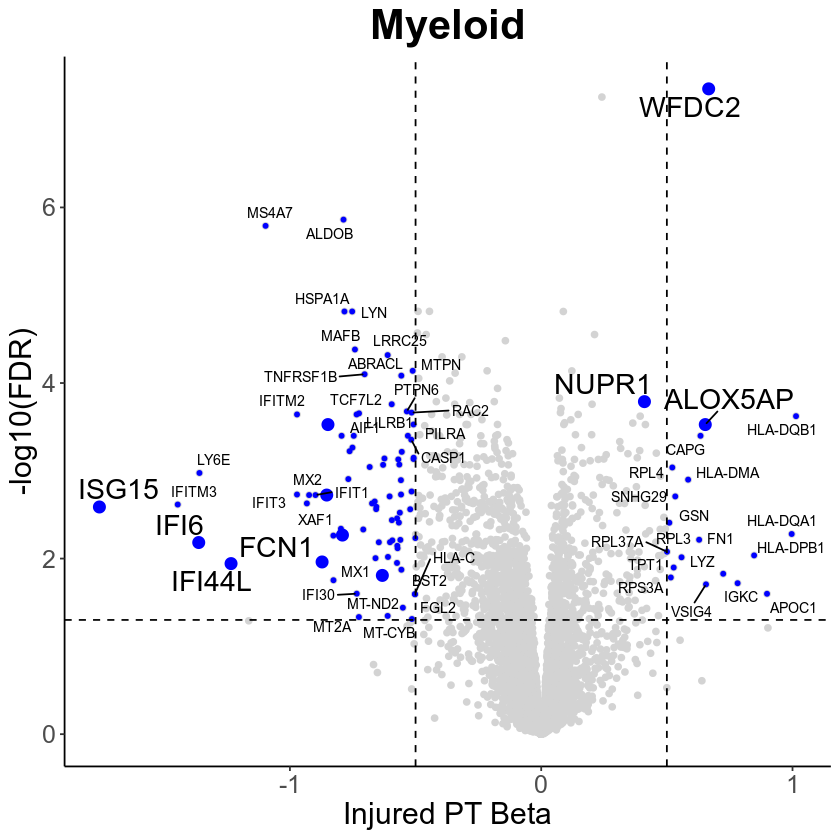

In [16]:
genes <- c("NUPR1", "WFDC2", "TIMP1", "KLF2", "ALOX5AP", "CHIT1",
           "FCN1", "ISG15", "IFI6", "IFI44L", "FCGR3A", "LST1")
de_plot <- ggplot(de_df,
                aes(x = Beta, y = -log10(FDR))) +
    geom_point(colour = 'lightgrey') + 
    geom_point(data = de_df %>% filter(FDR < 0.05 & abs(Beta) >= 0.5,
                                        ! gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 1) +
    geom_point(data = de_df %>% filter(gene %in% genes),
                   aes(x = Beta, y = -log10(FDR)),  color = "blue", size = 3)  + 
    geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed") + 
    geom_hline(yintercept = -log10(0.05), linetype = "dashed") + 
    theme_classic() + 
    theme(text=element_text(family="Arial"),
          legend.position = "none",
          axis.text = element_text(size = 15),
          axis.title = element_text(size = 18),
          plot.title = element_text(size = 25, hjust = 0.5, face = "bold")) +
    ggrepel::geom_text_repel(data = de_df %>% 
                                     mutate(label = ifelse(FDR < 0.05 & abs(Beta) >= 0.5 | 
                                                           gene %in% genes, gene, NA),
                                            label_size = ifelse(gene %in% genes, 6 , 3)),
                                     aes(x = Beta, y = -log10(FDR), 
                                         size = label_size, label = label)
            , color = "black") +
    scale_size_identity() + 
    labs(x = "Injured PT Beta", y = "-log10(FDR)", title = "Myeloid")
cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure10/figure10e.png",
       de_plot,
       base_height = 8,
       base_width = 8)
de_plot

In [18]:
injured_pt_de <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_injured_pt_differential_expression_08102024.rds') %>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            filter(gene %in% filter_genes$genes) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) %>% 
            filter(FDR < 0.05)
chron_de <- readRDS('/data/srlab/ssg34/SLE_kidney_v2/data/pseudobulk_de/Myeloid_chronicity_differential_expression_03082024.rds')%>% 
            na.omit() %>% 
            arrange(LRP) %>% 
            filter(gene %in% filter_genes$genes) %>% 
            mutate(FDR = p.adjust(LRP, method = "BH")) %>% 
            filter(FDR < 0.05)

In [19]:
plot_df <- chron_de %>% 
                rename(Chron_Beta = Beta) %>% 
                select(gene, Chron_Beta) %>% 
                left_join(injured_pt_de %>% 
                          rename(Injured_PT_Beta = Beta) %>% 
                          select(gene, Injured_PT_Beta)) %>% na.omit()

Joining, by = "gene"


In [21]:
cor.test(plot_df$Chron_Beta, plot_df$Injured_PT_Beta)


	Pearson's product-moment correlation

data:  plot_df$Chron_Beta and plot_df$Injured_PT_Beta
t = 122.51, df = 510, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9803174 0.9860549
sample estimates:
      cor 
0.9834306 


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


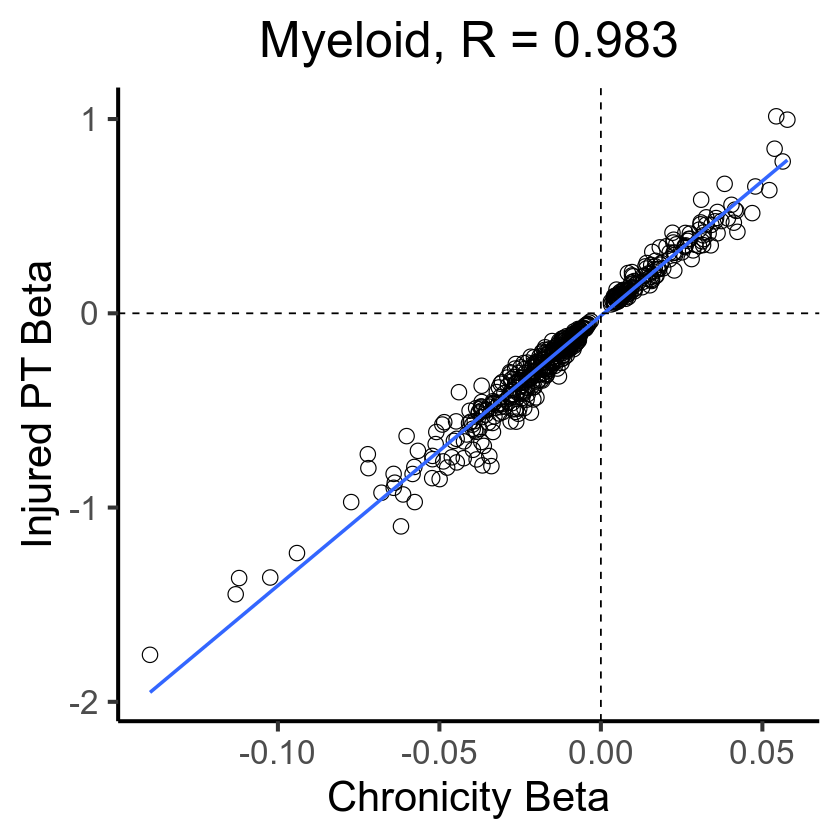

In [22]:
gene_plot <- ggplot(plot_df, aes(x = Chron_Beta, y = Injured_PT_Beta)) + 
                    geom_point(shape = 1, size = 4) + 
                    theme_classic(base_size = 25) + 
                    geom_smooth(method = "lm", se = FALSE) +
                    labs(x = "Chronicity Beta", 
                         y = "Injured PT Beta",
                         title = "Myeloid, R = 0.983") +
                    geom_vline(xintercept = 0, linetype = "dashed") + 
                    geom_hline(yintercept = 0, linetype = "dashed") +
                    theme(text=element_text(family="Arial"),
                          plot.title=element_text(hjust = 0.5))

cowplot::save_plot("/data/srlab/ssg34/SLE_kidney_v2/figures/supplemental_figures/figure10/figure10f.png",
       gene_plot,
       base_height = 8,
       base_width = 8)
gene_plot